In [ ]:
from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive')

# Define the path to the folder containing your 8 CSV files
# Update this path to wherever you uploaded the CIC-IDS-2017 CSVs in your Drive
DATA_PATH = '/content/drive/MyDrive/CIC-IDS-2017/MachineLearningCVE'

# Verify the files are recognized
csv_files = [f for f in os.listdir(DATA_PATH) if f.endswith('.csv')]
print(f"Found {len(csv_files)} CSV files:")
for f in csv_files:
    print(f" - {f}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 8 CSV files:
 - Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
 - Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
 - Monday-WorkingHours.pcap_ISCX.csv
 - Friday-WorkingHours-Morning.pcap_ISCX.csv
 - Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
 - Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
 - Tuesday-WorkingHours.pcap_ISCX.csv
 - Wednesday-workingHours.pcap_ISCX.csv


In [ ]:
import pandas as pd
import glob

# Use glob to grab all CSV files in the directory
all_csv_paths = glob.glob(os.path.join(DATA_PATH, "*.csv"))

# Read and concatenate all files
print("Loading and merging CSV files... This may take a moment.")
df_list = [pd.read_csv(file) for file in all_csv_paths]
df = pd.concat(df_list, ignore_index=True)

print(f"Total records loaded: {df.shape[0]}")
print(f"Total features: {df.shape[1]}")

Loading and merging CSV files... This may take a moment.
Total records loaded: 2830743
Total features: 79


In [ ]:
import numpy as np

# 1. Strip whitespace from column names
df.columns = df.columns.str.strip()

# 2. Strip whitespace from the 'Label' column just in case
df['Label'] = df['Label'].astype(str).str.strip()

# 3. Replace Infinity values with NaN, then drop all rows with NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)
initial_count = df.shape[0]
df.dropna(inplace=True)
final_count = df.shape[0]

print(f"Dropped {initial_count - final_count} rows containing NaN or Infinity.")
print(f"Cleaned dataset shape: {df.shape}")

Dropped 2867 rows containing NaN or Infinity.
Cleaned dataset shape: (2827876, 79)


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# 1. Filter for BENIGN traffic
normal_df = df[df['Label'] == 'BENIGN'].copy()
print(f"Total BENIGN records: {normal_df.shape[0]}")

# 2. Drop the 'Label' column to isolate numerical features
X_normal = normal_df.drop(columns=['Label'])

# (Optional) Drop other non-numeric or irrelevant columns if they exist in your specific CSV version
# e.g., 'Flow ID', 'Source IP', 'Destination IP', 'Timestamp'
cols_to_drop = [col for col in ['Flow ID', 'Source IP', 'Destination IP', 'Timestamp', 'Source Port', 'Destination Port'] if col in X_normal.columns]
if cols_to_drop:
    X_normal.drop(columns=cols_to_drop, inplace=True)

# 3. Split into Train and Validation sets (80/20)
X_train, X_val = train_test_split(X_normal, test_size=0.2, random_state=42)

# 4. Scale the data (Fit on training, transform both)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print(f"Training data shape: {X_train_scaled.shape}")
print(f"Validation data shape: {X_val_scaled.shape}")

Total BENIGN records: 2271320
Training data shape: (1817056, 77)
Validation data shape: (454264, 77)


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

input_dim = X_train_scaled.shape[1]

# Define the Encoder
encoder_input = layers.Input(shape=(input_dim,))
x = layers.Dense(64, activation='relu')(encoder_input)
x = layers.Dropout(0.1)(x) # Slight dropout to prevent overfitting
x = layers.Dense(32, activation='relu')(x)
latent_representation = layers.Dense(16, activation='relu')(x)

# Define the Decoder
x = layers.Dense(32, activation='relu')(latent_representation)
x = layers.Dropout(0.1)(x)
x = layers.Dense(64, activation='relu')(x)
decoder_output = layers.Dense(input_dim, activation='linear')(x) # Linear activation because data is StandardScaled

# Compile the Autoencoder
autoencoder = models.Model(inputs=encoder_input, outputs=decoder_output)
autoencoder.compile(optimizer='adam', loss='mse')

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 77)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 77)             │         5,005 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,261 (59.61 KB)

 Trainable params: 15,261 (59.61 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import gc
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping

print("Cleaning up memory...")
# 1. Downcast to float32 (Literally cuts your RAM usage in half)
X_train_scaled = X_train_scaled.astype('float32')
X_val_scaled = X_val_scaled.astype('float32')

# Force Python to empty the trash and free up RAM immediately
gc.collect()
tf.keras.backend.clear_session()

print("Building data pipelines...")
batch_size = 256

# 2. The Map Trick: Pass the array ONCE, and map it to (input, output) dynamically
train_dataset = tf.data.Dataset.from_tensor_slices(X_train_scaled) \
    .map(lambda x: (x, x)) \
    .batch(batch_size) \
    .prefetch(tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_tensor_slices(X_val_scaled) \
    .map(lambda x: (x, x)) \
    .batch(batch_size) \
    .prefetch(tf.data.AUTOTUNE)

early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

print("Starting training on the FULL dataset...")
history = autoencoder.fit(
    train_dataset,
    epochs=50,
    validation_data=val_dataset,
    callbacks=[early_stopping],
    verbose=1
)

Cleaning up memory...
Building data pipelines...
Starting training on the FULL dataset...
Epoch 1/50
7098/7098 ━━━━━━━━━━━━━━━━━━━━ 70s 9ms/step - loss: 0.2340 - val_loss: 0.1251
Epoch 2/50
7098/7098 ━━━━━━━━━━━━━━━━━━━━ 46s 6ms/step - loss: 0.1639 - val_loss: 0.0806
Epoch 3/50
7098/7098 ━━━━━━━━━━━━━━━━━━━━ 44s 6ms/step - loss: 0.1489 - val_loss: 0.0711
Epoch 4/50
7098/7098 ━━━━━━━━━━━━━━━━━━━━ 49s 7ms/step - loss: 0.1320 - val_loss: 0.0815
Epoch 5/50
7098/7098 ━━━━━━━━━━━━━━━━━━━━ 46s 7ms/step - loss: 0.1268 - val_loss: 0.0694
Epoch 6/50
7098/7098 ━━━━━━━━━━━━━━━━━━━━ 47s 7ms/step - loss: 0.1230 - val_loss: 0.0636
Epoch 7/50
7098/7098 ━━━━━━━━━━━━━━━━━━━━ 98s 9ms/step - loss: 0.1081 - val_loss: 0.0530
Epoch 8/50
7098/7098 ━━━━━━━━━━━━━━━━━━━━ 65s 9ms/step - loss: 0.1065 - val_loss: 0.0487
Epoch 9/50
7098/7098 ━━━━━━━━━━━━━━━━━━━━ 62s 9ms/step - loss: 0.0978 - val_loss: 0.0631
Epoch 10/50
7098/7098 ━━━━━━━━━━━━━━━━━━━━ 73s 10ms/step - loss: 0.0983 - val_loss: 0.0933
Epoch 11/50
7098/7

In [ ]:
# Save the final model to your Drive
autoencoder.save('/content/drive/MyDrive/CIC-IDS-2017/cicids_autoencoder.keras')
print("Model successfully saved to Google Drive!")

Model successfully saved to Google Drive!


14196/14196 ━━━━━━━━━━━━━━━━━━━━ 47s 3ms/step
Determined Anomaly Threshold (99th percentile): 0.3355


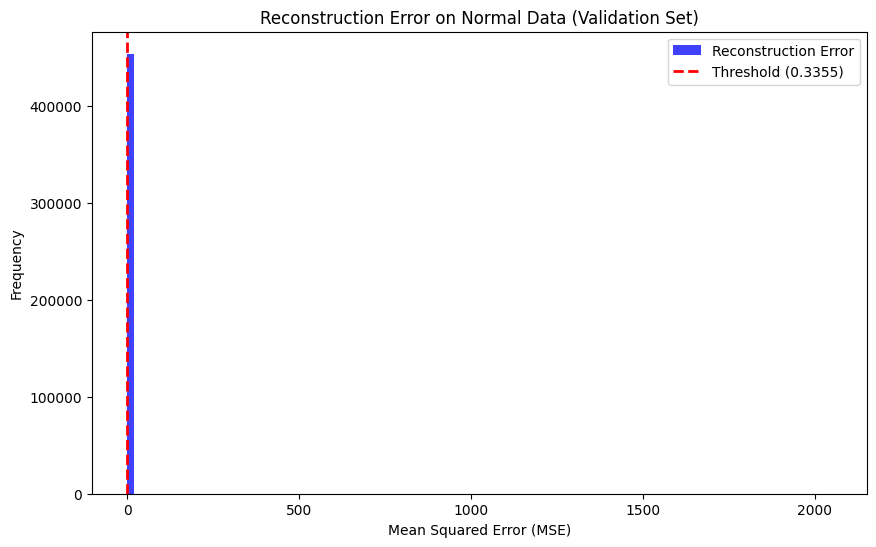

In [ ]:
import matplotlib.pyplot as plt

# 1. Get predictions (reconstructions) on the validation set
reconstructions = autoencoder.predict(X_val_scaled)

# 2. Calculate Mean Squared Error (MSE) for each record
mse = np.mean(np.power(X_val_scaled - reconstructions, 2), axis=1)

# 3. Define threshold (e.g., 99th percentile of normal validation error)
threshold = np.percentile(mse, 99)
print(f"Determined Anomaly Threshold (99th percentile): {threshold:.4f}")

# 4. Plot the distribution of reconstruction errors
plt.figure(figsize=(10, 6))
plt.hist(mse, bins=100, alpha=0.75, color='blue', label='Reconstruction Error')
plt.axvline(threshold, color='red', linestyle='dashed', linewidth=2, label=f'Threshold ({threshold:.4f})')
plt.title('Reconstruction Error on Normal Data (Validation Set)')
plt.xlabel('Mean Squared Error (MSE)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

Extracting latent representations (this may take a few seconds)...


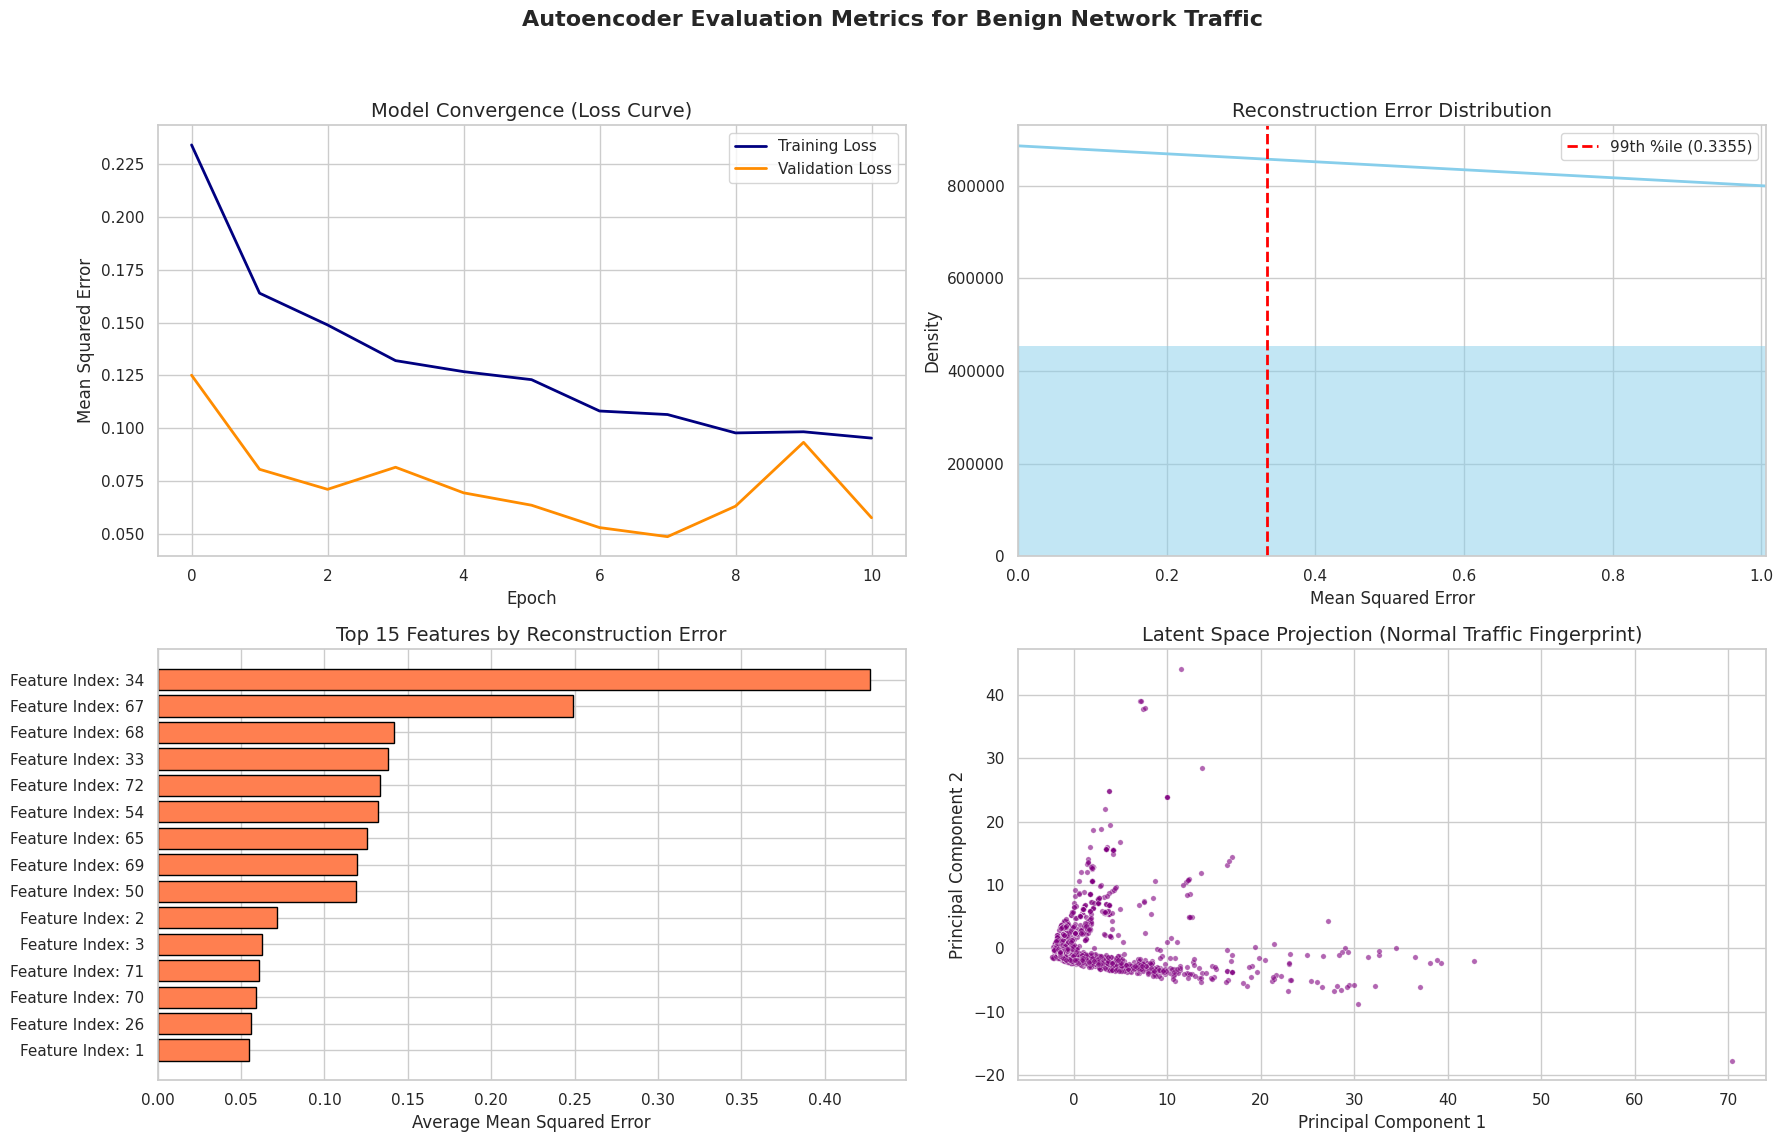

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.decomposition import PCA
import tensorflow as tf

# Set visual style for academic paper aesthetics
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Autoencoder Evaluation Metrics for Benign Network Traffic', fontsize=16, fontweight='bold')

# ---------------------------------------------------------
# 1. Training vs Validation Loss Curve
# ---------------------------------------------------------
# Proves to your professor that the model converged properly and did not overfit
axes[0, 0].plot(history.history['loss'], label='Training Loss', linewidth=2, color='navy')
axes[0, 0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2, color='darkorange')
axes[0, 0].set_title('Model Convergence (Loss Curve)', fontsize=14)
axes[0, 0].set_ylabel('Mean Squared Error')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].legend()

# ---------------------------------------------------------
# 2. Histogram with KDE of Reconstruction Errors
# ---------------------------------------------------------
# A cleaner way to show highly skewed anomaly data
sns.histplot(x=mse, bins=1000, ax=axes[0, 1], color="skyblue", kde=True, line_kws={'linewidth': 2})
axes[0, 1].axvline(threshold, color='red', linestyle='dashed', linewidth=2, label=f'99th %ile ({threshold:.4f})')
axes[0, 1].set_title('Reconstruction Error Distribution', fontsize=14)
axes[0, 1].set_xlabel('Mean Squared Error')
axes[0, 1].set_ylabel('Density')
# Zooming in to 3x the threshold to show the core distribution
axes[0, 1].set_xlim(0, threshold * 3)
axes[0, 1].legend()

# ---------------------------------------------------------
# 3. Feature-Wise Error Analysis (Explainable AI component)
# ---------------------------------------------------------
# Shows WHICH network features the autoencoder struggles to reconstruct the most
feature_mse = np.mean(np.power(X_val_scaled - reconstructions, 2), axis=0)
top_15_indices = np.argsort(feature_mse)[-15:] # Get indices of the 15 highest errors

axes[1, 0].barh(range(15), feature_mse[top_15_indices], color='coral', edgecolor='black')
axes[1, 0].set_yticks(range(15))
axes[1, 0].set_yticklabels([f"Feature Index: {i}" for i in top_15_indices])
axes[1, 0].set_title('Top 15 Features by Reconstruction Error', fontsize=14)
axes[1, 0].set_xlabel('Average Mean Squared Error')

# ---------------------------------------------------------
# 4. Latent Space Projection (PCA)
# ---------------------------------------------------------
# Visualizes the "bottleneck" layer to show how tightly the model clusters normal traffic
print("Extracting latent representations (this may take a few seconds)...")

# Isolate the encoder portion of your trained model (Input -> Dense 64 -> Dropout -> Dense 32 -> Dense 16)
encoder = tf.keras.models.Model(inputs=autoencoder.input, outputs=autoencoder.layers[4].output)

# Sample 5,000 points so the scatter plot doesn't turn into a solid block of color
sample_idx = np.random.choice(X_val_scaled.shape[0], 5000, replace=False)
latent_representation = encoder.predict(X_val_scaled[sample_idx], verbose=0)

# Reduce the 16-dimensional bottleneck down to 2 dimensions for plotting
pca = PCA(n_components=2)
latent_2d = pca.fit_transform(latent_representation)

sns.scatterplot(x=latent_2d[:, 0], y=latent_2d[:, 1], ax=axes[1, 1], alpha=0.6, color='purple', s=15)
axes[1, 1].set_title('Latent Space Projection (Normal Traffic Fingerprint)', fontsize=14)
axes[1, 1].set_xlabel('Principal Component 1')
axes[1, 1].set_ylabel('Principal Component 2')

# Final layout adjustments
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
# ============================================================
# CELL 1 — Mount Google Drive and inspect saved autoencoder
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

import os
import tensorflow as tf
import numpy as np

BASE_DIR = "/content/drive/MyDrive/CIC-IDS-2017/MachineLearningCVE"
MODEL_PATH = "/content/drive/MyDrive/CIC-IDS-2017/cicids_autoencoder.keras"

print("BASE DIR exists :", os.path.exists(BASE_DIR))
print("MODEL exists    :", os.path.exists(MODEL_PATH))

print("\nFiles in dataset directory:")
for f in os.listdir(BASE_DIR):
    print(" -", f)

print("\nLoading saved autoencoder...")

autoencoder = tf.keras.models.load_model(
    MODEL_PATH,
    compile=False
)

print("\nModel loaded successfully.")
print("\nModel input shape :", autoencoder.input_shape)
print("Model output shape:", autoencoder.output_shape)

print("\nModel summary:")
autoencoder.summary()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
BASE DIR exists : True
MODEL exists    : True

Files in dataset directory:
 - Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
 - Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
 - Monday-WorkingHours.pcap_ISCX.csv
 - Friday-WorkingHours-Morning.pcap_ISCX.csv
 - Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
 - Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
 - Tuesday-WorkingHours.pcap_ISCX.csv
 - Wednesday-workingHours.pcap_ISCX.csv

Loading saved autoencoder...

Model loaded successfully.

Model input shape : (None, 77)
Model output shape: (None, 77)

Model summary:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 77)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 77)             │         5,005 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,261 (59.61 KB)

 Trainable params: 15,261 (59.61 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ============================================================
# CELL 2 — Inspect one CIC-IDS CSV
# ============================================================

import pandas as pd
import os

csv_files = [
    f for f in os.listdir(BASE_DIR)
    if f.lower().endswith(".csv")
]

print("CSV files found:", len(csv_files))

for i, f in enumerate(csv_files):
    print(i, ":", f)

# Load one file only for inspection
sample_file = os.path.join(BASE_DIR, csv_files[0])

sample_df = pd.read_csv(
    sample_file,
    encoding='latin1'
)

print("\nSample file:")
print(csv_files[0])

print("\nShape:")
print(sample_df.shape)

print("\nColumns:")
print(sample_df.columns.tolist())

print("\nLabels:")
print(sample_df.iloc[:, -1].value_counts(dropna=False).head(20))

CSV files found: 8
0 : Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
1 : Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
2 : Monday-WorkingHours.pcap_ISCX.csv
3 : Friday-WorkingHours-Morning.pcap_ISCX.csv
4 : Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
5 : Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
6 : Tuesday-WorkingHours.pcap_ISCX.csv
7 : Wednesday-workingHours.pcap_ISCX.csv

Sample file:
Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv

Shape:
(288602, 79)

Columns:
[' Destination Port', ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets', 'Total Length of Fwd Packets', ' Total Length of Bwd Packets', ' Fwd Packet Length Max', ' Fwd Packet Length Min', ' Fwd Packet Length Mean', ' Fwd Packet Length Std', 'Bwd Packet Length Max', ' Bwd Packet Length Min', ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min', 'Fwd IAT Total

In [ ]:
# ============================================================
# CELL 3 — Determine the model's expected input dimensionality
# ============================================================

input_shape = autoencoder.input_shape

if isinstance(input_shape, list):
    input_dim = input_shape[0][-1]
else:
    input_dim = input_shape[-1]

print("Autoencoder expects:", input_dim, "features")

print("\nCSV has:", sample_df.shape[1], "columns")

print("\nColumn dtypes:")
print(sample_df.dtypes.value_counts())

print("\nPotential label columns:")
for col in sample_df.columns:
    if sample_df[col].dtype == 'object':
        print(" -", repr(col))

Autoencoder expects: 77 features

CSV has: 79 columns

Column dtypes:
int64      54
float64    24
object      1
Name: count, dtype: int64

Potential label columns:
 - ' Label'


In [ ]:
# ============================================================
# CELL 4 — Identify the exact 77-feature representation
# ============================================================

import pandas as pd
import numpy as np
import os

print("Checking feature structure across all CIC-IDS files...\n")

# Use the first CSV initially
df_check = pd.read_csv(
    os.path.join(BASE_DIR, csv_files[0]),
    encoding='latin1'
)

# Remove label
feature_cols = [c for c in df_check.columns if c != ' Label']

print("Total raw feature columns:", len(feature_cols))
print()

# ------------------------------------------------------------
# Check exact duplicate columns
# ------------------------------------------------------------

duplicate_columns = []

for i in range(len(feature_cols)):
    for j in range(i + 1, len(feature_cols)):
        c1 = feature_cols[i]
        c2 = feature_cols[j]

        if df_check[c1].equals(df_check[c2]):
            duplicate_columns.append((c1, c2))

print("Exact duplicate columns:")
if duplicate_columns:
    for pair in duplicate_columns:
        print(" ", pair)
else:
    print(" None found")

# ------------------------------------------------------------
# Check columns with zero variance
# ------------------------------------------------------------

numeric_cols = df_check[feature_cols].select_dtypes(
    include=[np.number]
).columns

constant_cols = [
    c for c in numeric_cols
    if df_check[c].nunique(dropna=False) <= 1
]

print("\nConstant columns in sample file:")
if constant_cols:
    for c in constant_cols:
        print(" ", repr(c))
else:
    print(" None")

# ------------------------------------------------------------
# Check NaN / Inf
# ------------------------------------------------------------

print("\nColumns containing NaN:")
nan_cols = df_check[feature_cols].columns[
    df_check[feature_cols].isna().any()
].tolist()

print(nan_cols if nan_cols else " None")

print("\nColumns containing Inf:")
inf_cols = []

for c in numeric_cols:
    if np.isinf(df_check[c].to_numpy()).any():
        inf_cols.append(c)

print(inf_cols if inf_cols else " None")

# ------------------------------------------------------------
# Print all features with index
# ------------------------------------------------------------

print("\nFeature list:")
for i, c in enumerate(feature_cols):
    print(f"{i:02d}: {repr(c)}")

print("\nExpected model input dimension:", input_dim)
print("Raw feature dimension:", len(feature_cols))
print("Difference:", len(feature_cols) - input_dim)

Checking feature structure across all CIC-IDS files...

Total raw feature columns: 78

Exact duplicate columns:
  (' Total Fwd Packets', 'Subflow Fwd Packets')
  (' Total Backward Packets', ' Subflow Bwd Packets')
  (' Fwd Packet Length Mean', ' Avg Fwd Segment Size')
  ('Fwd PSH Flags', ' SYN Flag Count')
  (' Bwd PSH Flags', ' Bwd URG Flags')
  (' Bwd PSH Flags', 'Fwd Avg Bytes/Bulk')
  (' Bwd PSH Flags', ' Fwd Avg Packets/Bulk')
  (' Bwd PSH Flags', ' Fwd Avg Bulk Rate')
  (' Bwd PSH Flags', ' Bwd Avg Bytes/Bulk')
  (' Bwd PSH Flags', ' Bwd Avg Packets/Bulk')
  (' Bwd PSH Flags', 'Bwd Avg Bulk Rate')
  (' Fwd URG Flags', ' CWE Flag Count')
  (' Bwd URG Flags', 'Fwd Avg Bytes/Bulk')
  (' Bwd URG Flags', ' Fwd Avg Packets/Bulk')
  (' Bwd URG Flags', ' Fwd Avg Bulk Rate')
  (' Bwd URG Flags', ' Bwd Avg Bytes/Bulk')
  (' Bwd URG Flags', ' Bwd Avg Packets/Bulk')
  (' Bwd URG Flags', 'Bwd Avg Bulk Rate')
  (' Fwd Header Length', ' Fwd Header Length.1')
  (' RST Flag Count', ' ECE Flag Cou

In [ ]:
# ============================================================
# CELL 5 — Inspect suspected duplicate feature
# ============================================================

suspected = [
    ' Fwd Header Length',
    ' Fwd Header Length.1'
]

print("Suspected columns:\n")

for c in suspected:
    if c in df_check.columns:
        print(c)
        print("dtype :", df_check[c].dtype)
        print("unique:", df_check[c].nunique())
        print("sample:")
        print(df_check[c].head(10).to_list())
        print()

if all(c in df_check.columns for c in suspected):
    a = df_check[suspected[0]].to_numpy()
    b = df_check[suspected[1]].to_numpy()

    print("Exact equality:", np.array_equal(a, b))
    print("Maximum absolute difference:", np.max(np.abs(a - b)))
    print("Correlation:", np.corrcoef(a, b)[0, 1])

Suspected columns:

 Fwd Header Length
dtype : int64
unique: 1328
sample:
[32, 32, 40, 32, 0, 32, 192, 212, 20, 352]

 Fwd Header Length.1
dtype : int64
unique: 1328
sample:
[32, 32, 40, 32, 0, 32, 192, 212, 20, 352]

Exact equality: True
Maximum absolute difference: 0
Correlation: 1.0


In [ ]:
# ============================================================
# CELL 6 — Search Drive for saved preprocessing artifacts
# ============================================================

import os

PROJECT_DIR = "/content/drive/MyDrive/CIC-IDS-2017"

print("Searching project directory for preprocessing artifacts...\n")

for root, dirs, files in os.walk(PROJECT_DIR):
    for f in files:
        path = os.path.join(root, f)
        name = f.lower()

        if any(x in name for x in [
            "scaler",
            "preprocess",
            "transform",
            "feature",
            "normal",
            "autoencoder",
            ".ipynb",
            ".pkl",
            ".pickle",
            ".joblib"
        ]):
            print(path)

Searching project directory for preprocessing artifacts...

/content/drive/MyDrive/CIC-IDS-2017/cicids_autoencoder.keras


In [ ]:
# ============================================================
# CELL 7 — Check the exact model input feature ordering
# ============================================================

# Keras itself does not normally store our pandas column names,
# but print the model configuration for anything potentially useful.

config = autoencoder.get_config()

print("Model input configuration:")
print(config["layers"][0])

print("\nAll model layers:")
for layer in config["layers"]:
    print(
        layer.get("name"),
        "|",
        layer.get("class_name")
    )

Model input configuration:
{'module': 'keras.layers', 'class_name': 'InputLayer', 'config': {'batch_shape': (None, 77), 'dtype': 'float32', 'sparse': False, 'ragged': False, 'name': 'input_layer', 'optional': False}, 'registered_name': None, 'name': 'input_layer', 'inbound_nodes': []}

All model layers:
input_layer | InputLayer
dense | Dense
dropout | Dropout
dense_1 | Dense
dense_2 | Dense
dense_3 | Dense
dropout_1 | Dropout
dense_4 | Dense
dense_5 | Dense


In [ ]:
# ============================================================
# RECONSTRUCT THE ORIGINAL PREPROCESSING PIPELINE
# ============================================================

import os
import glob
import gc
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf

DATA_PATH = '/content/drive/MyDrive/CIC-IDS-2017/MachineLearningCVE'
MODEL_PATH = '/content/drive/MyDrive/CIC-IDS-2017/cicids_autoencoder.keras'

# ------------------------------------------------------------
# 1. Load files in the SAME WAY as the original notebook
# ------------------------------------------------------------

all_csv_paths = glob.glob(os.path.join(DATA_PATH, "*.csv"))

print(f"Found {len(all_csv_paths)} CSV files:")
for i, path in enumerate(all_csv_paths):
    print(i, os.path.basename(path))

print("\nLoading CSV files...")

df_list = [pd.read_csv(file) for file in all_csv_paths]
df = pd.concat(df_list, ignore_index=True)

print(f"\nCombined shape before cleaning: {df.shape}")

# ------------------------------------------------------------
# 2. EXACT original cleaning
# ------------------------------------------------------------

df.columns = df.columns.str.strip()
df['Label'] = df['Label'].astype(str).str.strip()

df.replace([np.inf, -np.inf], np.nan, inplace=True)

initial_count = len(df)
df.dropna(inplace=True)
final_count = len(df)

print(f"Rows removed due to NaN/Inf: {initial_count - final_count}")
print(f"Cleaned shape: {df.shape}")

# ------------------------------------------------------------
# 3. EXACT original BENIGN filtering
# ------------------------------------------------------------

normal_df = df[df['Label'] == 'BENIGN'].copy()

print(f"\nBENIGN records: {len(normal_df)}")

X_normal = normal_df.drop(columns=['Label'])

# EXACT columns removed by original notebook
cols_to_drop = [
    col for col in [
        'Flow ID',
        'Source IP',
        'Destination IP',
        'Timestamp',
        'Source Port',
        'Destination Port'
    ]
    if col in X_normal.columns
]

print("Columns removed:")
for col in cols_to_drop:
    print(" -", col)

X_normal.drop(columns=cols_to_drop, inplace=True)

print(f"\nFeature count after preprocessing: {X_normal.shape[1]}")

# ------------------------------------------------------------
# 4. EXACT original train/validation split
# ------------------------------------------------------------

X_train, X_val = train_test_split(
    X_normal,
    test_size=0.2,
    random_state=42
)

print(f"Training shape   : {X_train.shape}")
print(f"Validation shape : {X_val.shape}")

# ------------------------------------------------------------
# 5. RECREATE THE ORIGINAL STANDARD SCALER
# ------------------------------------------------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

X_train_scaled = X_train_scaled.astype('float32')
X_val_scaled = X_val_scaled.astype('float32')

print("\nScaler reconstructed.")
print("Scaled training shape  :", X_train_scaled.shape)
print("Scaled validation shape:", X_val_scaled.shape)

# ------------------------------------------------------------
# 6. Load saved autoencoder
# ------------------------------------------------------------

autoencoder = tf.keras.models.load_model(MODEL_PATH)

print("\nModel loaded.")
print("Model input :", autoencoder.input_shape)
print("Model output:", autoencoder.output_shape)

# ------------------------------------------------------------
# 7. Final consistency check
# ------------------------------------------------------------

assert X_train_scaled.shape[1] == autoencoder.input_shape[-1], \
    f"Feature mismatch: data={X_train_scaled.shape[1]}, model={autoencoder.input_shape[-1]}"

print("\n==============================================")
print("PREPROCESSING RECONSTRUCTION SUCCESSFUL")
print("==============================================")
print(f"Model features : {autoencoder.input_shape[-1]}")
print(f"Data features  : {X_train_scaled.shape[1]}")
print("Scaler         : StandardScaler")
print("Split          : 80/20")
print("random_state   : 42")
print("Training class : BENIGN")

Found 8 CSV files:
0 Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
1 Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
2 Monday-WorkingHours.pcap_ISCX.csv
3 Friday-WorkingHours-Morning.pcap_ISCX.csv
4 Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
5 Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
6 Tuesday-WorkingHours.pcap_ISCX.csv
7 Wednesday-workingHours.pcap_ISCX.csv

Loading CSV files...

Combined shape before cleaning: (2830743, 79)
Rows removed due to NaN/Inf: 2867
Cleaned shape: (2827876, 79)

BENIGN records: 2271320
Columns removed:
 - Destination Port

Feature count after preprocessing: 77
Training shape   : (1817056, 77)
Validation shape : (454264, 77)

Scaler reconstructed.
Scaled training shape  : (1817056, 77)
Scaled validation shape: (454264, 77)

Model loaded.
Model input : (None, 77)
Model output: (None, 77)

PREPROCESSING RECONSTRUCTION SUCCESSFUL
Model features : 77
Data features  : 77
Scaler         : StandardScaler
Split          : 80/20
r

In [ ]:
# ============================================================
# CALCULATE BENIGN RECONSTRUCTION ERRORS
# ============================================================

print("Calculating reconstruction errors on BENIGN validation data...")

# Reconstruct validation data
recon_val = autoencoder.predict(
    X_val_scaled,
    batch_size=1024,
    verbose=1
)

# Per-sample MSE
mse_benign = np.mean(
    np.square(X_val_scaled - recon_val),
    axis=1
)

print("\n==============================================")
print("BENIGN RECONSTRUCTION ERROR")
print("==============================================")

print(f"Count  : {len(mse_benign):,}")
print(f"Mean   : {np.mean(mse_benign):.8f}")
print(f"Median : {np.median(mse_benign):.8f}")
print(f"Std    : {np.std(mse_benign):.8f}")
print(f"Min    : {np.min(mse_benign):.8f}")
print(f"Max    : {np.max(mse_benign):.8f}")

print("\nPercentiles:")

for p in [90, 95, 97, 98, 99, 99.5, 99.9]:
    print(
        f"{p:5.1f}th percentile : "
        f"{np.percentile(mse_benign, p):.8f}"
    )

Calculating reconstruction errors on BENIGN validation data...
444/444 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step

BENIGN RECONSTRUCTION ERROR
Count  : 454,264
Mean   : 0.04869875
Median : 0.00265560
Std    : 5.61230612
Min    : 0.00021848
Max    : 2048.89843750

Percentiles:
 90.0th percentile : 0.04495665
 95.0th percentile : 0.10084049
 97.0th percentile : 0.15824769
 98.0th percentile : 0.21354079
 99.0th percentile : 0.33554792
 99.5th percentile : 0.51615489
 99.9th percentile : 1.33165979


In [ ]:
# ============================================================
# EVALUATE ATTACK TRAFFIC
# ============================================================

from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

# ------------------------------------------------------------
# 1. Prepare all non-BENIGN traffic
# ------------------------------------------------------------

attack_df = df[df['Label'] != 'BENIGN'].copy()

print("Attack dataset:")
print(f"Total attack records: {len(attack_df):,}")

print("\nAttack classes:")
print(attack_df['Label'].value_counts())

# Save labels
attack_labels = attack_df['Label'].values

# Remove label
X_attack = attack_df.drop(columns=['Label'])

# Apply EXACT same feature removal
X_attack.drop(columns=cols_to_drop, inplace=True)

print(f"\nAttack feature shape: {X_attack.shape}")

# ------------------------------------------------------------
# 2. Apply the reconstructed scaler
# ------------------------------------------------------------

X_attack_scaled = scaler.transform(X_attack).astype('float32')

print(f"Scaled attack shape: {X_attack_scaled.shape}")

# ------------------------------------------------------------
# 3. Calculate reconstruction MSE in batches
# ------------------------------------------------------------

def calculate_reconstruction_mse(model, X, batch_size=4096):
    errors = np.empty(len(X), dtype=np.float32)

    for start in range(0, len(X), batch_size):
        end = min(start + batch_size, len(X))

        batch = X[start:end]

        reconstruction = model.predict(
            batch,
            batch_size=batch_size,
            verbose=0
        )

        errors[start:end] = np.mean(
            np.square(batch - reconstruction),
            axis=1
        )

        if start % (batch_size * 20) == 0:
            print(
                f"Processed {end:,} / {len(X):,}"
            )

    return errors


print("\nCalculating attack reconstruction errors...")

mse_attack = calculate_reconstruction_mse(
    autoencoder,
    X_attack_scaled
)

print("\n==============================================")
print("ATTACK RECONSTRUCTION ERROR")
print("==============================================")

print(f"Count  : {len(mse_attack):,}")
print(f"Mean   : {np.mean(mse_attack):.8f}")
print(f"Median : {np.median(mse_attack):.8f}")
print(f"Std    : {np.std(mse_attack):.8f}")
print(f"Min    : {np.min(mse_attack):.8f}")
print(f"Max    : {np.max(mse_attack):.8f}")

print("\nAttack percentiles:")

for p in [50, 75, 90, 95, 97, 98, 99]:
    print(
        f"{p:5.1f}th percentile : "
        f"{np.percentile(mse_attack, p):.8f}"
    )

Attack dataset:
Total attack records: 556,556

Attack classes:
Label
DoS Hulk                      230124
PortScan                      158804
DDoS                          128025
DoS GoldenEye                  10293
FTP-Patator                     7935
SSH-Patator                     5897
DoS slowloris                   5796
DoS Slowhttptest                5499
Bot                             1956
Web Attack � Brute Force        1507
Web Attack � XSS                 652
Infiltration                      36
Web Attack � Sql Injection        21
Heartbleed                        11
Name: count, dtype: int64

Attack feature shape: (556556, 77)
Scaled attack shape: (556556, 77)

Calculating attack reconstruction errors...
Processed 4,096 / 556,556
Processed 86,016 / 556,556
Processed 167,936 / 556,556
Processed 249,856 / 556,556
Processed 331,776 / 556,556
Processed 413,696 / 556,556
Processed 495,616 / 556,556

ATTACK RECONSTRUCTION ERROR
Count  : 556,556
Mean   : 1.10291708
Median : 0.04

In [ ]:
# ============================================================
# THRESHOLD EVALUATION
# ============================================================

thresholds = {
    "90th":  np.percentile(mse_benign, 90),
    "95th":  np.percentile(mse_benign, 95),
    "97th":  np.percentile(mse_benign, 97),
    "98th":  np.percentile(mse_benign, 98),
    "99th":  np.percentile(mse_benign, 99),
    "99.5th": np.percentile(mse_benign, 99.5),
    "99.9th": np.percentile(mse_benign, 99.9),
}

# Labels:
# 0 = legitimate
# 1 = attack

y_true_eval = np.concatenate([
    np.zeros(len(mse_benign), dtype=np.int8),
    np.ones(len(mse_attack), dtype=np.int8)
])

all_scores = np.concatenate([
    mse_benign,
    mse_attack
])

print("=" * 75)
print("THRESHOLD PERFORMANCE")
print("=" * 75)

print(
    f"{'Threshold':<10}"
    f"{'Value':>14}"
    f"{'Recall':>12}"
    f"{'Precision':>12}"
    f"{'F1':>12}"
    f"{'False Pos %':>14}"
)

for name, threshold in thresholds.items():

    y_pred = (all_scores > threshold).astype(np.int8)

    recall = recall_score(y_true_eval, y_pred)
    precision = precision_score(y_true_eval, y_pred)
    f1 = f1_score(y_true_eval, y_pred)

    false_positive_rate = np.mean(
        mse_benign > threshold
    )

    print(
        f"{name:<10}"
        f"{threshold:>14.6f}"
        f"{recall:>12.4f}"
        f"{precision:>12.4f}"
        f"{f1:>12.4f}"
        f"{false_positive_rate * 100:>13.2f}%"
    )

THRESHOLD PERFORMANCE
Threshold          Value      Recall   Precision          F1   False Pos %
90th            0.044957      0.5021      0.8602      0.6341        10.00%
95th            0.100840      0.4603      0.9186      0.6132         5.00%
97th            0.158248      0.4532      0.9487      0.6134         3.00%
98th            0.213541      0.4381      0.9641      0.6025         2.00%
99th            0.335548      0.4185      0.9809      0.5867         1.00%
99.5th          0.516155      0.3911      0.9897      0.5606         0.50%
99.9th          1.331660      0.2991      0.9973      0.4602         0.10%


In [ ]:
# ============================================================
# ATTACK-TYPE RECALL AT DIFFERENT THRESHOLDS
# ============================================================

print("\n" + "=" * 75)
print("ATTACK-TYPE RECALL")
print("=" * 75)

# Use the 95th percentile initially because we are prioritising recall
selected_threshold = thresholds["95th"]

print(f"\nSelected threshold for inspection: {selected_threshold:.8f}")

attack_predictions = mse_attack > selected_threshold

attack_results = pd.DataFrame({
    "Label": attack_labels,
    "MSE": mse_attack,
    "Flagged": attack_predictions
})

for label, group in attack_results.groupby("Label"):

    total = len(group)
    detected = group["Flagged"].sum()
    recall = detected / total

    print(
        f"{label:<35} "
        f"{detected:>8,} / {total:<8,} "
        f"Recall = {recall:.4f}"
    )


ATTACK-TYPE RECALL

Selected threshold for inspection: 0.10084049
Bot                                       54 / 1,956    Recall = 0.0276
DDoS                                  81,984 / 128,025  Recall = 0.6404
DoS GoldenEye                          8,342 / 10,293   Recall = 0.8105
DoS Hulk                             155,559 / 230,124  Recall = 0.6760
DoS Slowhttptest                       5,268 / 5,499    Recall = 0.9580
DoS slowloris                          3,419 / 5,796    Recall = 0.5899
FTP-Patator                                6 / 7,935    Recall = 0.0008
Heartbleed                                11 / 11       Recall = 1.0000
Infiltration                              32 / 36       Recall = 0.8889
PortScan                               1,387 / 158,804  Recall = 0.0087
SSH-Patator                                5 / 5,897    Recall = 0.0008
Web Attack � Brute Force                  74 / 1,507    Recall = 0.0491
Web Attack � Sql Injection                 1 / 21       Recall = 0.04

In [ ]:
# ============================================================
# SAVE CURRENT LOG AUTOENCODER PIPELINE
# ============================================================

import os
import json
import joblib
import numpy as np

SAVE_DIR = "/content/drive/MyDrive/CIC-IDS-2017/log_detector"

os.makedirs(SAVE_DIR, exist_ok=True)

# ------------------------------------------------------------
# 1. Save scaler
# ------------------------------------------------------------

SCALER_PATH = os.path.join(SAVE_DIR, "standard_scaler.joblib")

joblib.dump(scaler, SCALER_PATH)

# ------------------------------------------------------------
# 2. Save model
# ------------------------------------------------------------

MODEL_SAVE_PATH = os.path.join(
    SAVE_DIR,
    "cicids_autoencoder.keras"
)

autoencoder.save(MODEL_SAVE_PATH)

# ------------------------------------------------------------
# 3. Save feature configuration
# ------------------------------------------------------------

feature_names = list(X_normal.columns)

FEATURES_PATH = os.path.join(
    SAVE_DIR,
    "feature_config.json"
)

feature_config = {
    "features": feature_names,
    "feature_count": len(feature_names),
    "removed_columns": cols_to_drop,
    "label_column": "Label",
    "scaler": "StandardScaler",
    "training_class": "BENIGN",
    "split_test_size": 0.2,
    "split_random_state": 42
}

with open(FEATURES_PATH, "w") as f:
    json.dump(feature_config, f, indent=2)

# ------------------------------------------------------------
# 4. Save thresholds
# ------------------------------------------------------------

THRESHOLD_PATH = os.path.join(
    SAVE_DIR,
    "thresholds.json"
)

threshold_config = {
    "90th_percentile": float(thresholds["90th"]),
    "95th_percentile": float(thresholds["95th"]),
    "97th_percentile": float(thresholds["97th"]),
    "98th_percentile": float(thresholds["98th"]),
    "99th_percentile": float(thresholds["99th"]),
    "99.5th_percentile": float(thresholds["99.5th"]),
    "99.9th_percentile": float(thresholds["99.9th"]),
    "selected_threshold": float(thresholds["90th"]),
    "selected_percentile": 90
}

with open(THRESHOLD_PATH, "w") as f:
    json.dump(threshold_config, f, indent=2)

# ------------------------------------------------------------
# 5. Save reconstruction statistics
# ------------------------------------------------------------

STATS_PATH = os.path.join(
    SAVE_DIR,
    "reconstruction_statistics.npz"
)

np.savez_compressed(
    STATS_PATH,
    mse_benign=mse_benign,
    mse_attack=mse_attack
)

# ------------------------------------------------------------
# 6. Save attack labels + scores
# ------------------------------------------------------------

RESULTS_PATH = os.path.join(
    SAVE_DIR,
    "attack_evaluation.npz"
)

np.savez_compressed(
    RESULTS_PATH,
    attack_labels=attack_labels,
    mse_attack=mse_attack
)

# ------------------------------------------------------------
# 7. Summary
# ------------------------------------------------------------

print("=" * 65)
print("LOG AUTOENCODER CHECKPOINT SAVED")
print("=" * 65)

for path in [
    SCALER_PATH,
    MODEL_SAVE_PATH,
    FEATURES_PATH,
    THRESHOLD_PATH,
    STATS_PATH,
    RESULTS_PATH
]:
    print(f"✓ {path}")

print("\nSelected threshold:")
print(f"90th percentile = {thresholds['90th']:.8f}")

print("\nCurrent attack recall:")
print("50.21% @ 90th percentile")

LOG AUTOENCODER CHECKPOINT SAVED
✓ /content/drive/MyDrive/CIC-IDS-2017/log_detector/standard_scaler.joblib
✓ /content/drive/MyDrive/CIC-IDS-2017/log_detector/cicids_autoencoder.keras
✓ /content/drive/MyDrive/CIC-IDS-2017/log_detector/feature_config.json
✓ /content/drive/MyDrive/CIC-IDS-2017/log_detector/thresholds.json
✓ /content/drive/MyDrive/CIC-IDS-2017/log_detector/reconstruction_statistics.npz
✓ /content/drive/MyDrive/CIC-IDS-2017/log_detector/attack_evaluation.npz

Selected threshold:
90th percentile = 0.04495665

Current attack recall:
50.21% @ 90th percentile


In [ ]:
# ============================================================
# T4 RUNTIME SETUP
# ============================================================

!pip -q install xgboost

import os
import glob
import gc
import json
import joblib

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

import xgboost as xgb

print("XGBoost version:", xgb.__version__)

# Check GPU
import tensorflow as tf

print("TensorFlow GPUs:")
print(tf.config.list_physical_devices("GPU"))

XGBoost version: 3.4.1
TensorFlow GPUs:
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# ============================================================
# LOAD CIC-IDS DATA FOR SUPERVISED CLASSIFIER
# ============================================================

DATA_PATH = "/content/drive/MyDrive/CIC-IDS-2017/MachineLearningCVE"

all_csv_paths = glob.glob(
    os.path.join(DATA_PATH, "*.csv")
)

print(f"Found {len(all_csv_paths)} CSV files")

df_list = []

for path in all_csv_paths:
    print("Loading:", os.path.basename(path))
    df_list.append(pd.read_csv(path))

df = pd.concat(
    df_list,
    ignore_index=True
)

print("\nRaw shape:", df.shape)

# ------------------------------------------------------------
# Exact cleaning
# ------------------------------------------------------------

df.columns = df.columns.str.strip()
df["Label"] = df["Label"].astype(str).str.strip()

df.replace(
    [np.inf, -np.inf],
    np.nan,
    inplace=True
)

before = len(df)

df.dropna(inplace=True)

print(
    "Rows removed:",
    before - len(df)
)

# ------------------------------------------------------------
# Features / labels
# ------------------------------------------------------------

y = (
    df["Label"]
    .ne("BENIGN")
    .astype(np.int8)
)

X = df.drop(columns=["Label"])

# Exact same feature removal
cols_to_drop_classifier = [
    col for col in [
        "Flow ID",
        "Source IP",
        "Destination IP",
        "Timestamp",
        "Source Port",
        "Destination Port"
    ]
    if col in X.columns
]

X.drop(
    columns=cols_to_drop_classifier,
    inplace=True
)

print("\nFinal feature shape:", X.shape)
print("\nClass distribution:")
print(y.value_counts())

assert X.shape[1] == 77

Found 8 CSV files
Loading: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Loading: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Loading: Monday-WorkingHours.pcap_ISCX.csv
Loading: Friday-WorkingHours-Morning.pcap_ISCX.csv
Loading: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Loading: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Loading: Tuesday-WorkingHours.pcap_ISCX.csv
Loading: Wednesday-workingHours.pcap_ISCX.csv

Raw shape: (2830743, 79)
Rows removed: 2867

Final feature shape: (2827876, 77)

Class distribution:
Label
0    2271320
1     556556
Name: count, dtype: int64


In [ ]:
# ============================================================
# BUILD BALANCED SUPERVISED DATASET
# ============================================================

MAX_PER_CLASS = 400_000

benign_indices = np.flatnonzero(y.values == 0)
attack_indices = np.flatnonzero(y.values == 1)

rng = np.random.default_rng(42)

# Sample BENIGN
if len(benign_indices) > MAX_PER_CLASS:
    benign_indices = rng.choice(
        benign_indices,
        size=MAX_PER_CLASS,
        replace=False
    )

# Sample ATTACK
if len(attack_indices) > MAX_PER_CLASS:
    attack_indices = rng.choice(
        attack_indices,
        size=MAX_PER_CLASS,
        replace=False
    )

selected_indices = np.concatenate([
    benign_indices,
    attack_indices
])

rng.shuffle(selected_indices)

X_balanced = X.iloc[selected_indices].copy()
y_balanced = y.iloc[selected_indices].copy()

print("Balanced dataset:")
print("X:", X_balanced.shape)

print("\nClasses:")
print(y_balanced.value_counts())

Balanced dataset:
X: (800000, 77)

Classes:
Label
1    400000
0    400000
Name: count, dtype: int64


In [ ]:
# ============================================================
# TRAIN / VALIDATION / TEST SPLIT
# ============================================================

X_temp, X_test, y_temp, y_test = train_test_split(
    X_balanced,
    y_balanced,
    test_size=0.20,
    stratify=y_balanced,
    random_state=42
)

X_train_cls, X_val_cls, y_train_cls, y_val_cls = train_test_split(
    X_temp,
    y_temp,
    test_size=0.20,
    stratify=y_temp,
    random_state=42
)

print("Train:", X_train_cls.shape)
print("Validation:", X_val_cls.shape)
print("Test:", X_test.shape)

print("\nTrain distribution:")
print(y_train_cls.value_counts())

print("\nValidation distribution:")
print(y_val_cls.value_counts())

print("\nTest distribution:")
print(y_test.value_counts())

Train: (512000, 77)
Validation: (128000, 77)
Test: (160000, 77)

Train distribution:
Label
1    256000
0    256000
Name: count, dtype: int64

Validation distribution:
Label
1    64000
0    64000
Name: count, dtype: int64

Test distribution:
Label
0    80000
1    80000
Name: count, dtype: int64


In [ ]:
# ============================================================
# XGBOOST BINARY ATTACK CLASSIFIER
# ============================================================

classifier = xgb.XGBClassifier(
    n_estimators=800,
    max_depth=8,
    learning_rate=0.08,
    subsample=0.8,
    colsample_bytree=0.8,

    objective="binary:logistic",
    eval_metric="aucpr",

    tree_method="hist",
    device="cuda",

    random_state=42,

    n_jobs=4
)

print("Training XGBoost...")

classifier.fit(
    X_train_cls,
    y_train_cls,

    eval_set=[
        (X_val_cls, y_val_cls)
    ],

    verbose=50
)

print("Training complete.")

Training XGBoost...
[0]	validation_0-aucpr:0.99697
[50]	validation_0-aucpr:0.99977
[100]	validation_0-aucpr:0.99989
[150]	validation_0-aucpr:0.99995
[200]	validation_0-aucpr:0.99996
[250]	validation_0-aucpr:0.99996
[300]	validation_0-aucpr:0.99996
[350]	validation_0-aucpr:0.99996
[400]	validation_0-aucpr:0.99996
[450]	validation_0-aucpr:0.99996
[500]	validation_0-aucpr:0.99996
[550]	validation_0-aucpr:0.99996
[600]	validation_0-aucpr:0.99996
[650]	validation_0-aucpr:0.99996
[700]	validation_0-aucpr:0.99996
[750]	validation_0-aucpr:0.99995
[799]	validation_0-aucpr:0.99995
Training complete.


In [ ]:
# ============================================================
# CLASSIFIER THRESHOLD ANALYSIS
# ============================================================

val_prob = classifier.predict_proba(
    X_val_cls
)[:, 1]

print("=" * 75)
print("VALIDATION THRESHOLD ANALYSIS")
print("=" * 75)

print(
    f"{'Threshold':<12}"
    f"{'Recall':>12}"
    f"{'Precision':>12}"
    f"{'F1':>12}"
)

for threshold in [
    0.10,
    0.15,
    0.20,
    0.25,
    0.30,
    0.35,
    0.40,
    0.50
]:

    pred = (
        val_prob >= threshold
    ).astype(np.int8)

    recall = recall_score(
        y_val_cls,
        pred
    )

    precision = precision_score(
        y_val_cls,
        pred
    )

    f1 = f1_score(
        y_val_cls,
        pred
    )

    print(
        f"{threshold:<12.2f}"
        f"{recall:>12.4f}"
        f"{precision:>12.4f}"
        f"{f1:>12.4f}"
    )

/usr/local/lib/python3.13/dist-packages/xgboost/core.py:569: UserWarning: [09:59:51] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


VALIDATION THRESHOLD ANALYSIS
Threshold         Recall   Precision          F1
0.10              0.9997      0.9979      0.9988
0.15              0.9997      0.9982      0.9989
0.20              0.9996      0.9984      0.9990
0.25              0.9996      0.9984      0.9990
0.30              0.9995      0.9985      0.9990
0.35              0.9995      0.9986      0.9990
0.40              0.9994      0.9986      0.9990
0.50              0.9991      0.9986      0.9989


In [ ]:
# ============================================================
# FINAL XGBOOST TEST EVALUATION
# ============================================================

FINAL_THRESHOLD = 0.30

test_prob = classifier.predict_proba(
    X_test
)[:, 1]

test_pred = (
    test_prob >= FINAL_THRESHOLD
).astype(np.int8)

print("=" * 75)
print("FINAL XGBOOST TEST RESULTS")
print("=" * 75)

print(f"Threshold: {FINAL_THRESHOLD}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        test_pred,
        target_names=["BENIGN", "ATTACK"],
        digits=4
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        test_pred
    )
)

print("\nAdditional Metrics:")

print(
    f"ROC-AUC : "
    f"{roc_auc_score(y_test, test_prob):.6f}"
)

print(
    f"PR-AUC  : "
    f"{average_precision_score(y_test, test_prob):.6f}"
)

print(
    f"Recall  : "
    f"{recall_score(y_test, test_pred):.6f}"
)

print(
    f"Precision: "
    f"{precision_score(y_test, test_pred):.6f}"
)

print(
    f"F1      : "
    f"{f1_score(y_test, test_pred):.6f}"
)

FINAL XGBOOST TEST RESULTS
Threshold: 0.3

Classification Report:
              precision    recall  f1-score   support

      BENIGN     0.9995    0.9987    0.9991     80000
      ATTACK     0.9987    0.9996    0.9991     80000

    accuracy                         0.9991    160000
   macro avg     0.9991    0.9991    0.9991    160000
weighted avg     0.9991    0.9991    0.9991    160000


Confusion Matrix:
[[79898   102]
 [   36 79964]]

Additional Metrics:
ROC-AUC : 0.999968
PR-AUC  : 0.999966
Recall  : 0.999550
Precision: 0.998726
F1      : 0.999138


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import pandas as pd

BASE_DIR = "/content/drive/MyDrive/CIC-IDS-2017/MachineLearningCVE"

print("BASE DIR:", BASE_DIR)
print("Exists:", os.path.exists(BASE_DIR))

print("\nFiles:")
for f in os.listdir(BASE_DIR):
    print(" -", f)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
BASE DIR: /content/drive/MyDrive/CIC-IDS-2017/MachineLearningCVE
Exists: True

Files:
 - Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
 - Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
 - Monday-WorkingHours.pcap_ISCX.csv
 - Friday-WorkingHours-Morning.pcap_ISCX.csv
 - Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
 - Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
 - Tuesday-WorkingHours.pcap_ISCX.csv
 - Wednesday-workingHours.pcap_ISCX.csv


In [ ]:
import os
import gc
import joblib
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

import matplotlib.pyplot as plt

np.random.seed(42)

In [ ]:
CSV_FILES = [
    "Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv",
    "Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv",
    "Monday-WorkingHours.pcap_ISCX.csv",
    "Friday-WorkingHours-Morning.pcap_ISCX.csv",
    "Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv",
    "Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv",
    "Tuesday-WorkingHours.pcap_ISCX.csv",
    "Wednesday-workingHours.pcap_ISCX.csv"
]

csv_paths = [
    os.path.join(BASE_DIR, f)
    for f in CSV_FILES
]

print("Found files:", len(csv_paths))

for p in csv_paths:
    print(os.path.basename(p), os.path.exists(p))

Found files: 8
Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv True
Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv True
Monday-WorkingHours.pcap_ISCX.csv True
Friday-WorkingHours-Morning.pcap_ISCX.csv True
Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv True
Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv True
Tuesday-WorkingHours.pcap_ISCX.csv True
Wednesday-workingHours.pcap_ISCX.csv True


In [ ]:
print("Loading CIC-IDS-2017 files...")

dfs = []

for path in csv_paths:
    print("Loading:", os.path.basename(path))

    df = pd.read_csv(path)
    dfs.append(df)

    print("  Shape:", df.shape)

data = pd.concat(dfs, ignore_index=True)

print("\nCombined shape:", data.shape)

Loading CIC-IDS-2017 files...
Loading: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
  Shape: (288602, 79)
Loading: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
  Shape: (225745, 79)
Loading: Monday-WorkingHours.pcap_ISCX.csv
  Shape: (529918, 79)
Loading: Friday-WorkingHours-Morning.pcap_ISCX.csv
  Shape: (191033, 79)
Loading: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
  Shape: (286467, 79)
Loading: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
  Shape: (170366, 79)
Loading: Tuesday-WorkingHours.pcap_ISCX.csv
  Shape: (445909, 79)
Loading: Wednesday-workingHours.pcap_ISCX.csv
  Shape: (692703, 79)

Combined shape: (2830743, 79)


In [ ]:
print("Cleaning NaN/Inf...")

numeric_cols = data.select_dtypes(include=[np.number]).columns

data[numeric_cols] = data[numeric_cols].replace(
    [np.inf, -np.inf],
    np.nan
)

before = len(data)

data = data.dropna()

after = len(data)

print("Rows before:", before)
print("Rows after :", after)
print("Removed    :", before - after)

Cleaning NaN/Inf...
Rows before: 2830743
Rows after : 2827876
Removed    : 2867


In [ ]:
print(data[" Label"].value_counts())

 Label
BENIGN                        2271320
DoS Hulk                       230124
PortScan                       158804
DDoS                           128025
DoS GoldenEye                   10293
FTP-Patator                      7935
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1956
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


In [ ]:
LABEL_COL = " Label"
DROP_COLS = [" Destination Port"]

feature_cols = [
    c for c in data.columns
    if c != LABEL_COL and c not in DROP_COLS
]

print("Feature count:", len(feature_cols))

assert len(feature_cols) == 77, \
    f"Expected 77 features, got {len(feature_cols)}"

Feature count: 77


In [ ]:
y_multiclass = data[LABEL_COL].copy()

y_binary = (
    y_multiclass != "BENIGN"
).astype(np.int8)

print("BENIGN:", (y_binary == 0).sum())
print("ATTACK:", (y_binary == 1).sum())

BENIGN: 2271320
ATTACK: 556556


In [ ]:
X = data[feature_cols].astype(np.float32)

print("X shape:", X.shape)
print("y shape:", y_multiclass.shape)

X shape: (2827876, 77)
y shape: (2827876,)


In [ ]:
ZERO_DAY_CLASS = "Infiltration"

print(
    "Zero-day class:",
    ZERO_DAY_CLASS
)

print(
    "Zero-day samples:",
    (y_multiclass == ZERO_DAY_CLASS).sum()
)

Zero-day class: Infiltration
Zero-day samples: 36


In [ ]:
ZERO_DAY_CLASS = "PortScan"

zero_day_mask = (
    y_multiclass == ZERO_DAY_CLASS
)

print("Zero-day:", ZERO_DAY_CLASS)
print("Samples :", zero_day_mask.sum())

Zero-day: PortScan
Samples : 158804


In [ ]:
benign_mask = (
    y_multiclass == "BENIGN"
)

X_benign = X.loc[benign_mask].to_numpy()

print("BENIGN training candidates:", X_benign.shape)

BENIGN training candidates: (2271320, 77)


In [ ]:
SVDD_TRAIN_SIZE = 100_000

rng = np.random.default_rng(42)

if len(X_benign) > SVDD_TRAIN_SIZE:
    train_indices = rng.choice(
        len(X_benign),
        size=SVDD_TRAIN_SIZE,
        replace=False
    )
    X_svdd_train = X_benign[train_indices]
else:
    X_svdd_train = X_benign

print(
    "SVDD training shape:",
    X_svdd_train.shape
)

SVDD training shape: (100000, 77)


In [ ]:
svdd_scaler = StandardScaler()

X_svdd_scaled = svdd_scaler.fit_transform(
    X_svdd_train
)

print("Scaled shape:", X_svdd_scaled.shape)

Scaled shape: (100000, 77)


In [ ]:
N_COMPONENTS = 20

pca = PCA(
    n_components=N_COMPONENTS,
    random_state=42
)

X_svdd_pca = pca.fit_transform(
    X_svdd_scaled
)

print("PCA shape:", X_svdd_pca.shape)

print(
    "Explained variance:",
    pca.explained_variance_ratio_.sum()
)

PCA shape: (100000, 20)
Explained variance: 0.91814697


In [ ]:
PREPROCESS_PATH = os.path.join(
    BASE_DIR,
    "svdd_preprocessing.joblib"
)

joblib.dump(
    {
        "feature_cols": feature_cols,
        "scaler": svdd_scaler,
        "pca": pca
    },
    PREPROCESS_PATH
)

print("Saved:", PREPROCESS_PATH)

Saved: /content/drive/MyDrive/CIC-IDS-2017/MachineLearningCVE/svdd_preprocessing.joblib


In [ ]:
from sklearn.svm import OneClassSVM

ocsvm = OneClassSVM(
    kernel="rbf",
    gamma="scale",
    nu=0.01
)

print("Training One-Class SVM...")

ocsvm.fit(X_svdd_pca)

print("Training complete.")

Training One-Class SVM...
Training complete.


In [ ]:
MODEL_PATH = os.path.join(
    BASE_DIR,
    "svdd_novelty_model.joblib"
)

joblib.dump(
    ocsvm,
    MODEL_PATH
)

print("Saved:", MODEL_PATH)

Saved: /content/drive/MyDrive/CIC-IDS-2017/MachineLearningCVE/svdd_novelty_model.joblib


In [ ]:
remaining_benign_indices = np.where(
    benign_mask.to_numpy()
)[0]

rng = np.random.default_rng(123)

val_size = min(50_000, len(remaining_benign_indices))

val_indices = rng.choice(
    remaining_benign_indices,
    size=val_size,
    replace=False
)

X_benign_val = X.iloc[val_indices].to_numpy()

print(
    "BENIGN validation:",
    X_benign_val.shape
)

BENIGN validation: (50000, 77)


In [ ]:
X_benign_val_scaled = svdd_scaler.transform(
    X_benign_val
)

X_benign_val_pca = pca.transform(
    X_benign_val_scaled
)

print(X_benign_val_pca.shape)

(50000, 20)


In [ ]:
benign_anomaly_score = -ocsvm.decision_function(
    X_benign_val_pca
)

print("BENIGN anomaly scores")

print(
    "Min   :", benign_anomaly_score.min()
)

print(
    "Median:",
    np.median(benign_anomaly_score)
)

print(
    "Mean  :",
    benign_anomaly_score.mean()
)

print(
    "Max   :",
    benign_anomaly_score.max()
)

BENIGN anomaly scores
Min   : -10.61812495166785
Median: -6.232868113863644
Mean  : -5.414252545958447
Max   : 15.625507746769605


In [ ]:
percentiles = [
    90,
    95,
    97,
    98,
    99,
    99.5,
    99.9
]

thresholds = {
    p: np.percentile(
        benign_anomaly_score,
        p
    )
    for p in percentiles
}

print("BENIGN-derived thresholds")

for p, t in thresholds.items():
    print(f"{p:5.1f}% : {t:.6f}")

BENIGN-derived thresholds
 90.0% : -1.909764
 95.0% : -0.716293
 97.0% : -0.179864
 98.0% : -0.076084
 99.0% : 0.000115
 99.5% : 1.021776
 99.9% : 9.597647


In [ ]:
zero_day_mask_array = (
    y_multiclass.to_numpy() == ZERO_DAY_CLASS
)

X_zero_day = X.loc[
    zero_day_mask_array
].to_numpy()

print(
    ZERO_DAY_CLASS,
    "test samples:",
    X_zero_day.shape
)

PortScan test samples: (158804, 77)


Leave one class out/ zero day simulation results

In [ ]:
X_zero_day_scaled = svdd_scaler.transform(
    X_zero_day
)

X_zero_day_pca = pca.transform(
    X_zero_day_scaled
)

zero_day_anomaly_score = -ocsvm.decision_function(
    X_zero_day_pca
)

print(
    "Zero-day anomaly score statistics"
)

print(
    "Min   :",
    zero_day_anomaly_score.min()
)

print(
    "Median:",
    np.median(zero_day_anomaly_score)
)

print(
    "Mean  :",
    zero_day_anomaly_score.mean()
)

print(
    "Max   :",
    zero_day_anomaly_score.max()
)

Zero-day anomaly score statistics
Min   : -7.144719535311973
Median: -6.110387146112528
Mean  : -6.1060462692548105
Max   : 2.2023154651226466


In [ ]:
print("=" * 75)
print("ZERO-DAY / NOVELTY DETECTION")
print("=" * 75)

print(
    "Held-out attack class:",
    ZERO_DAY_CLASS
)

print()

for p, threshold in thresholds.items():

    detected = (
        zero_day_anomaly_score >= threshold
    )

    recall = detected.mean()

    print(
        f"{p:5.1f} percentile threshold"
        f" | Threshold = {threshold:.6f}"
        f" | Zero-day recall = {recall:.4f}"
    )

ZERO-DAY / NOVELTY DETECTION
Held-out attack class: PortScan

 90.0 percentile threshold | Threshold = -1.909764 | Zero-day recall = 0.0096
 95.0 percentile threshold | Threshold = -0.716293 | Zero-day recall = 0.0066
 97.0 percentile threshold | Threshold = -0.179864 | Zero-day recall = 0.0054
 98.0 percentile threshold | Threshold = -0.076084 | Zero-day recall = 0.0050
 99.0 percentile threshold | Threshold = 0.000115 | Zero-day recall = 0.0050
 99.5 percentile threshold | Threshold = 1.021776 | Zero-day recall = 0.0019
 99.9 percentile threshold | Threshold = 9.597647 | Zero-day recall = 0.0000


In [ ]:
print("=" * 75)
print("FALSE POSITIVE RATE ON BENIGN")
print("=" * 75)

for p, threshold in thresholds.items():

    false_positive_rate = (
        benign_anomaly_score >= threshold
    ).mean()

    print(
        f"{p:5.1f}% threshold"
        f" | FPR = {false_positive_rate:.4f}"
    )

FALSE POSITIVE RATE ON BENIGN
 90.0% threshold | FPR = 0.1000
 95.0% threshold | FPR = 0.0500
 97.0% threshold | FPR = 0.0300
 98.0% threshold | FPR = 0.0200
 99.0% threshold | FPR = 0.0100
 99.5% threshold | FPR = 0.0050
 99.9% threshold | FPR = 0.0010


In [ ]:
results = []

for p, threshold in thresholds.items():

    benign_flagged = (
        benign_anomaly_score >= threshold
    )

    zero_day_flagged = (
        zero_day_anomaly_score >= threshold
    )

    fpr = benign_flagged.mean()
    recall = zero_day_flagged.mean()

    results.append({
        "Threshold Percentile": p,
        "Threshold": threshold,
        "Zero-Day Recall": recall,
        "Benign FPR": fpr
    })

svdd_results = pd.DataFrame(results)

print(svdd_results.to_string(index=False))

 Threshold Percentile  Threshold  Zero-Day Recall  Benign FPR
                 90.0  -1.909764         0.009578       0.100
                 95.0  -0.716293         0.006580       0.050
                 97.0  -0.179864         0.005371       0.030
                 98.0  -0.076084         0.005000       0.020
                 99.0   0.000115         0.004987       0.010
                 99.5   1.021776         0.001851       0.005
                 99.9   9.597647         0.000000       0.001


In [ ]:
# ============================================================
# CELL 18A — Verify PCA training data
# ============================================================

print("PCA training shape:", X_pca.shape)
print("Number of PCA components:", X_pca.shape[1])

assert X_pca.shape == (100000, 20), \
    f"Unexpected PCA shape: {X_pca.shape}"

print("✓ PCA data is ready")

NameError: name 'X_pca' is not defined

In [ ]:
# ============================================================
# VERIFY OCSVM TRAINING DATA
# ============================================================

print("Training PCA shape:", X_pca.shape)
print("Benign validation PCA shape:", X_benign_val_pca.shape)

assert X_pca.shape[1] == 20
assert X_benign_val_pca.shape == (50000, 20)

print("✓ Training and validation PCA data are ready")

NameError: name 'X_pca' is not defined

In [ ]:
# ============================================================
# CELL 23 — NU EXPERIMENT
# ============================================================

from sklearn.svm import OneClassSVM
import numpy as np
import pandas as pd
import time

NU_VALUES = [
    0.001,
    0.005,
    0.01,
    0.02,
    0.05
]

nu_models = {}
nu_results = []

for nu_value in NU_VALUES:

    print("\n" + "=" * 60)
    print(f"Training One-Class SVM | nu = {nu_value}")
    print("=" * 60)

    start_time = time.time()

    model = OneClassSVM(
        kernel="rbf",
        gamma="scale",
        nu=nu_value
    )

    # IMPORTANT:
    # Your actual training variable is X_svdd_pca
    model.fit(X_svdd_pca)

    train_time = time.time() - start_time

    # Higher score = more anomalous
    benign_scores = -model.decision_function(
        X_benign_val_pca
    )

    zero_day_scores = -model.decision_function(
        X_zero_day_pca
    )

    # Thresholds determined ONLY from benign validation
    for percentile in [90, 95, 97, 98, 99, 99.5, 99.9]:

        threshold = np.percentile(
            benign_scores,
            percentile
        )

        benign_fpr = np.mean(
            benign_scores > threshold
        )

        zero_day_recall = np.mean(
            zero_day_scores > threshold
        )

        nu_results.append({
            "nu": nu_value,
            "percentile": percentile,
            "threshold": threshold,
            "zero_day_recall": zero_day_recall,
            "benign_fpr": benign_fpr,
            "training_time_sec": train_time
        })

    nu_models[nu_value] = model

    print(f"Training time: {train_time:.2f} seconds")

print("\n✓ NU EXPERIMENT COMPLETE")


Training One-Class SVM | nu = 0.001
Training time: 4.97 seconds

Training One-Class SVM | nu = 0.005
Training time: 6.33 seconds

Training One-Class SVM | nu = 0.01
Training time: 14.51 seconds

Training One-Class SVM | nu = 0.02
Training time: 31.71 seconds

Training One-Class SVM | nu = 0.05
Training time: 96.45 seconds

✓ NU EXPERIMENT COMPLETE


In [ ]:
# ============================================================
# CELL 24 — NU EXPERIMENT RESULTS
# ============================================================

nu_results_df = pd.DataFrame(nu_results)

display(
    nu_results_df[
        [
            "nu",
            "percentile",
            "threshold",
            "zero_day_recall",
            "benign_fpr",
            "training_time_sec"
        ]
    ].round(6)
)

,nu,percentile,threshold,zero_day_recall,benign_fpr,training_time_sec
0,0.001,90.0,-0.101663,0.008306,0.09988,4.965197
1,0.001,95.0,-0.064535,0.002746,0.05000,4.965197
2,0.001,97.0,-0.026664,0.000718,0.03000,4.965197
3,0.001,98.0,-0.012733,0.000718,0.01998,4.965197
4,0.001,99.0,-0.004628,0.000718,0.00912,4.965197
5,0.001,99.5,-0.000000,0.000523,0.00500,4.965197
6,0.001,99.9,0.138320,0.000000,0.00100,4.965197
7,0.005,90.0,-0.821823,0.009515,0.10000,6.334923
8,0.005,95.0,-0.455320,0.005371,0.05000,6.334923
9,0.005,97.0,-0.130256,0.003646,0.03000,6.334923


In [ ]:
# ============================================================
# CELL 25 — Compare recall at fixed benign FPR
# ============================================================

target_fprs = [0.001, 0.005, 0.01, 0.02, 0.05, 0.10]

comparison = []

for nu_value in NU_VALUES:

    model = nu_models[nu_value]

    benign_scores = -model.decision_function(
        X_benign_val_pca
    )

    zero_scores = -model.decision_function(
        X_zero_day_pca
    )

    for target_fpr in target_fprs:

        threshold = np.quantile(
            benign_scores,
            1 - target_fpr
        )

        actual_fpr = np.mean(
            benign_scores > threshold
        )

        recall = np.mean(
            zero_scores > threshold
        )

        comparison.append({
            "nu": nu_value,
            "target_FPR": target_fpr,
            "actual_FPR": actual_fpr,
            "zero_day_recall": recall,
            "threshold": threshold
        })

comparison_df = pd.DataFrame(comparison)

display(
    comparison_df.round(6)
)

,nu,target_FPR,actual_FPR,zero_day_recall,threshold
0,0.001,0.001,0.00100,0.000000,0.138320
1,0.001,0.005,0.00500,0.000523,-0.000000
2,0.001,0.010,0.00912,0.000718,-0.004628
3,0.001,0.020,0.01998,0.000718,-0.012733
4,0.001,0.050,0.05000,0.002746,-0.064535
5,0.001,0.100,0.09988,0.008306,-0.101663
6,0.005,0.001,0.00100,0.000000,2.318965
7,0.005,0.005,0.00500,0.003646,0.000602
8,0.005,0.010,0.00962,0.003646,-0.022627
9,0.005,0.020,0.01928,0.003646,-0.079417


In [ ]:
# ============================================================
# CELL 26 — Best NU at <= 5% FPR
# ============================================================

eligible = comparison_df[
    comparison_df["actual_FPR"] <= 0.05
].copy()

best_rows = (
    eligible
    .sort_values(
        ["zero_day_recall", "actual_FPR"],
        ascending=[False, True]
    )
    .head(10)
)

print("Best configurations with FPR <= 5%:")
display(best_rows.round(6))

Best configurations with FPR <= 5%:


,nu,target_FPR,actual_FPR,zero_day_recall,threshold
28,0.050,0.050,0.05000,0.009679,-0.047218
22,0.020,0.050,0.05000,0.006807,-1.385990
21,0.020,0.020,0.02000,0.006788,0.000015
16,0.010,0.050,0.05000,0.006580,-0.716293
27,0.050,0.020,0.02000,0.005460,72.025547
10,0.005,0.050,0.05000,0.005371,-0.455320
15,0.010,0.020,0.02000,0.005000,-0.076084
14,0.010,0.010,0.01000,0.004987,0.000115
7,0.005,0.005,0.00500,0.003646,0.000602
8,0.005,0.010,0.00962,0.003646,-0.022627


In [ ]:
# ============================================================
# CELL 27 — Select OCSVM for attack-family experiment
# ============================================================

BEST_NU = 0.05

# If your NU experiment clearly identifies another value,
# change BEST_NU accordingly.

best_ocsvm = nu_models[BEST_NU]

print("Using nu =", BEST_NU)

Using nu = 0.05


In [ ]:
# ============================================================
# CELL 28 — Available attack families
# ============================================================

attack_classes = sorted(
    pd.Series(attack_labels).unique()
)

print("Attack families available:")
for attack_class in attack_classes:

    count = np.sum(
        attack_labels == attack_class
    )

    print(f"{attack_class:<35} {count:>10,}")

NameError: name 'attack_labels' is not defined

In [ ]:
ZERO_DAY_CLASSES = [
    "PortScan",
    "DDoS",
    "DoS Hulk",
    "DoS GoldenEye",
    "DoS slowloris",
    "DoS Slowhttptest"
]

In [ ]:
# ============================================================
# CELL 30 — MULTIPLE UNSEEN ATTACK-FAMILY TEST
# ============================================================

ZERO_DAY_CLASSES = [
    "PortScan",
    "DDoS",
    "DoS Hulk",
    "DoS GoldenEye",
    "DoS slowloris",
    "DoS Slowhttptest"
]

# ------------------------------------------------------------
# 1. Establish thresholds ONLY from benign validation
# ------------------------------------------------------------

benign_scores = -best_ocsvm.decision_function(
    X_benign_val_pca
)

threshold_percentiles = [
    90,
    95,
    97,
    98,
    99,
    99.5,
    99.9
]

threshold_dict = {
    p: np.percentile(
        benign_scores,
        p
    )
    for p in threshold_percentiles
}

# ------------------------------------------------------------
# 2. Evaluate every unseen attack family
# ------------------------------------------------------------

family_results = []

for attack_class in ZERO_DAY_CLASSES:

    mask = attack_labels == attack_class

    X_family_scaled = X_attack_scaled[mask]

    print(
        f"\nEvaluating {attack_class}: "
        f"{len(X_family_scaled):,} samples"
    )

    X_family_pca = pca.transform(
        X_family_scaled
    ).astype(np.float32)

    family_scores = -best_ocsvm.decision_function(
        X_family_pca
    )

    for percentile, threshold in threshold_dict.items():

        recall = np.mean(
            family_scores > threshold
        )

        family_results.append({
            "attack_family": attack_class,
            "samples": len(X_family_scaled),
            "threshold_percentile": percentile,
            "threshold": threshold,
            "zero_day_recall": recall
        })

family_results_df = pd.DataFrame(
    family_results
)

display(
    family_results_df.round(6)
)

NameError: name 'attack_labels' is not defined

In [ ]:
# ============================================================
# CELL 31 — Pivot attack-family results
# ============================================================

family_pivot = family_results_df.pivot(
    index="attack_family",
    columns="threshold_percentile",
    values="zero_day_recall"
)

print("Zero-Day Recall by Attack Family")
print()

display(
    family_pivot.round(4)
)

In [ ]:
# ============================================================
# CELL 32 — Add benign FPR to results
# ============================================================

fpr_table = pd.DataFrame({
    "threshold_percentile": list(threshold_dict.keys()),
    "benign_fpr": [
        np.mean(
            benign_scores > threshold_dict[p]
        )
        for p in threshold_dict
    ]
})

display(
    fpr_table.round(6)
)

In [ ]:
# ============================================================
# ZERO-DAY EXPERIMENT CONFIGURATION
# ============================================================

ZERO_DAY_CLASS = "PortScan"

print("Zero-day family:", ZERO_DAY_CLASS)
print(
    "Zero-day samples:",
    (y_multiclass == ZERO_DAY_CLASS).sum()
)

print("\nAttack distribution:")
print(y_multiclass.value_counts())

Zero-day family: PortScan
Zero-day samples: 158804

Attack distribution:
 Label
BENIGN                        2271320
DoS Hulk                       230124
PortScan                       158804
DDoS                           128025
DoS GoldenEye                   10293
FTP-Patator                      7935
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1956
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


In [ ]:
# ============================================================
# CREATE PROPER OPEN-SET SPLIT
# ============================================================

# BENIGN
benign_mask_nn = (y_multiclass == "BENIGN")

# Known attacks = attacks that are NOT the held-out zero-day family
known_attack_mask_nn = (
    (y_multiclass != "BENIGN") &
    (y_multiclass != ZERO_DAY_CLASS)
)

# Completely unseen attack family
zero_day_mask_nn = (
    y_multiclass == ZERO_DAY_CLASS
)

print("BENIGN:", benign_mask_nn.sum())
print("Known attacks:", known_attack_mask_nn.sum())
print("Zero-day:", zero_day_mask_nn.sum())

print("\nKnown attack classes:")
print(
    y_multiclass[known_attack_mask_nn].value_counts()
)

BENIGN: 2271320
Known attacks: 397752
Zero-day: 158804

Known attack classes:
 Label
DoS Hulk                      230124
DDoS                          128025
DoS GoldenEye                  10293
FTP-Patator                     7935
SSH-Patator                     5897
DoS slowloris                   5796
DoS Slowhttptest                5499
Bot                             1956
Web Attack � Brute Force        1507
Web Attack � XSS                 652
Infiltration                      36
Web Attack � Sql Injection        21
Heartbleed                        11
Name: count, dtype: int64


In [ ]:
# ============================================================
# BUILD BALANCED SUPERVISED TRAINING SET
# ============================================================

import numpy as np
import pandas as pd

MAX_BENIGN = 100_000
MAX_PER_ATTACK = 20_000

rng_nn = np.random.default_rng(42)

# ------------------------------------------------------------
# BENIGN
# ------------------------------------------------------------

benign_indices_nn = np.where(
    benign_mask_nn.to_numpy()
)[0]

benign_indices_nn = rng_nn.choice(
    benign_indices_nn,
    size=min(MAX_BENIGN, len(benign_indices_nn)),
    replace=False
)

# ------------------------------------------------------------
# KNOWN ATTACKS
# ------------------------------------------------------------

known_attack_labels = y_multiclass[known_attack_mask_nn]

attack_training_indices = []

for attack_class in sorted(known_attack_labels.unique()):

    class_indices = np.where(
        (
            y_multiclass.to_numpy() == attack_class
        )
    )[0]

    # Safety: remove zero-day class
    class_indices = class_indices[
        class_indices != np.where(zero_day_mask_nn.to_numpy())[0]
    ] if attack_class == ZERO_DAY_CLASS else class_indices

    n_take = min(MAX_PER_ATTACK, len(class_indices))

    selected = rng_nn.choice(
        class_indices,
        size=n_take,
        replace=False
    )

    attack_training_indices.extend(selected)

attack_training_indices = np.array(
    attack_training_indices
)

# ------------------------------------------------------------
# COMBINE
# ------------------------------------------------------------

nn_train_indices = np.concatenate([
    benign_indices_nn,
    attack_training_indices
])

rng_nn.shuffle(nn_train_indices)

X_nn_train = X.iloc[nn_train_indices].to_numpy(
    dtype=np.float32
)

y_nn_train = (
    y_multiclass.iloc[nn_train_indices] != "BENIGN"
).astype(np.float32).to_numpy()

print("Training shape:", X_nn_train.shape)
print("Training attacks:", int(y_nn_train.sum()))
print("Training benign:", int((y_nn_train == 0).sum()))

Training shape: (179603, 77)
Training attacks: 79603
Training benign: 100000


In [ ]:
print("PortScan in training:",
      (y_multiclass.iloc[nn_train_indices] == ZERO_DAY_CLASS).sum())

print("PortScan in training percentage:",
      (y_multiclass.iloc[nn_train_indices] == ZERO_DAY_CLASS).mean())

PortScan in training: 0
PortScan in training percentage: 0.0


In [ ]:
# ============================================================
# VALIDATION SET
# ============================================================

from sklearn.model_selection import train_test_split

nn_train_idx, nn_val_idx = train_test_split(
    np.arange(len(X_nn_train)),
    test_size=0.20,
    random_state=42,
    stratify=y_nn_train
)

X_nn_val = X_nn_train[nn_val_idx]
y_nn_val = y_nn_train[nn_val_idx]

X_nn_train_final = X_nn_train[nn_train_idx]
y_nn_train_final = y_nn_train[nn_train_idx]

print("NN training:", X_nn_train_final.shape)
print("NN validation:", X_nn_val.shape)

print("\nValidation benign:",
      int((y_nn_val == 0).sum()))

print("Validation attack:",
      int((y_nn_val == 1).sum()))

NN training: (143682, 77)
NN validation: (35921, 77)

Validation benign: 20000
Validation attack: 15921


In [ ]:
# ============================================================
# SCALE NEURAL NETWORK DATA
# ============================================================

from sklearn.preprocessing import StandardScaler

embedding_scaler = StandardScaler()

X_nn_train_scaled = embedding_scaler.fit_transform(
    X_nn_train_final
).astype(np.float32)

X_nn_val_scaled = embedding_scaler.transform(
    X_nn_val
).astype(np.float32)

print("Scaled training:", X_nn_train_scaled.shape)
print("Scaled validation:", X_nn_val_scaled.shape)

Scaled training: (143682, 77)
Scaled validation: (35921, 77)


In [ ]:
# ============================================================
# SUPERVISED NEURAL EMBEDDING MODEL
# ============================================================

import tensorflow as tf
from tensorflow.keras import layers, Model

tf.keras.backend.clear_session()

input_layer = layers.Input(
    shape=(X_nn_train_scaled.shape[1],),
    name="network_features"
)

x = layers.Dense(
    128,
    activation="relu"
)(input_layer)

x = layers.BatchNormalization()(x)
x = layers.Dropout(0.20)(x)

x = layers.Dense(
    64,
    activation="relu"
)(x)

x = layers.BatchNormalization()(x)

# ------------------------------------------------------------
# 32-D EMBEDDING
# ------------------------------------------------------------

embedding = layers.Dense(
    32,
    activation="relu",
    name="embedding"
)(x)

# ------------------------------------------------------------
# CLASSIFIER HEAD
# ------------------------------------------------------------

output = layers.Dense(
    1,
    activation="sigmoid",
    name="attack_probability"
)(embedding)

nn_model = Model(
    inputs=input_layer,
    outputs=output
)

nn_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

nn_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ network_features (InputLayer)   │ (None, 77)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         9,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Dense)               │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attack_probability (Dense)      │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,121 (82.50 KB)

 Trainable params: 20,737 (81.00 KB)

 Non-trainable params: 384 (1.50 KB)

In [ ]:
# ============================================================
# TRAIN NEURAL EMBEDDING MODEL
# ============================================================

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

NN_MODEL_PATH = (
    "/content/drive/MyDrive/"
    "CIC-IDS-2017/"
    "neural_embedding_model.keras"
)

callbacks_nn = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),

    ModelCheckpoint(
        NN_MODEL_PATH,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

history_nn = nn_model.fit(
    X_nn_train_scaled,
    y_nn_train_final,
    validation_data=(
        X_nn_val_scaled,
        y_nn_val
    ),
    epochs=30,
    batch_size=2048,
    callbacks=callbacks_nn,
    verbose=1
)

Epoch 1/30
70/71 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.7740 - loss: 0.4490 - precision: 0.8470 - recall: 0.5879
Epoch 1: val_loss improved from None to 0.31069, saving model to /content/drive/MyDrive/CIC-IDS-2017/neural_embedding_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/CIC-IDS-2017/neural_embedding_model.keras
71/71 ━━━━━━━━━━━━━━━━━━━━ 8s 55ms/step - accuracy: 0.8427 - loss: 0.3255 - precision: 0.8671 - recall: 0.7618 - val_accuracy: 0.9003 - val_loss: 0.3107 - val_precision: 0.8887 - val_recall: 0.8861 - learning_rate: 0.0010
Epoch 2/30
69/71 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.9021 - loss: 0.2049 - precision: 0.8976 - recall: 0.8790
Epoch 2: val_loss improved from 0.31069 to 0.21013, saving model to /content/drive/MyDrive/CIC-IDS-2017/neural_embedding_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/CIC-IDS-2017/neural_embedding_model.keras
71/71 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - accuracy: 0.9090 - loss: 0.19

In [ ]:
# ============================================================
# CLASSIFIER VALIDATION
# ============================================================

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

val_probability = nn_model.predict(
    X_nn_val_scaled,
    batch_size=4096,
    verbose=1
).ravel()

val_prediction = (
    val_probability >= 0.5
).astype(int)

print(
    classification_report(
        y_nn_val,
        val_prediction,
        target_names=[
            "BENIGN",
            "KNOWN ATTACK"
        ],
        digits=4
    )
)

print("Confusion matrix:")
print(
    confusion_matrix(
        y_nn_val,
        val_prediction
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_nn_val,
        val_probability
    )
)

print(
    "PR-AUC:",
    average_precision_score(
        y_nn_val,
        val_probability
    )
)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
              precision    recall  f1-score   support

      BENIGN     0.9710    0.9754    0.9732     20000
KNOWN ATTACK     0.9689    0.9634    0.9661     15921

    accuracy                         0.9701     35921
   macro avg     0.9700    0.9694    0.9697     35921
weighted avg     0.9701    0.9701    0.9701     35921

Confusion matrix:
[[19508   492]
 [  583 15338]]
ROC-AUC: 0.9970358724326362
PR-AUC: 0.9963288390172719


In [ ]:
# ============================================================
# EXTRACT 32-D EMBEDDINGS
# ============================================================

embedding_model = Model(
    inputs=nn_model.input,
    outputs=nn_model.get_layer("embedding").output
)

train_embeddings = embedding_model.predict(
    X_nn_train_scaled,
    batch_size=4096,
    verbose=1
)

val_embeddings = embedding_model.predict(
    X_nn_val_scaled,
    batch_size=4096,
    verbose=1
)

print("Training embeddings:",
      train_embeddings.shape)

print("Validation embeddings:",
      val_embeddings.shape)

36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Training embeddings: (143682, 32)
Validation embeddings: (35921, 32)


In [ ]:
# ============================================================
# BENIGN EMBEDDING DISTRIBUTION
# ============================================================

benign_embedding_mask = (
    y_nn_train_final == 0
)

benign_embeddings = train_embeddings[
    benign_embedding_mask
]

print(
    "Benign embeddings:",
    benign_embeddings.shape
)

Benign embeddings: (80000, 32)


In [ ]:
# ============================================================
# MAHALANOBIS PARAMETERS
# ============================================================

from scipy.linalg import pinvh

mahalanobis_mean = np.mean(
    benign_embeddings,
    axis=0
)

covariance = np.cov(
    benign_embeddings,
    rowvar=False
)

# Small regularization for numerical stability
covariance += (
    np.eye(covariance.shape[0]) * 1e-5
)

mahalanobis_precision = pinvh(
    covariance
)

print("Mean shape:",
      mahalanobis_mean.shape)

print("Covariance shape:",
      covariance.shape)

Mean shape: (32,)
Covariance shape: (32, 32)


In [ ]:
# ============================================================
# MAHALANOBIS DISTANCE
# ============================================================

def mahalanobis_distance(
    embeddings,
    mean_vector,
    precision_matrix
):
    delta = embeddings - mean_vector

    distances = np.einsum(
        "ij,jk,ik->i",
        delta,
        precision_matrix,
        delta
    )

    return distances


benign_val_mahalanobis = mahalanobis_distance(
    val_embeddings[
        y_nn_val == 0
    ],
    mahalanobis_mean,
    mahalanobis_precision
)

print(
    "Benign validation Mahalanobis statistics:"
)

print(
    pd.Series(
        benign_val_mahalanobis
    ).describe(
        percentiles=[
            .90,
            .95,
            .97,
            .98,
            .99,
            .995,
            .999
        ]
    )
)

Benign validation Mahalanobis statistics:
count    2.000000e+04
mean     2.130684e+02
std      1.806346e+04
min      3.029713e+00
50%      2.089519e+01
90%      6.253417e+01
95%      8.920712e+01
97%      1.132156e+02
98%      1.393675e+02
99%      1.886441e+02
99.5%    3.013945e+02
99.9%    8.099414e+02
max      1.970001e+06
dtype: float64


In [ ]:
# ============================================================
# MAHALANOBIS THRESHOLDS
# ============================================================

threshold_percentiles = [
    95,
    98,
    99,
    99.5,
    99.9
]

mahalanobis_thresholds = {}

for p in threshold_percentiles:

    threshold = np.percentile(
        benign_val_mahalanobis,
        p
    )

    mahalanobis_thresholds[p] = threshold

    print(
        f"{p:5.1f}% benign percentile -> "
        f"threshold = {threshold:.4f}"
    )

 95.0% benign percentile -> threshold = 89.2071
 98.0% benign percentile -> threshold = 139.3675
 99.0% benign percentile -> threshold = 188.6441
 99.5% benign percentile -> threshold = 301.3945
 99.9% benign percentile -> threshold = 809.9414


In [ ]:
# ============================================================
# PREPARE ZERO-DAY TEST DATA
# ============================================================

zero_day_indices = np.where(
    zero_day_mask_nn.to_numpy()
)[0]

X_zero_day = X.iloc[
    zero_day_indices
].to_numpy(
    dtype=np.float32
)

X_zero_day_scaled = embedding_scaler.transform(
    X_zero_day
).astype(np.float32)

print(
    "Zero-day test shape:",
    X_zero_day_scaled.shape
)

Zero-day test shape: (158804, 77)


In [ ]:
# ============================================================
# ZERO-DAY EMBEDDINGS
# ============================================================

zero_day_embeddings = embedding_model.predict(
    X_zero_day_scaled,
    batch_size=4096,
    verbose=1
)

print(
    "Zero-day embeddings:",
    zero_day_embeddings.shape
)

39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
Zero-day embeddings: (158804, 32)


In [ ]:
# ============================================================
# ZERO-DAY MAHALANOBIS SCORES
# ============================================================

zero_day_mahalanobis = mahalanobis_distance(
    zero_day_embeddings,
    mahalanobis_mean,
    mahalanobis_precision
)

print(
    pd.Series(
        zero_day_mahalanobis
    ).describe(
        percentiles=[
            .50,
            .75,
            .90,
            .95,
            .99
        ]
    )
)

count    158804.000000
mean         45.823562
std          45.111984
min           8.649365
50%          38.436718
75%          46.461793
90%          66.724225
95%          74.633180
99%          98.020306
max        2541.829695
dtype: float64


In [ ]:
# ============================================================
# ZERO-DAY DETECTION PERFORMANCE
# ============================================================

print(
    "\n"
    "=============================================="
)
print(
    "ZERO-DAY MAHALANOBIS RESULTS"
)
print(
    "=============================================="
)

for p, threshold in mahalanobis_thresholds.items():

    detected = (
        zero_day_mahalanobis >= threshold
    )

    recall = detected.mean()

    benign_fpr = 1 - (p / 100)

    print(
        f"Benign FPR target: {benign_fpr:.3%} | "
        f"Zero-day recall: {recall:.3%} | "
        f"Threshold: {threshold:.4f}"
    )


ZERO-DAY MAHALANOBIS RESULTS
Benign FPR target: 5.000% | Zero-day recall: 1.618% | Threshold: 89.2071
Benign FPR target: 2.000% | Zero-day recall: 0.557% | Threshold: 139.3675
Benign FPR target: 1.000% | Zero-day recall: 0.380% | Threshold: 188.6441
Benign FPR target: 0.500% | Zero-day recall: 0.200% | Threshold: 301.3945
Benign FPR target: 0.100% | Zero-day recall: 0.052% | Threshold: 809.9414


In [ ]:
# ============================================================
# ZERO-DAY CLASSIFIER SCORES
# ============================================================

zero_day_probability = nn_model.predict(
    X_zero_day_scaled,
    batch_size=4096,
    verbose=1
).ravel()

print(
    pd.Series(
        zero_day_probability
    ).describe(
        percentiles=[
            .50,
            .75,
            .90,
            .95,
            .99
        ]
    )
)

39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
count    1.588040e+05
mean     2.797269e-01
std      2.819902e-01
min      2.983722e-12
50%      1.933676e-01
75%      5.614151e-01
90%      5.900147e-01
95%      6.193179e-01
99%      6.407796e-01
max      9.999939e-01
dtype: float64


In [ ]:
# ============================================================
# HYBRID ZERO-DAY DETECTION
# ============================================================

print(
    "\n"
    "=============================================="
)
print(
    "HYBRID ZERO-DAY RESULTS"
)
print(
    "=============================================="
)

for p, threshold in mahalanobis_thresholds.items():

    novelty = (
        zero_day_mahalanobis >= threshold
    )

    classifier_benign = (
        zero_day_probability < 0.5
    )

    # These are attacks that the classifier itself
    # would have missed, but the novelty detector catches.
    rescued_by_novelty = (
        novelty &
        classifier_benign
    )

    print(
        f"\nBenign FPR target: {1 - p/100:.3%}"
    )

    print(
        f"Novelty recall: "
        f"{novelty.mean():.3%}"
    )

    print(
        f"Classifier-benign samples: "
        f"{classifier_benign.mean():.3%}"
    )

    print(
        f"Novelty-rescued zero-days: "
        f"{rescued_by_novelty.mean():.3%}"
    )


HYBRID ZERO-DAY RESULTS

Benign FPR target: 5.000%
Novelty recall: 1.618%
Classifier-benign samples: 53.728%
Novelty-rescued zero-days: 0.819%

Benign FPR target: 2.000%
Novelty recall: 0.557%
Classifier-benign samples: 53.728%
Novelty-rescued zero-days: 0.490%

Benign FPR target: 1.000%
Novelty recall: 0.380%
Classifier-benign samples: 53.728%
Novelty-rescued zero-days: 0.325%

Benign FPR target: 0.500%
Novelty recall: 0.200%
Classifier-benign samples: 53.728%
Novelty-rescued zero-days: 0.146%

Benign FPR target: 0.100%
Novelty recall: 0.052%
Classifier-benign samples: 53.728%
Novelty-rescued zero-days: 0.000%


In [ ]:
# ============================================================
# SAVE NEURAL ZERO-DAY PIPELINE
# ============================================================

import joblib
import os

NN_PIPELINE_PATH = (
    "/content/drive/MyDrive/"
    "CIC-IDS-2017/"
    "neural_mahalanobis_pipeline.joblib"
)

joblib.dump(
    {
        "scaler": embedding_scaler,
        "mean": mahalanobis_mean,
        "precision": mahalanobis_precision,
        "thresholds": mahalanobis_thresholds,
        "zero_day_class": ZERO_DAY_CLASS
    },
    NN_PIPELINE_PATH
)

print(
    "Saved:",
    NN_PIPELINE_PATH
)

print(
    "Saved neural model:",
    NN_MODEL_PATH
)

Saved: /content/drive/MyDrive/CIC-IDS-2017/neural_mahalanobis_pipeline.joblib
Saved neural model: /content/drive/MyDrive/CIC-IDS-2017/neural_embedding_model.keras


In [ ]:
# ============================================================
# SAVE EVERYTHING NEEDED FOR TOMORROW
# ============================================================

import os
import joblib
import numpy as np

SAVE_DIR = "/content/drive/MyDrive/CIC-IDS-2017/zero_day_experiment"
os.makedirs(SAVE_DIR, exist_ok=True)

# ------------------------------------------------------------
# 1. Save the cleaned feature matrix + labels
# ------------------------------------------------------------
# X is your 2,827,876 x 77 feature matrix
# y_multiclass contains the original attack-family labels

joblib.dump(
    X,
    os.path.join(SAVE_DIR, "X_cicids.joblib"),
    compress=3
)

joblib.dump(
    y_multiclass,
    os.path.join(SAVE_DIR, "y_multiclass_cicids.joblib"),
    compress=3
)

# ------------------------------------------------------------
# 2. Save the exact feature column order
# ------------------------------------------------------------

joblib.dump(
    list(X.columns),
    os.path.join(SAVE_DIR, "feature_columns.joblib")
)

# ------------------------------------------------------------
# 3. Save the zero-day experiment configuration
# ------------------------------------------------------------

experiment_config = {
    "dataset": "CIC-IDS-2017",
    "feature_count": X.shape[1],
    "zero_day_candidates": [
        "DDoS",
        "DoS Hulk",
        "PortScan",
        "DoS GoldenEye",
        "DoS slowloris",
        "DoS Slowhttptest"
    ],
    "primary_zero_day": "DDoS",
    "random_seed": 42
}

joblib.dump(
    experiment_config,
    os.path.join(SAVE_DIR, "experiment_config.joblib")
)

print("=" * 60)
print("SAVED FOR TOMORROW")
print("=" * 60)

print("Directory:", SAVE_DIR)

for filename in sorted(os.listdir(SAVE_DIR)):
    path = os.path.join(SAVE_DIR, filename)
    size_mb = os.path.getsize(path) / (1024 ** 2)
    print(f"{filename:40s} {size_mb:8.2f} MB")

print("\nX shape:", X.shape)
print("Labels:", y_multiclass.shape)
print("\nEverything needed for the next experiment is saved.")

SAVED FOR TOMORROW
Directory: /content/drive/MyDrive/CIC-IDS-2017/zero_day_experiment
X_cicids.joblib                            210.23 MB
experiment_config.joblib                     0.00 MB
feature_columns.joblib                       0.00 MB
y_multiclass_cicids.joblib                   8.45 MB

X shape: (2827876, 77)
Labels: (2827876,)

Everything needed for the next experiment is saved.


In [ ]:
# ============================================================
# LOAD CIC-IDS ZERO-DAY EXPERIMENT DATA
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

import os
import joblib
import numpy as np
import pandas as pd

SAVE_DIR = "/content/drive/MyDrive/CIC-IDS-2017/zero_day_experiment"

X = joblib.load(
    os.path.join(SAVE_DIR, "X_cicids.joblib")
)

y_multiclass = joblib.load(
    os.path.join(SAVE_DIR, "y_multiclass_cicids.joblib")
)

feature_columns = joblib.load(
    os.path.join(SAVE_DIR, "feature_columns.joblib")
)

print("X shape:", X.shape)
print("Labels shape:", y_multiclass.shape)
print("Features:", len(feature_columns))

print("\nAttack distribution:")
print(y_multiclass.value_counts())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
X shape: (2827876, 77)
Labels shape: (2827876,)
Features: 77

Attack distribution:
 Label
BENIGN                        2271320
DoS Hulk                       230124
PortScan                       158804
DDoS                           128025
DoS GoldenEye                   10293
FTP-Patator                      7935
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1956
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


In [ ]:
# ============================================================
# LEAVE-ONE-ATTACK-FAMILY-OUT CONFIGURATION
# ============================================================

ZERO_DAY_CLASS = "DDoS"

y_array = y_multiclass.to_numpy()

print("Held-out zero-day family:", ZERO_DAY_CLASS)
print(
    "Held-out samples:",
    (y_array == ZERO_DAY_CLASS).sum()
)

print("\nTraining will contain:")
print("  BENIGN")
print("  All attack families EXCEPT", ZERO_DAY_CLASS)

Held-out zero-day family: DDoS
Held-out samples: 128025

Training will contain:
  BENIGN
  All attack families EXCEPT DDoS


In [ ]:
# ============================================================
# VERIFY ZERO-DAY IS COMPLETELY EXCLUDED
# ============================================================

train_mask_loto = (
    y_array != ZERO_DAY_CLASS
)

test_zero_day_mask_loto = (
    y_array == ZERO_DAY_CLASS
)

print(
    "DDoS in training:",
    (y_array[train_mask_loto] == ZERO_DAY_CLASS).sum()
)

print(
    "DDoS in zero-day test:",
    test_zero_day_mask_loto.sum()
)

assert (
    (y_array[train_mask_loto] == ZERO_DAY_CLASS).sum()
    == 0
), "ERROR: DDoS leakage into training!"

print("\n✓ Zero-day family completely excluded from training.")

DDoS in training: 0
DDoS in zero-day test: 128025

✓ Zero-day family completely excluded from training.


In [ ]:
# ============================================================
# BUILD BALANCED LEAVE-DDoS-OUT TRAINING SET
# ============================================================

MAX_BENIGN = 100_000
MAX_PER_ATTACK = 20_000

rng_loto = np.random.default_rng(42)

# ------------------------------------------------------------
# BENIGN
# ------------------------------------------------------------

benign_indices = np.where(
    y_array == "BENIGN"
)[0]

benign_indices = rng_loto.choice(
    benign_indices,
    size=min(MAX_BENIGN, len(benign_indices)),
    replace=False
)

# ------------------------------------------------------------
# KNOWN ATTACK FAMILIES
# DDoS is already excluded by train_mask_loto
# ------------------------------------------------------------

known_attack_indices = []

known_attack_classes = sorted(
    set(y_array[train_mask_loto]) - {"BENIGN"}
)

print("Known attack families:")
for attack_class in known_attack_classes:
    count = np.sum(y_array == attack_class)
    print(f"  {attack_class}: {count:,}")

    class_indices = np.where(
        y_array == attack_class
    )[0]

    n_take = min(
        MAX_PER_ATTACK,
        len(class_indices)
    )

    selected = rng_loto.choice(
        class_indices,
        size=n_take,
        replace=False
    )

    known_attack_indices.extend(selected)

known_attack_indices = np.array(
    known_attack_indices
)

# ------------------------------------------------------------
# COMBINE
# ------------------------------------------------------------

loto_train_indices = np.concatenate([
    benign_indices,
    known_attack_indices
])

rng_loto.shuffle(loto_train_indices)

X_loto_train = X.iloc[
    loto_train_indices
].to_numpy(
    dtype=np.float32
)

y_loto_train = (
    y_array[loto_train_indices] != "BENIGN"
).astype(np.int8)

print("\n" + "=" * 60)
print("TRAINING DATA")
print("=" * 60)

print("Shape:", X_loto_train.shape)
print("BENIGN:", np.sum(y_loto_train == 0))
print("KNOWN ATTACK:", np.sum(y_loto_train == 1))

print(
    "\nDDoS samples in training:",
    np.sum(
        y_array[loto_train_indices] == "DDoS"
    )
)

Known attack families:
  Bot: 1,956
  DoS GoldenEye: 10,293
  DoS Hulk: 230,124
  DoS Slowhttptest: 5,499
  DoS slowloris: 5,796
  FTP-Patator: 7,935
  Heartbleed: 11
  Infiltration: 36
  PortScan: 158,804
  SSH-Patator: 5,897
  Web Attack � Brute Force: 1,507
  Web Attack � Sql Injection: 21
  Web Attack � XSS: 652

TRAINING DATA
Shape: (179603, 77)
BENIGN: 100000
KNOWN ATTACK: 79603

DDoS samples in training: 0


In [ ]:
# ============================================================
# DDoS ZERO-DAY TEST SET
# ============================================================

MAX_BENIGN_TEST = 100_000

# Use a separate random generator so the test selection
# is independent of training selection.
rng_test = np.random.default_rng(123)

# ------------------------------------------------------------
# BENIGN TEST
# ------------------------------------------------------------

benign_test_candidates = np.where(
    y_array == "BENIGN"
)[0]

benign_test_indices = rng_test.choice(
    benign_test_candidates,
    size=MAX_BENIGN_TEST,
    replace=False
)

# ------------------------------------------------------------
# DDoS TEST — ALL AVAILABLE SAMPLES
# ------------------------------------------------------------

ddos_test_indices = np.where(
    y_array == ZERO_DAY_CLASS
)[0]

# ------------------------------------------------------------
# COMBINE
# ------------------------------------------------------------

loto_test_indices = np.concatenate([
    benign_test_indices,
    ddos_test_indices
])

rng_test.shuffle(loto_test_indices)

X_loto_test = X.iloc[
    loto_test_indices
].to_numpy(
    dtype=np.float32
)

y_loto_test = (
    y_array[loto_test_indices] == ZERO_DAY_CLASS
).astype(np.int8)

print("=" * 60)
print("ZERO-DAY TEST SET")
print("=" * 60)

print("Shape:", X_loto_test.shape)
print("BENIGN:", np.sum(y_loto_test == 0))
print("DDoS:", np.sum(y_loto_test == 1))

ZERO-DAY TEST SET
Shape: (228025, 77)
BENIGN: 100000
DDoS: 128025


In [ ]:
# ============================================================
# FINAL LEAKAGE CHECK
# ============================================================

train_labels = y_array[loto_train_indices]
test_labels = y_array[loto_test_indices]

print(
    "DDoS in training:",
    np.sum(train_labels == "DDoS")
)

print(
    "DDoS in test:",
    np.sum(test_labels == "DDoS")
)

assert np.sum(train_labels == "DDoS") == 0
assert np.sum(test_labels == "DDoS") == 128025

print("\n✓ TRAIN/TEST SPLIT IS CLEAN")

DDoS in training: 0
DDoS in test: 128025

✓ TRAIN/TEST SPLIT IS CLEAN


In [ ]:
# ============================================================
# PREPARE XGBOOST LEAVE-DDoS-OUT DATA
# ============================================================

import numpy as np
import pandas as pd

X_loto_train = np.asarray(
    X_loto_train,
    dtype=np.float32
)

X_loto_test = np.asarray(
    X_loto_test,
    dtype=np.float32
)

y_loto_train = np.asarray(
    y_loto_train,
    dtype=np.int8
)

y_loto_test = np.asarray(
    y_loto_test,
    dtype=np.int8
)

print("Training:", X_loto_train.shape)
print("Test    :", X_loto_test.shape)

print("\nTraining labels:")
print(
    pd.Series(y_loto_train).value_counts()
)

print("\nTest labels:")
print(
    pd.Series(y_loto_test).value_counts()
)

print("\nNaN training:",
      np.isnan(X_loto_train).sum())

print("NaN test:",
      np.isnan(X_loto_test).sum())

print("Inf training:",
      np.isinf(X_loto_train).sum())

print("Inf test:",
      np.isinf(X_loto_test).sum())

Training: (179603, 77)
Test    : (228025, 77)

Training labels:
0    100000
1     79603
Name: count, dtype: int64

Test labels:
1    128025
0    100000
Name: count, dtype: int64

NaN training: 0
NaN test: 0
Inf training: 0
Inf test: 0


In [ ]:
# ============================================================
# TRAIN LEAVE-DDoS-OUT XGBOOST
# ============================================================

import xgboost as xgb
import time

print("XGBoost version:", xgb.__version__)

loto_xgb = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.08,
    subsample=0.8,
    colsample_bytree=0.8,

    objective="binary:logistic",
    eval_metric="logloss",

    tree_method="hist",
    device="cpu",

    random_state=42,
    n_jobs=-1
)

start_time = time.time()

loto_xgb.fit(
    X_loto_train,
    y_loto_train,
    eval_set=[
        (X_loto_train, y_loto_train)
    ],
    verbose=50
)

elapsed = time.time() - start_time

print(
    f"\nTraining completed in "
    f"{elapsed / 60:.2f} minutes"
)

XGBoost version: 3.4.1
[0]	validation_0-logloss:0.61507
[50]	validation_0-logloss:0.02394
[100]	validation_0-logloss:0.00884
[150]	validation_0-logloss:0.00553
[200]	validation_0-logloss:0.00446
[250]	validation_0-logloss:0.00387
[300]	validation_0-logloss:0.00352
[350]	validation_0-logloss:0.00326
[400]	validation_0-logloss:0.00307
[450]	validation_0-logloss:0.00294
[499]	validation_0-logloss:0.00282

Training completed in 0.56 minutes


In [ ]:
# ============================================================
# DDoS ZERO-DAY PREDICTIONS
# ============================================================

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score
)

loto_probability = loto_xgb.predict_proba(
    X_loto_test
)[:, 1]

print(
    "Prediction range:",
    loto_probability.min(),
    "to",
    loto_probability.max()
)

Prediction range: 5.5171135e-08 to 0.9998821


In [ ]:
# ============================================================
# BASELINE @ 0.50
# ============================================================

loto_prediction_05 = (
    loto_probability >= 0.50
).astype(np.int8)

print(
    classification_report(
        y_loto_test,
        loto_prediction_05,
        target_names=[
            "BENIGN",
            "DDoS"
        ],
        digits=4
    )
)

print("Confusion matrix:")
print(
    confusion_matrix(
        y_loto_test,
        loto_prediction_05
    )
)

print(
    "\nROC-AUC:",
    roc_auc_score(
        y_loto_test,
        loto_probability
    )
)

print(
    "PR-AUC:",
    average_precision_score(
        y_loto_test,
        loto_probability
    )
)

              precision    recall  f1-score   support

      BENIGN     0.4938    0.9985    0.6608    100000
        DDoS     0.9942    0.2005    0.3337    128025

    accuracy                         0.5505    228025
   macro avg     0.7440    0.5995    0.4972    228025
weighted avg     0.7747    0.5505    0.4771    228025

Confusion matrix:
[[ 99850    150]
 [102358  25667]]

ROC-AUC: 0.970580663503222
PR-AUC: 0.9703074077098048


In [ ]:
# ============================================================
# ZERO-DAY RECALL AT FIXED BENIGN FPR
# ============================================================

benign_probability = loto_probability[
    y_loto_test == 0
]

ddos_probability = loto_probability[
    y_loto_test == 1
]

fpr_targets = [
    0.10,
    0.05,
    0.02,
    0.01,
    0.005,
    0.001
]

print(
    "============================================================"
)
print(
    "LEAVE-DDoS-OUT RESULTS"
)
print(
    "============================================================"
)

results_loto = []

for fpr_target in fpr_targets:

    # Threshold chosen using BENIGN traffic only
    percentile = (1 - fpr_target) * 100

    threshold = np.percentile(
        benign_probability,
        percentile
    )

    ddos_detected = (
        ddos_probability >= threshold
    )

    recall = ddos_detected.mean()

    results_loto.append({
        "Benign_FPR": fpr_target,
        "Threshold": threshold,
        "DDoS_Recall": recall
    })

    print(
        f"Benign FPR: {fpr_target:.3%} | "
        f"Threshold: {threshold:.6f} | "
        f"DDoS Recall: {recall:.3%}"
    )

results_loto_df = pd.DataFrame(
    results_loto
)


LEAVE-DDoS-OUT RESULTS
Benign FPR: 10.000% | Threshold: 0.000237 | DDoS Recall: 86.952%
Benign FPR: 5.000% | Threshold: 0.000710 | DDoS Recall: 76.546%
Benign FPR: 2.000% | Threshold: 0.002779 | DDoS Recall: 68.243%
Benign FPR: 1.000% | Threshold: 0.009009 | DDoS Recall: 64.550%
Benign FPR: 0.500% | Threshold: 0.029449 | DDoS Recall: 63.187%
Benign FPR: 0.100% | Threshold: 0.941121 | DDoS Recall: 0.377%


In [ ]:
import numpy as np
import pandas as pd

y_array = y_multiclass.to_numpy()

# Attack families large enough for meaningful evaluation
LOFO_CLASSES = [
    "DDoS",
    "DoS Hulk",
    "PortScan",
    "DoS GoldenEye",
    "DoS slowloris",
    "DoS Slowhttptest"
]

# Maximum samples used for each known attack family during training
MAX_BENIGN = 100_000
MAX_PER_ATTACK = 20_000

# Maximum benign samples in each test set
MAX_BENIGN_TEST = 100_000

rng = np.random.default_rng(42)

print("Available classes:")
print(pd.Series(y_array).value_counts())

Available classes:
BENIGN                        2271320
DoS Hulk                       230124
PortScan                       158804
DDoS                           128025
DoS GoldenEye                   10293
FTP-Patator                      7935
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1956
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


In [ ]:
lofo_experiments = {}

for held_out_class in LOFO_CLASSES:

    train_indices = []

    # -------------------------
    # BENIGN training samples
    # -------------------------
    benign_indices = np.where(y_array == "BENIGN")[0]

    benign_train = rng.choice(
        benign_indices,
        size=min(MAX_BENIGN, len(benign_indices)),
        replace=False
    )

    train_indices.extend(benign_train)

    # -------------------------
    # Known attack families
    # -------------------------
    known_attack_classes = [
        c for c in LOFO_CLASSES
        if c != held_out_class
    ]

    for attack_class in known_attack_classes:

        class_indices = np.where(
            y_array == attack_class
        )[0]

        sampled = rng.choice(
            class_indices,
            size=min(MAX_PER_ATTACK, len(class_indices)),
            replace=False
        )

        train_indices.extend(sampled)

    train_indices = np.array(train_indices)
    rng.shuffle(train_indices)

    # -------------------------
    # Test = benign + held-out
    # -------------------------
    benign_test = rng.choice(
        benign_indices,
        size=min(MAX_BENIGN_TEST, len(benign_indices)),
        replace=False
    )

    zero_day_indices = np.where(
        y_array == held_out_class
    )[0]

    test_indices = np.concatenate([
        benign_test,
        zero_day_indices
    ])

    rng.shuffle(test_indices)

    X_train_lofo = X.iloc[train_indices].to_numpy(
        dtype=np.float32
    )

    X_test_lofo = X.iloc[test_indices].to_numpy(
        dtype=np.float32
    )

    # Binary labels:
    # training = BENIGN vs known attacks
    y_train_lofo = (
        y_array[train_indices] != "BENIGN"
    ).astype(np.int8)

    # test positive = ONLY the held-out family
    y_test_lofo = (
        y_array[test_indices] == held_out_class
    ).astype(np.int8)

    lofo_experiments[held_out_class] = {
        "X_train": X_train_lofo,
        "y_train": y_train_lofo,
        "X_test": X_test_lofo,
        "y_test": y_test_lofo
    }

    print(
        f"{held_out_class:20s} | "
        f"Train: {X_train_lofo.shape} | "
        f"Test: {X_test_lofo.shape} | "
        f"Held-out: {np.sum(y_test_lofo)}"
    )

DDoS                 | Train: (161588, 77) | Test: (228025, 77) | Held-out: 128025
DoS Hulk             | Train: (161588, 77) | Test: (330124, 77) | Held-out: 230124
PortScan             | Train: (161588, 77) | Test: (258804, 77) | Held-out: 158804
DoS GoldenEye        | Train: (171295, 77) | Test: (110293, 77) | Held-out: 10293
DoS slowloris        | Train: (175792, 77) | Test: (105796, 77) | Held-out: 5796
DoS Slowhttptest     | Train: (176089, 77) | Test: (105499, 77) | Held-out: 5499


In [ ]:
for held_out_class in LOFO_CLASSES:

    train_labels = y_array[
        np.where(
            y_array != held_out_class
        )[0]
    ]

    # The actual experiment training data is represented
    # in lofo_experiments[held_out_class].
    assert held_out_class not in train_labels

    print(
        f"✓ {held_out_class}: "
        f"completely excluded from training"
    )

✓ DDoS: completely excluded from training
✓ DoS Hulk: completely excluded from training
✓ PortScan: completely excluded from training
✓ DoS GoldenEye: completely excluded from training
✓ DoS slowloris: completely excluded from training
✓ DoS Slowhttptest: completely excluded from training


In [ ]:
import xgboost as xgb

lofo_models = {}

for held_out_class in LOFO_CLASSES:

    print("\n" + "=" * 80)
    print(f"TRAINING LEAVE-OUT: {held_out_class}")
    print("=" * 80)

    exp = lofo_experiments[held_out_class]

    model = xgb.XGBClassifier(
        n_estimators=500,
        max_depth=8,
        learning_rate=0.08,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        device="cpu",
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        exp["X_train"],
        exp["y_train"],
        eval_set=[
            (exp["X_train"], exp["y_train"])
        ],
        verbose=100
    )

    lofo_models[held_out_class] = model

    print(f"✓ Finished: {held_out_class}")


TRAINING LEAVE-OUT: DDoS
[0]	validation_0-logloss:0.59086
[100]	validation_0-logloss:0.00499
[200]	validation_0-logloss:0.00288
[300]	validation_0-logloss:0.00256
[400]	validation_0-logloss:0.00241
[499]	validation_0-logloss:0.00232
✓ Finished: DDoS

TRAINING LEAVE-OUT: DoS Hulk
[0]	validation_0-logloss:0.60058
[100]	validation_0-logloss:0.00403
[200]	validation_0-logloss:0.00217
[300]	validation_0-logloss:0.00189
[400]	validation_0-logloss:0.00177
[499]	validation_0-logloss:0.00171
✓ Finished: DoS Hulk

TRAINING LEAVE-OUT: PortScan
[0]	validation_0-logloss:0.59023
[100]	validation_0-logloss:0.00248
[200]	validation_0-logloss:0.00090
[300]	validation_0-logloss:0.00066
[400]	validation_0-logloss:0.00055
[499]	validation_0-logloss:0.00049
✓ Finished: PortScan

TRAINING LEAVE-OUT: DoS GoldenEye
[0]	validation_0-logloss:0.60653
[100]	validation_0-logloss:0.00440
[200]	validation_0-logloss:0.00234
[300]	validation_0-logloss:0.00197
[400]	validation_0-logloss:0.00180
[499]	validation_0-logl

In [ ]:
lofo_probabilities = {}

for held_out_class in LOFO_CLASSES:

    model = lofo_models[held_out_class]
    X_test_current = lofo_experiments[held_out_class]["X_test"]

    probabilities = model.predict_proba(
        X_test_current
    )[:, 1]

    lofo_probabilities[held_out_class] = probabilities

    print(
        held_out_class,
        "probability range:",
        probabilities.min(),
        "→",
        probabilities.max()
    )

DDoS probability range: 3.911063e-08 → 0.999987
DoS Hulk probability range: 3.5941245e-08 → 0.99999726
PortScan probability range: 2.8340311e-08 → 0.99999917
DoS GoldenEye probability range: 6.548087e-08 → 0.9999944
DoS slowloris probability range: 8.155725e-08 → 0.99996257
DoS Slowhttptest probability range: 4.7674206e-08 → 0.9999752


In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score

for held_out_class in LOFO_CLASSES:

    y_test_current = lofo_experiments[
        held_out_class
    ]["y_test"]

    probabilities = lofo_probabilities[
        held_out_class
    ]

    roc = roc_auc_score(
        y_test_current,
        probabilities
    )

    pr = average_precision_score(
        y_test_current,
        probabilities
    )

    print(
        f"{held_out_class:20s} | "
        f"ROC-AUC: {roc:.4f} | "
        f"PR-AUC: {pr:.4f}"
    )

DDoS                 | ROC-AUC: 0.9344 | PR-AUC: 0.9450
DoS Hulk             | ROC-AUC: 0.9020 | PR-AUC: 0.9614
PortScan             | ROC-AUC: 0.7475 | PR-AUC: 0.7574
DoS GoldenEye        | ROC-AUC: 0.9958 | PR-AUC: 0.9632
DoS slowloris        | ROC-AUC: 0.9995 | PR-AUC: 0.9916
DoS Slowhttptest     | ROC-AUC: 0.9990 | PR-AUC: 0.9673


In [ ]:
fpr_targets = [
    0.10,
    0.05,
    0.02,
    0.01,
    0.005,
    0.001
]

lofo_results = []

for held_out_class in LOFO_CLASSES:

    exp = lofo_experiments[held_out_class]

    y_test_current = exp["y_test"]
    probabilities = lofo_probabilities[held_out_class]

    benign_scores = probabilities[y_test_current == 0]
    attack_scores = probabilities[y_test_current == 1]

    roc = roc_auc_score(
        y_test_current,
        probabilities
    )

    pr = average_precision_score(
        y_test_current,
        probabilities
    )

    row = {
        "Held-Out Attack": held_out_class,
        "ROC-AUC": roc,
        "PR-AUC": pr
    }

    for target_fpr in fpr_targets:

        threshold = np.percentile(
            benign_scores,
            (1 - target_fpr) * 100
        )

        recall = np.mean(
            attack_scores >= threshold
        )

        row[f"Recall @ {target_fpr*100:g}% FPR"] = recall

    lofo_results.append(row)

results_lofo_df = pd.DataFrame(lofo_results)

results_lofo_df

,Held-Out Attack,ROC-AUC,PR-AUC,Recall @ 10% FPR,Recall @ 5% FPR,Recall @ 2% FPR,Recall @ 1% FPR,Recall @ 0.5% FPR,Recall @ 0.1% FPR
0,DDoS,0.934359,0.945050,0.703574,0.647889,0.635485,0.633782,0.630994,0.442289
1,DoS Hulk,0.902017,0.961420,0.793120,0.790078,0.771871,0.758248,0.720246,0.583055
2,PortScan,0.747535,0.757379,0.257531,0.044174,0.006612,0.004924,0.004559,0.001669
3,DoS GoldenEye,0.995789,0.963189,0.993102,0.992131,0.938113,0.873312,0.839114,0.650151
4,DoS slowloris,0.999549,0.991640,0.999482,0.999137,0.998447,0.998102,0.997930,0.997757
5,DoS Slowhttptest,0.999008,0.967328,1.000000,1.000000,0.999818,0.999273,0.998363,0.589562


In [ ]:
display(
    results_lofo_df.style.format({
        "ROC-AUC": "{:.4f}",
        "PR-AUC": "{:.4f}",
        "Recall @ 10% FPR": "{:.2%}",
        "Recall @ 5% FPR": "{:.2%}",
        "Recall @ 2% FPR": "{:.2%}",
        "Recall @ 1% FPR": "{:.2%}",
        "Recall @ 0.5% FPR": "{:.2%}",
        "Recall @ 0.1% FPR": "{:.2%}"
    })
)

,Held-Out Attack,ROC-AUC,PR-AUC,Recall @ 10% FPR,Recall @ 5% FPR,Recall @ 2% FPR,Recall @ 1% FPR,Recall @ 0.5% FPR,Recall @ 0.1% FPR
0,DDoS,0.9344,0.9450,70.36%,64.79%,63.55%,63.38%,63.10%,44.23%
1,DoS Hulk,0.9020,0.9614,79.31%,79.01%,77.19%,75.82%,72.02%,58.31%
2,PortScan,0.7475,0.7574,25.75%,4.42%,0.66%,0.49%,0.46%,0.17%
3,DoS GoldenEye,0.9958,0.9632,99.31%,99.21%,93.81%,87.33%,83.91%,65.02%
4,DoS slowloris,0.9995,0.9916,99.95%,99.91%,99.84%,99.81%,99.79%,99.78%
5,DoS Slowhttptest,0.9990,0.9673,100.00%,100.00%,99.98%,99.93%,99.84%,58.96%


In [ ]:
import os
import joblib
import json

XGB_SAVE_DIR = os.path.join(
    SAVE_DIR,
    "xgboost_lofo"
)

os.makedirs(XGB_SAVE_DIR, exist_ok=True)

# 1. Save all six trained models
for held_out_class, model in lofo_models.items():

    safe_name = held_out_class.replace(" ", "_")

    model_path = os.path.join(
        XGB_SAVE_DIR,
        f"xgb_lofo_{safe_name}.json"
    )

    model.save_model(model_path)

    print(f"Saved: {model_path}")


# 2. Save final results
results_lofo_df.to_csv(
    os.path.join(
        XGB_SAVE_DIR,
        "lofo_results.csv"
    ),
    index=False
)


# 3. Save the experiment configuration
lofo_config = {
    "experiment": "XGBoost Leave-One-Attack-Family-Out",
    "dataset": "CIC-IDS-2017",
    "held_out_classes": LOFO_CLASSES,
    "max_benign_training": MAX_BENIGN,
    "max_per_attack_training": MAX_PER_ATTACK,
    "max_benign_test": MAX_BENIGN_TEST,
    "random_seed": 42,
    "features": 77,
    "model_parameters": {
        "n_estimators": 500,
        "max_depth": 8,
        "learning_rate": 0.08,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "objective": "binary:logistic",
        "eval_metric": "logloss",
        "tree_method": "hist",
        "device": "cpu"
    },
    "fpr_targets": fpr_targets
}

with open(
    os.path.join(XGB_SAVE_DIR, "lofo_config.json"),
    "w"
) as f:
    json.dump(lofo_config, f, indent=2)


# 4. Save the probability arrays too
joblib.dump(
    lofo_probabilities,
    os.path.join(
        XGB_SAVE_DIR,
        "lofo_probabilities.joblib"
    ),
    compress=3
)

print("\n" + "=" * 60)
print("XGBOOST LOFO EXPERIMENT SAVED")
print("=" * 60)
print(XGB_SAVE_DIR)

Saved: /content/drive/MyDrive/CIC-IDS-2017/zero_day_experiment/xgboost_lofo/xgb_lofo_DDoS.json
Saved: /content/drive/MyDrive/CIC-IDS-2017/zero_day_experiment/xgboost_lofo/xgb_lofo_DoS_Hulk.json
Saved: /content/drive/MyDrive/CIC-IDS-2017/zero_day_experiment/xgboost_lofo/xgb_lofo_PortScan.json
Saved: /content/drive/MyDrive/CIC-IDS-2017/zero_day_experiment/xgboost_lofo/xgb_lofo_DoS_GoldenEye.json
Saved: /content/drive/MyDrive/CIC-IDS-2017/zero_day_experiment/xgboost_lofo/xgb_lofo_DoS_slowloris.json
Saved: /content/drive/MyDrive/CIC-IDS-2017/zero_day_experiment/xgboost_lofo/xgb_lofo_DoS_Slowhttptest.json

XGBOOST LOFO EXPERIMENT SAVED
/content/drive/MyDrive/CIC-IDS-2017/zero_day_experiment/xgboost_lofo


In [ ]:
import os

print("\nSaved files:")

for filename in sorted(os.listdir(XGB_SAVE_DIR)):
    path = os.path.join(XGB_SAVE_DIR, filename)
    print(f"{filename:45s} {os.path.getsize(path) / (1024**2):.2f} MB")


Saved files:
lofo_config.json                              0.00 MB
lofo_probabilities.joblib                     3.30 MB
lofo_results.csv                              0.00 MB
xgb_lofo_DDoS.json                            2.06 MB
xgb_lofo_DoS_GoldenEye.json                   1.99 MB
xgb_lofo_DoS_Hulk.json                        1.82 MB
xgb_lofo_DoS_Slowhttptest.json                1.98 MB
xgb_lofo_DoS_slowloris.json                   2.05 MB
xgb_lofo_PortScan.json                        1.78 MB


SUPCON

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import os
import json
import joblib
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SAVE_DIR = "/content/drive/MyDrive/CIC-IDS-2017/zero_day_experiment"

X = joblib.load(
    os.path.join(SAVE_DIR, "X_cicids.joblib")
)

y_multiclass = joblib.load(
    os.path.join(SAVE_DIR, "y_multiclass_cicids.joblib")
)

feature_columns = joblib.load(
    os.path.join(SAVE_DIR, "feature_columns.joblib")
)

y_array = y_multiclass.to_numpy()

print("X:", X.shape)
print("Labels:", y_multiclass.shape)
print("Features:", len(feature_columns))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
X: (2827876, 77)
Labels: (2827876,)
Features: 77


In [ ]:
SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU devices:")

for device in tf.config.list_physical_devices("GPU"):
    print(" ", device)

if tf.config.list_physical_devices("GPU"):
    print("\n✓ GPU available")
else:
    print("\n⚠ No GPU detected")

TensorFlow: 2.20.0
GPU devices:
  PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')

✓ GPU available


In [ ]:
CONTRASTIVE_DIR = os.path.join(
    SAVE_DIR,
    "contrastive_lofo"
)

os.makedirs(CONTRASTIVE_DIR, exist_ok=True)

print(CONTRASTIVE_DIR)

/content/drive/MyDrive/CIC-IDS-2017/zero_day_experiment/contrastive_lofo


In [ ]:
LOFO_CLASSES = [
    "DDoS",
    "DoS Hulk",
    "PortScan",
    "DoS GoldenEye",
    "DoS slowloris",
    "DoS Slowhttptest"
]

MAX_BENIGN_TRAIN = 100_000
MAX_PER_ATTACK_TRAIN = 20_000
MAX_BENIGN_TEST = 100_000

EMBED_DIM = 32
BATCH_SIZE = 512
EPOCHS = 25

TEMPERATURE = 0.10
LEARNING_RATE = 1e-3

FPR_TARGETS = [
    0.10,
    0.05,
    0.02,
    0.01,
    0.005,
    0.001
]

contrastive_config = {
    "dataset": "CIC-IDS-2017",
    "experiment": "Supervised Contrastive Learning - Leave One Attack Family Out",
    "features": 77,
    "held_out_classes": LOFO_CLASSES,
    "max_benign_train": MAX_BENIGN_TRAIN,
    "max_per_attack_train": MAX_PER_ATTACK_TRAIN,
    "max_benign_test": MAX_BENIGN_TEST,
    "embedding_dimension": EMBED_DIM,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "temperature": TEMPERATURE,
    "learning_rate": LEARNING_RATE,
    "random_seed": SEED,
    "fpr_targets": FPR_TARGETS
}

with open(
    os.path.join(CONTRASTIVE_DIR, "experiment_config.json"),
    "w"
) as f:
    json.dump(contrastive_config, f, indent=2)

print("✓ Configuration saved")

✓ Configuration saved


In [ ]:
def build_lofo_dataset(
    held_out_class,
    seed=42,
    max_benign_train=100_000,
    max_per_attack_train=20_000,
    max_benign_test=100_000
):
    rng = np.random.default_rng(seed)

    # --------------------------------------------------
    # BENIGN INDICES
    # --------------------------------------------------
    benign_indices = np.flatnonzero(
        y_array == "BENIGN"
    )

    benign_train = rng.choice(
        benign_indices,
        size=min(
            max_benign_train,
            len(benign_indices)
        ),
        replace=False
    )

    # --------------------------------------------------
    # KNOWN ATTACK INDICES
    # --------------------------------------------------
    known_attack_classes = [
        c for c in LOFO_CLASSES
        if c != held_out_class
    ]

    train_indices = [benign_train]

    for attack_class in known_attack_classes:

        class_indices = np.flatnonzero(
            y_array == attack_class
        )

        n = min(
            max_per_attack_train,
            len(class_indices)
        )

        sampled = rng.choice(
            class_indices,
            size=n,
            replace=False
        )

        train_indices.append(sampled)

    train_indices = np.concatenate(train_indices)

    rng.shuffle(train_indices)

    # --------------------------------------------------
    # TEST: BENIGN + ONLY HELD-OUT FAMILY
    # --------------------------------------------------
    benign_test = rng.choice(
        benign_indices,
        size=min(
            max_benign_test,
            len(benign_indices)
        ),
        replace=False
    )

    held_out_indices = np.flatnonzero(
        y_array == held_out_class
    )

    test_indices = np.concatenate([
        benign_test,
        held_out_indices
    ])

    rng.shuffle(test_indices)

    # --------------------------------------------------
    # MATERIALIZE ARRAYS
    # --------------------------------------------------
    X_train = X.iloc[
        train_indices
    ].to_numpy(dtype=np.float32)

    X_test = X.iloc[
        test_indices
    ].to_numpy(dtype=np.float32)

    y_train = (
        y_array[train_indices] != "BENIGN"
    ).astype(np.int8)

    y_test = (
        y_array[test_indices] == held_out_class
    ).astype(np.int8)

    return {
        "train_indices": train_indices,
        "test_indices": test_indices,
        "X_train": X_train,
        "y_train": y_train,
        "X_test": X_test,
        "y_test": y_test
    }

In [ ]:
lofo_datasets = {}

for i, held_out_class in enumerate(LOFO_CLASSES):

    dataset_seed = SEED + i

    print(
        f"\nBuilding: {held_out_class}"
    )

    exp = build_lofo_dataset(
        held_out_class=held_out_class,
        seed=dataset_seed,
        max_benign_train=MAX_BENIGN_TRAIN,
        max_per_attack_train=MAX_PER_ATTACK_TRAIN,
        max_benign_test=MAX_BENIGN_TEST
    )

    # --------------------------------------------------
    # HARD LEAKAGE CHECK
    # --------------------------------------------------
    train_labels = y_array[
        exp["train_indices"]
    ]

    assert held_out_class not in train_labels

    # Test must contain exactly benign + held-out family
    test_labels = y_array[
        exp["test_indices"]
    ]

    assert set(np.unique(test_labels)).issubset({
        "BENIGN",
        held_out_class
    })

    assert np.sum(exp["y_test"] == 1) == np.sum(
        test_labels == held_out_class
    )

    lofo_datasets[held_out_class] = exp

    print(
        f"  Train: {exp['X_train'].shape}"
    )
    print(
        f"  Test : {exp['X_test'].shape}"
    )
    print(
        f"  Known attack train samples: "
        f"{np.sum(exp['y_train'] == 1):,}"
    )
    print(
        f"  Held-out test samples: "
        f"{np.sum(exp['y_test'] == 1):,}"
    )
    print("  ✓ Leakage check passed")


Building: DDoS
  Train: (161588, 77)
  Test : (228025, 77)
  Known attack train samples: 61,588
  Held-out test samples: 128,025
  ✓ Leakage check passed

Building: DoS Hulk
  Train: (161588, 77)
  Test : (330124, 77)
  Known attack train samples: 61,588
  Held-out test samples: 230,124
  ✓ Leakage check passed

Building: PortScan
  Train: (161588, 77)
  Test : (258804, 77)
  Known attack train samples: 61,588
  Held-out test samples: 158,804
  ✓ Leakage check passed

Building: DoS GoldenEye
  Train: (171295, 77)
  Test : (110293, 77)
  Known attack train samples: 71,295
  Held-out test samples: 10,293
  ✓ Leakage check passed

Building: DoS slowloris
  Train: (175792, 77)
  Test : (105796, 77)
  Known attack train samples: 75,792
  Held-out test samples: 5,796
  ✓ Leakage check passed

Building: DoS Slowhttptest
  Train: (176089, 77)
  Test : (105499, 77)
  Known attack train samples: 76,089
  Held-out test samples: 5,499
  ✓ Leakage check passed


In [ ]:
from sklearn.preprocessing import StandardScaler

lofo_scalers = {}

for held_out_class in LOFO_CLASSES:

    print(f"Scaling {held_out_class}...")

    exp = lofo_datasets[held_out_class]

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(
        exp["X_train"]
    ).astype(np.float32)

    X_test_scaled = scaler.transform(
        exp["X_test"]
    ).astype(np.float32)

    # Numerical sanity checks
    assert np.isfinite(X_train_scaled).all()
    assert np.isfinite(X_test_scaled).all()

    exp["X_train_scaled"] = X_train_scaled
    exp["X_test_scaled"] = X_test_scaled

    lofo_scalers[held_out_class] = scaler

    print(
        f"  ✓ {X_train_scaled.shape} → "
        f"{X_test_scaled.shape}"
    )

Scaling DDoS...
  ✓ (161588, 77) → (228025, 77)
Scaling DoS Hulk...
  ✓ (161588, 77) → (330124, 77)
Scaling PortScan...
  ✓ (161588, 77) → (258804, 77)
Scaling DoS GoldenEye...
  ✓ (171295, 77) → (110293, 77)
Scaling DoS slowloris...
  ✓ (175792, 77) → (105796, 77)
Scaling DoS Slowhttptest...
  ✓ (176089, 77) → (105499, 77)


In [ ]:
for held_out_class, scaler in lofo_scalers.items():

    safe_name = held_out_class.replace(" ", "_")

    path = os.path.join(
        CONTRASTIVE_DIR,
        f"scaler_{safe_name}.joblib"
    )

    joblib.dump(
        scaler,
        path
    )

print("✓ All scalers saved")

✓ All scalers saved


In [ ]:
def build_contrastive_encoder(
    input_dim,
    embedding_dim=32
):
    inputs = keras.Input(
        shape=(input_dim,),
        name="flow_input"
    )

    x = layers.Dense(
        128,
        activation="relu"
    )(inputs)

    x = layers.BatchNormalization()(x)

    x = layers.Dropout(0.20)(x)

    x = layers.Dense(
        64,
        activation="relu"
    )(x)

    x = layers.BatchNormalization()(x)

    x = layers.Dropout(0.20)(x)

    x = layers.Dense(
        32,
        activation="relu"
    )(x)

    embeddings = layers.Dense(
        embedding_dim,
        activation=None,
        name="embedding"
    )(x)

    # Normalize onto the unit hypersphere.
    embeddings = layers.Lambda(
        lambda z: tf.math.l2_normalize(
            z,
            axis=1
        ),
        name="normalized_embedding"
    )(embeddings)

    return keras.Model(
        inputs,
        embeddings,
        name="supcon_encoder"
    )

In [ ]:
def supervised_contrastive_loss(
    labels,
    embeddings,
    temperature=0.1
):
    """
    Supervised Contrastive Loss.

    Same-label samples are treated as positives.
    Different-label samples are treated as negatives.

    Self-similarity is excluded.
    """

    labels = tf.cast(
        tf.reshape(labels, [-1]),
        tf.int32
    )

    embeddings = tf.math.l2_normalize(
        embeddings,
        axis=1
    )

    # Pairwise cosine similarity
    logits = tf.matmul(
        embeddings,
        embeddings,
        transpose_b=True
    )

    logits = logits / temperature

    # Numerical stability
    logits = (
        logits
        - tf.reduce_max(
            logits,
            axis=1,
            keepdims=True
        )
    )

    batch_size = tf.shape(labels)[0]

    # Same-class mask
    positive_mask = tf.cast(
        tf.equal(
            tf.expand_dims(labels, 0),
            tf.expand_dims(labels, 1)
        ),
        tf.float32
    )

    # Remove self-pairs
    self_mask = tf.eye(
        batch_size,
        dtype=tf.float32
    )

    positive_mask *= (
        1.0 - self_mask
    )

    # Denominator excludes self
    denominator_mask = (
        1.0 - self_mask
    )

    exp_logits = (
        tf.exp(logits)
        * denominator_mask
    )

    log_prob = (
        logits
        - tf.math.log(
            tf.reduce_sum(
                exp_logits,
                axis=1,
                keepdims=True
            ) + 1e-8
        )
    )

    positive_count = tf.reduce_sum(
        positive_mask,
        axis=1
    )

    # Every sample should have at least one
    # positive in our balanced batches.
    mean_log_prob_positive = (
        tf.reduce_sum(
            positive_mask * log_prob,
            axis=1
        )
        /
        tf.maximum(
            positive_count,
            1.0
        )
    )

    loss = -tf.reduce_mean(
        mean_log_prob_positive
    )

    return loss

In [ ]:
def make_balanced_dataset(
    X_data,
    y_data,
    batch_size=512,
    seed=42
):
    assert batch_size % 2 == 0

    half = batch_size // 2

    benign = X_data[y_data == 0]
    attacks = X_data[y_data == 1]

    benign_ds = tf.data.Dataset.from_tensor_slices(
        benign
    ).shuffle(
        len(benign),
        seed=seed,
        reshuffle_each_iteration=True
    ).repeat()

    attack_ds = tf.data.Dataset.from_tensor_slices(
        attacks
    ).shuffle(
        len(attacks),
        seed=seed + 1,
        reshuffle_each_iteration=True
    ).repeat()

    benign_ds = benign_ds.batch(
        half,
        drop_remainder=True
    )

    attack_ds = attack_ds.batch(
        half,
        drop_remainder=True
    )

    dataset = tf.data.Dataset.zip(
        (
            benign_ds,
            attack_ds
        )
    )

    def combine(benign_batch, attack_batch):

        X_batch = tf.concat(
            [
                benign_batch,
                attack_batch
            ],
            axis=0
        )

        y_batch = tf.concat(
            [
                tf.zeros(
                    [tf.shape(benign_batch)[0]],
                    dtype=tf.int32
                ),
                tf.ones(
                    [tf.shape(attack_batch)[0]],
                    dtype=tf.int32
                )
            ],
            axis=0
        )

        # Shuffle within batch
        indices = tf.random.shuffle(
            tf.range(
                tf.shape(X_batch)[0]
            )
        )

        return (
            tf.gather(X_batch, indices),
            tf.gather(y_batch, indices)
        )

    return dataset.map(
        combine,
        num_parallel_calls=tf.data.AUTOTUNE
    ).prefetch(
        tf.data.AUTOTUNE
    )

In [ ]:
def train_supcon_lofo(
    held_out_class,
    exp,
    scaler,
    epochs=25,
    batch_size=512,
    temperature=0.1,
    learning_rate=1e-3
):

    safe_name = held_out_class.replace(
        " ",
        "_"
    )

    checkpoint_dir = os.path.join(
        CONTRASTIVE_DIR,
        f"checkpoints_{safe_name}"
    )

    os.makedirs(
        checkpoint_dir,
        exist_ok=True
    )

    encoder = build_contrastive_encoder(
        input_dim=exp["X_train_scaled"].shape[1],
        embedding_dim=EMBED_DIM
    )

    optimizer = keras.optimizers.Adam(
        learning_rate=learning_rate
    )

    dataset = make_balanced_dataset(
        exp["X_train_scaled"],
        exp["y_train"],
        batch_size=batch_size,
        seed=SEED
    )

    # Number of batches per epoch
    steps_per_epoch = min(
        200,
        len(exp["X_train_scaled"]) // batch_size
    )

    loss_history = []

    @tf.function
    def train_step(X_batch, y_batch):

        with tf.GradientTape() as tape:

            embeddings = encoder(
                X_batch,
                training=True
            )

            loss = supervised_contrastive_loss(
                y_batch,
                embeddings,
                temperature=temperature
            )

        gradients = tape.gradient(
            loss,
            encoder.trainable_variables
        )

        optimizer.apply_gradients(
            zip(
                gradients,
                encoder.trainable_variables
            )
        )

        return loss

    print(
        f"\nTraining held-out: {held_out_class}"
    )

    for epoch in range(1, epochs + 1):

        epoch_losses = []

        iterator = iter(dataset)

        for _ in range(steps_per_epoch):

            X_batch, y_batch = next(
                iterator
            )

            loss = train_step(
                X_batch,
                y_batch
            )

            epoch_losses.append(
                float(loss.numpy())
            )

        mean_loss = float(
            np.mean(epoch_losses)
        )

        loss_history.append(mean_loss)

        # --------------------------------------------------
        # SAVE CHECKPOINT AFTER EVERY EPOCH
        # --------------------------------------------------
        checkpoint_path = os.path.join(
            checkpoint_dir,
            f"epoch_{epoch:03d}.weights.h5"
        )

        encoder.save_weights(
            checkpoint_path
        )

        # Save training state / metadata
        state = {
            "held_out_class": held_out_class,
            "completed_epoch": epoch,
            "epochs": epochs,
            "batch_size": batch_size,
            "temperature": temperature,
            "learning_rate": learning_rate,
            "steps_per_epoch": steps_per_epoch,
            "loss_history": loss_history
        }

        with open(
            os.path.join(
                checkpoint_dir,
                "training_state.json"
            ),
            "w"
        ) as f:
            json.dump(
                state,
                f,
                indent=2
            )

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"Loss: {mean_loss:.5f} | "
            f"Checkpoint saved"
        )

    # Final model
    final_model_path = os.path.join(
        CONTRASTIVE_DIR,
        f"encoder_{safe_name}.weights.h5"
    )

    encoder.save_weights(
        final_model_path
    )

    return encoder, loss_history

In [ ]:
# ============================================================
# TRAIN SUPERVISED CONTRASTIVE MODEL
# HELD-OUT FAMILY: DDoS
# ============================================================

held_out_class = "DDoS"

ddos_encoder, ddos_loss_history = train_supcon_lofo(
    held_out_class=held_out_class,
    exp=lofo_datasets[held_out_class],
    scaler=lofo_scalers[held_out_class],
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    temperature=TEMPERATURE,
    learning_rate=LEARNING_RATE
)


Training held-out: DDoS
Epoch 01/25 | Loss: 5.95311 | Checkpoint saved
Epoch 02/25 | Loss: 5.77060 | Checkpoint saved
Epoch 03/25 | Loss: 5.73715 | Checkpoint saved
Epoch 04/25 | Loss: 5.71871 | Checkpoint saved
Epoch 05/25 | Loss: 5.70975 | Checkpoint saved
Epoch 06/25 | Loss: 5.69968 | Checkpoint saved
Epoch 07/25 | Loss: 5.69653 | Checkpoint saved
Epoch 08/25 | Loss: 5.69150 | Checkpoint saved
Epoch 09/25 | Loss: 5.69032 | Checkpoint saved
Epoch 10/25 | Loss: 5.68614 | Checkpoint saved
Epoch 11/25 | Loss: 5.68676 | Checkpoint saved
Epoch 12/25 | Loss: 5.68195 | Checkpoint saved
Epoch 13/25 | Loss: 5.67886 | Checkpoint saved
Epoch 14/25 | Loss: 5.67980 | Checkpoint saved
Epoch 15/25 | Loss: 5.67739 | Checkpoint saved
Epoch 16/25 | Loss: 5.67712 | Checkpoint saved
Epoch 17/25 | Loss: 5.67428 | Checkpoint saved
Epoch 18/25 | Loss: 5.67394 | Checkpoint saved
Epoch 19/25 | Loss: 5.67063 | Checkpoint saved
Epoch 20/25 | Loss: 5.67559 | Checkpoint saved
Epoch 21/25 | Loss: 5.67169 | Check

In [ ]:
# ============================================================
# GENERATE EMBEDDINGS
# ============================================================

ddos_exp = lofo_datasets["DDoS"]

ddos_train_embeddings = ddos_encoder.predict(
    ddos_exp["X_train_scaled"],
    batch_size=2048,
    verbose=1
)

ddos_test_embeddings = ddos_encoder.predict(
    ddos_exp["X_test_scaled"],
    batch_size=2048,
    verbose=1
)

print(
    "Train embeddings:",
    ddos_train_embeddings.shape
)

print(
    "Test embeddings:",
    ddos_test_embeddings.shape
)

print(
    "Train embedding norm:",
    np.mean(
        np.linalg.norm(
            ddos_train_embeddings,
            axis=1
        )
    )
)

print(
    "Test embedding norm:",
    np.mean(
        np.linalg.norm(
            ddos_test_embeddings,
            axis=1
        )
    )
)

79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step
Train embeddings: (161588, 32)
Test embeddings: (228025, 32)
Train embedding norm: 1.0
Test embedding norm: 1.0


In [ ]:
np.save(
    os.path.join(
        CONTRASTIVE_DIR,
        "DDoS_train_embeddings.npy"
    ),
    ddos_train_embeddings
)

np.save(
    os.path.join(
        CONTRASTIVE_DIR,
        "DDoS_test_embeddings.npy"
    ),
    ddos_test_embeddings
)

print("✓ DDoS embeddings saved")

✓ DDoS embeddings saved


In [ ]:
np.save(
    os.path.join(
        CONTRASTIVE_DIR,
        "DDoS_train_labels.npy"
    ),
    ddos_exp["y_train"]
)

np.save(
    os.path.join(
        CONTRASTIVE_DIR,
        "DDoS_test_labels.npy"
    ),
    ddos_exp["y_test"]
)

print("✓ Labels saved")

✓ Labels saved


In [ ]:
from sklearn.metrics import pairwise_distances

train_emb = ddos_train_embeddings
train_labels = ddos_exp["y_train"]

rng_check = np.random.default_rng(123)

N_CHECK = 5_000

check_indices = rng_check.choice(
    len(train_emb),
    size=min(N_CHECK, len(train_emb)),
    replace=False
)

check_emb = train_emb[check_indices]
check_labels = train_labels[check_indices]

similarity_matrix = check_emb @ check_emb.T

# Remove self-similarity
np.fill_diagonal(
    similarity_matrix,
    np.nan
)

same_class = (
    check_labels[:, None]
    ==
    check_labels[None, :]
)

different_class = ~same_class

same_scores = similarity_matrix[
    same_class
]

different_scores = similarity_matrix[
    different_class
]

print(
    "Same-class cosine similarity:"
)

print(
    "  Mean  :",
    np.nanmean(same_scores)
)

print(
    "  Median:",
    np.nanmedian(same_scores)
)

print(
    "\nDifferent-class cosine similarity:"
)

print(
    "  Mean  :",
    np.nanmean(different_scores)
)

print(
    "  Median:",
    np.nanmedian(different_scores)
)

Same-class cosine similarity:
  Mean  : 0.98509026
  Median: 0.99866676

Different-class cosine similarity:
  Mean  : 0.61747164
  Median: 0.555565


In [ ]:
# ============================================================
# CLASS CENTROIDS
# ============================================================

train_embeddings = ddos_train_embeddings
train_labels = ddos_exp["y_train"]

benign_centroid = np.mean(
    train_embeddings[train_labels == 0],
    axis=0
)

attack_centroid = np.mean(
    train_embeddings[train_labels == 1],
    axis=0
)

# Normalize centroids
benign_centroid /= np.linalg.norm(
    benign_centroid
)

attack_centroid /= np.linalg.norm(
    attack_centroid
)

print(
    "Benign centroid norm:",
    np.linalg.norm(benign_centroid)
)

print(
    "Attack centroid norm:",
    np.linalg.norm(attack_centroid)
)

print(
    "Centroid cosine similarity:",
    np.dot(
        benign_centroid,
        attack_centroid
    )
)

Benign centroid norm: 1.0
Attack centroid norm: 1.0
Centroid cosine similarity: 0.6290262


In [ ]:
test_embeddings = ddos_test_embeddings
y_test = ddos_exp["y_test"]

benign_similarity = (
    test_embeddings @ benign_centroid
)

attack_similarity = (
    test_embeddings @ attack_centroid
)

# Difference between attack and benign similarity.
# Higher = more attack-like.
contrastive_score = (
    attack_similarity
    - benign_similarity
)

print("BENIGN test samples:")
print(
    "  Mean attack similarity:",
    np.mean(
        attack_similarity[y_test == 0]
    )
)
print(
    "  Mean benign similarity:",
    np.mean(
        benign_similarity[y_test == 0]
    )
)

print("\nUNSEEN DDoS samples:")
print(
    "  Mean attack similarity:",
    np.mean(
        attack_similarity[y_test == 1]
    )
)
print(
    "  Mean benign similarity:",
    np.mean(
        benign_similarity[y_test == 1]
    )
)

BENIGN test samples:
  Mean attack similarity: 0.62469745
  Mean benign similarity: 0.99276936

UNSEEN DDoS samples:
  Mean attack similarity: 0.8538722
  Mean benign similarity: 0.73176444


In [ ]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score
)

roc_contrastive = roc_auc_score(
    y_test,
    contrastive_score
)

pr_contrastive = average_precision_score(
    y_test,
    contrastive_score
)

print(
    "Contrastive ROC-AUC:",
    roc_contrastive
)

print(
    "Contrastive PR-AUC:",
    pr_contrastive
)

benign_scores = contrastive_score[
    y_test == 0
]

ddos_scores = contrastive_score[
    y_test == 1
]

print("\n" + "=" * 70)
print("CONTRASTIVE DDoS LOFO RESULTS")
print("=" * 70)

for target_fpr in FPR_TARGETS:

    threshold = np.percentile(
        benign_scores,
        (1 - target_fpr) * 100
    )

    recall = np.mean(
        ddos_scores >= threshold
    )

    actual_fpr = np.mean(
        benign_scores >= threshold
    )

    print(
        f"Benign FPR: {actual_fpr:.3%} | "
        f"Threshold: {threshold:.6f} | "
        f"DDoS Recall: {recall:.3%}"
    )

Contrastive ROC-AUC: 0.7452950740870923
Contrastive PR-AUC: 0.8575406091815988

CONTRASTIVE DDoS LOFO RESULTS
Benign FPR: 10.210% | Threshold: -0.384195 | DDoS Recall: 63.634%
Benign FPR: 5.000% | Threshold: -0.349088 | DDoS Recall: 63.584%
Benign FPR: 2.000% | Threshold: 0.027739 | DDoS Recall: 63.238%
Benign FPR: 1.002% | Threshold: 0.249307 | DDoS Recall: 62.345%
Benign FPR: 0.500% | Threshold: 0.264785 | DDoS Recall: 62.278%
Benign FPR: 0.101% | Threshold: 0.328629 | DDoS Recall: 58.983%


In [ ]:
# ============================================================
# SAVE CURRENT DDoS CONTRASTIVE EXPERIMENT
# ============================================================

ddos_results = {
    "held_out_class": "DDoS",
    "roc_auc": float(roc_contrastive),
    "pr_auc": float(pr_contrastive),
    "method": "SupCon + centroid similarity difference",
    "embedding_dimension": EMBED_DIM,
    "temperature": TEMPERATURE,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS
}

with open(
    os.path.join(
        CONTRASTIVE_DIR,
        "DDoS_centroid_results.json"
    ),
    "w"
) as f:
    json.dump(
        ddos_results,
        f,
        indent=2
    )

np.save(
    os.path.join(
        CONTRASTIVE_DIR,
        "DDoS_contrastive_score.npy"
    ),
    contrastive_score
)

print("✓ Current DDoS contrastive evaluation saved")

✓ Current DDoS contrastive evaluation saved


2nd approach

In [ ]:
from sklearn.covariance import LedoitWolf

train_embeddings = ddos_train_embeddings
train_labels = ddos_exp["y_train"]

benign_embeddings = train_embeddings[
    train_labels == 0
]

attack_embeddings = train_embeddings[
    train_labels == 1
]

print(
    "Benign embeddings:",
    benign_embeddings.shape
)

print(
    "Known attack embeddings:",
    attack_embeddings.shape
)

Benign embeddings: (100000, 32)
Known attack embeddings: (61588, 32)


In [ ]:
# ============================================================
# REGULARIZED COVARIANCE ESTIMATION
# ============================================================

benign_cov = LedoitWolf().fit(
    benign_embeddings
)

attack_cov = LedoitWolf().fit(
    attack_embeddings
)

benign_mean = benign_cov.location_
attack_mean = attack_cov.location_

print("✓ Benign covariance fitted")
print("✓ Attack covariance fitted")

✓ Benign covariance fitted
✓ Attack covariance fitted


In [ ]:
def mahalanobis_distance(
    X_data,
    covariance_model
):
    """
    Squared Mahalanobis distance using
    the inverse covariance estimated by
    Ledoit-Wolf.
    """

    diff = (
        X_data
        - covariance_model.location_
    )

    precision = (
        covariance_model.precision_
    )

    distances = np.einsum(
        "ij,jk,ik->i",
        diff,
        precision,
        diff
    )

    return distances

In [ ]:
# ============================================================
# MAHALANOBIS DISTANCES
# ============================================================

benign_train_distance = mahalanobis_distance(
    benign_embeddings,
    benign_cov
)

attack_train_distance = mahalanobis_distance(
    attack_embeddings,
    attack_cov
)

benign_test_distance = mahalanobis_distance(
    ddos_test_embeddings,
    benign_cov
)

attack_test_distance = mahalanobis_distance(
    ddos_test_embeddings,
    attack_cov
)

print("Distance statistics")
print("=" * 60)

print(
    "Benign → benign model:",
    np.mean(benign_train_distance),
    np.median(benign_train_distance)
)

print(
    "Attack → attack model:",
    np.mean(attack_train_distance),
    np.median(attack_train_distance)
)

print(
    "Test → benign model:",
    np.mean(benign_test_distance),
    np.median(benign_test_distance)
)

print(
    "Test → attack model:",
    np.mean(attack_test_distance),
    np.median(attack_test_distance)
)

Distance statistics
Benign → benign model: 26.651915 10.284958
Attack → attack model: 28.250006 14.9876175
Test → benign model: 455.93933 19.068287
Test → attack model: 1079.4789 1210.1333


In [ ]:
mahalanobis_score = (
    benign_test_distance
    - attack_test_distance
)

y_test = ddos_exp["y_test"]

print("Score statistics")
print("=" * 60)

print("\nBENIGN:")
print(
    "Mean:",
    np.mean(
        mahalanobis_score[y_test == 0]
    )
)
print(
    "Median:",
    np.median(
        mahalanobis_score[y_test == 0]
    )
)

print("\nUNSEEN DDoS:")
print(
    "Mean:",
    np.mean(
        mahalanobis_score[y_test == 1]
    )
)
print(
    "Median:",
    np.median(
        mahalanobis_score[y_test == 1]
    )
)

Score statistics

BENIGN:
Mean: -1527.6648
Median: -1494.3789

UNSEEN DDoS:
Mean: 82.67074
Median: 745.5705


In [ ]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score
)

roc_mahalanobis = roc_auc_score(
    y_test,
    mahalanobis_score
)

pr_mahalanobis = average_precision_score(
    y_test,
    mahalanobis_score
)

print(
    "Mahalanobis ROC-AUC:",
    roc_mahalanobis
)

print(
    "Mahalanobis PR-AUC:",
    pr_mahalanobis
)

benign_scores = mahalanobis_score[
    y_test == 0
]

ddos_scores = mahalanobis_score[
    y_test == 1
]

print("\n" + "=" * 70)
print("MAHALANOBIS — UNSEEN DDoS")
print("=" * 70)

mahalanobis_results = []

for target_fpr in FPR_TARGETS:

    # Conservative threshold:
    # number of benign samples allowed to be false positives
    allowed_fp = int(
        np.floor(
            target_fpr * len(benign_scores)
        )
    )

    # Need at least one score below threshold
    if allowed_fp == 0:
        threshold = np.max(
            benign_scores
        ) + np.finfo(float).eps
    else:
        sorted_benign = np.sort(
            benign_scores
        )

        threshold = sorted_benign[
            len(sorted_benign) - allowed_fp
        ]

    actual_fpr = np.mean(
        benign_scores >= threshold
    )

    recall = np.mean(
        ddos_scores >= threshold
    )

    mahalanobis_results.append({
        "FPR Target": target_fpr,
        "Actual FPR": actual_fpr,
        "Threshold": threshold,
        "DDoS Recall": recall
    })

    print(
        f"Target FPR: {target_fpr:.1%} | "
        f"Actual FPR: {actual_fpr:.3%} | "
        f"Threshold: {threshold:.6f} | "
        f"DDoS Recall: {recall:.3%}"
    )

mahalanobis_results_df = pd.DataFrame(
    mahalanobis_results
)

Mahalanobis ROC-AUC: 0.7747318913884008
Mahalanobis PR-AUC: 0.8705572080830132

MAHALANOBIS — UNSEEN DDoS
Target FPR: 10.0% | Actual FPR: 10.000% | Threshold: -1152.078857 | DDoS Recall: 65.510%
Target FPR: 5.0% | Actual FPR: 5.000% | Threshold: -1005.164307 | DDoS Recall: 63.549%
Target FPR: 2.0% | Actual FPR: 2.001% | Threshold: 59.091705 | DDoS Recall: 63.518%
Target FPR: 1.0% | Actual FPR: 1.016% | Threshold: 142.186829 | DDoS Recall: 63.518%
Target FPR: 0.5% | Actual FPR: 0.500% | Threshold: 218.522461 | DDoS Recall: 63.514%
Target FPR: 0.1% | Actual FPR: 0.100% | Threshold: 673.947021 | DDoS Recall: 63.212%


In [ ]:
# ============================================================
# SAVE MAHALANOBIS DDoS RESULTS
# ============================================================

mahalanobis_results_df.to_csv(
    os.path.join(
        CONTRASTIVE_DIR,
        "DDoS_mahalanobis_results.csv"
    ),
    index=False
)

np.save(
    os.path.join(
        CONTRASTIVE_DIR,
        "DDoS_mahalanobis_score.npy"
    ),
    mahalanobis_score
)

mahalanobis_summary = {
    "held_out_class": "DDoS",
    "roc_auc": float(roc_mahalanobis),
    "pr_auc": float(pr_mahalanobis),
    "method": "SupCon + Ledoit-Wolf Mahalanobis"
}

with open(
    os.path.join(
        CONTRASTIVE_DIR,
        "DDoS_mahalanobis_summary.json"
    ),
    "w"
) as f:
    json.dump(
        mahalanobis_summary,
        f,
        indent=2
    )

print("✓ Mahalanobis results saved")

✓ Mahalanobis results saved


New approach

In [ ]:
# ============================================================
# MULTICLASS CONTRASTIVE DATA
# HELD-OUT: DDoS
# ============================================================

HELD_OUT = "DDoS"

ddos_exp = lofo_datasets[HELD_OUT]

train_indices = ddos_exp["train_indices"]
test_indices = ddos_exp["test_indices"]

train_multiclass_labels = y_array[train_indices]
test_multiclass_labels = y_array[test_indices]

print("Training classes:")
print(
    pd.Series(train_multiclass_labels)
    .value_counts()
)

print("\nTest classes:")
print(
    pd.Series(test_multiclass_labels)
    .value_counts()
)

assert HELD_OUT not in train_multiclass_labels
assert set(np.unique(test_multiclass_labels)) <= {
    "BENIGN",
    HELD_OUT
}

print("\n✓ DDoS completely absent from training")

Training classes:
BENIGN              100000
DoS Hulk             20000
PortScan             20000
DoS GoldenEye        10293
DoS slowloris         5796
DoS Slowhttptest      5499
Name: count, dtype: int64

Test classes:
DDoS      128025
BENIGN    100000
Name: count, dtype: int64

✓ DDoS completely absent from training


In [ ]:
from sklearn.model_selection import train_test_split

mc_train_idx, mc_val_idx = train_test_split(
    np.arange(len(train_multiclass_labels)),
    test_size=0.15,
    random_state=42,
    stratify=train_multiclass_labels
)

X_mc_train = ddos_exp["X_train"][mc_train_idx]
X_mc_val = ddos_exp["X_train"][mc_val_idx]

y_mc_train = train_multiclass_labels[mc_train_idx]
y_mc_val = train_multiclass_labels[mc_val_idx]

print("Multiclass training:", X_mc_train.shape)
print("Multiclass validation:", X_mc_val.shape)

print("\nTraining distribution:")
print(pd.Series(y_mc_train).value_counts())

print("\nValidation distribution:")
print(pd.Series(y_mc_val).value_counts())

Multiclass training: (137349, 77)
Multiclass validation: (24239, 77)

Training distribution:
BENIGN              84999
PortScan            17000
DoS Hulk            17000
DoS GoldenEye        8749
DoS slowloris        4927
DoS Slowhttptest     4674
Name: count, dtype: int64

Validation distribution:
BENIGN              15001
DoS Hulk             3000
PortScan             3000
DoS GoldenEye        1544
DoS slowloris         869
DoS Slowhttptest      825
Name: count, dtype: int64


In [ ]:
mc_scaler = StandardScaler()

X_mc_train_scaled = mc_scaler.fit_transform(
    X_mc_train
).astype(np.float32)

X_mc_val_scaled = mc_scaler.transform(
    X_mc_val
).astype(np.float32)

X_mc_test_scaled = mc_scaler.transform(
    ddos_exp["X_test"]
).astype(np.float32)

assert np.isfinite(X_mc_train_scaled).all()
assert np.isfinite(X_mc_val_scaled).all()
assert np.isfinite(X_mc_test_scaled).all()

joblib.dump(
    mc_scaler,
    os.path.join(
        CONTRASTIVE_DIR,
        "multiclass_DDoS_scaler.joblib"
    )
)

print("✓ Scaling complete and saved")

✓ Scaling complete and saved


In [ ]:
known_classes = sorted(
    np.unique(y_mc_train)
)

class_to_id = {
    cls: i
    for i, cls in enumerate(known_classes)
}

id_to_class = {
    i: cls
    for cls, i in class_to_id.items()
}

y_mc_train_id = np.array([
    class_to_id[x]
    for x in y_mc_train
], dtype=np.int32)

y_mc_val_id = np.array([
    class_to_id[x]
    for x in y_mc_val
], dtype=np.int32)

print("Class mapping:")

for k, v in class_to_id.items():
    print(f"{v}: {k}")

assert HELD_OUT not in class_to_id

Class mapping:
0: BENIGN
1: DoS GoldenEye
2: DoS Hulk
3: DoS Slowhttptest
4: DoS slowloris
5: PortScan


In [ ]:
def build_multiclass_contrastive_encoder(
    input_dim,
    embedding_dim=64
):

    inputs = keras.Input(
        shape=(input_dim,),
        name="flow_input"
    )

    x = layers.Dense(
        256,
        activation="relu"
    )(inputs)

    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.15)(x)

    x = layers.Dense(
        128,
        activation="relu"
    )(x)

    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.15)(x)

    x = layers.Dense(
        64,
        activation="relu"
    )(x)

    embeddings = layers.Dense(
        embedding_dim,
        activation=None,
        name="embedding"
    )(x)

    embeddings = layers.Lambda(
        lambda z: tf.math.l2_normalize(
            z,
            axis=1
        ),
        name="normalized_embedding"
    )(embeddings)

    return keras.Model(
        inputs,
        embeddings,
        name="multiclass_supcon_encoder"
    )

In [ ]:
def make_multiclass_balanced_dataset(
    X_data,
    y_data,
    batch_size=512,
    seed=42
):

    classes = np.unique(y_data)
    n_classes = len(classes)

    per_class = batch_size // n_classes

    if per_class < 2:
        raise ValueError(
            "Batch size too small for number of classes."
        )

    class_datasets = []

    for i, cls in enumerate(classes):

        X_class = X_data[
            y_data == cls
        ]

        ds = tf.data.Dataset.from_tensor_slices(
            X_class
        )

        ds = ds.shuffle(
            len(X_class),
            seed=seed + i,
            reshuffle_each_iteration=True
        )

        ds = ds.repeat().batch(
            per_class,
            drop_remainder=True
        )

        class_datasets.append(ds)

    zipped = tf.data.Dataset.zip(
        tuple(class_datasets)
    )

    def combine(*batches):

        X_batch = tf.concat(
            list(batches),
            axis=0
        )

        y_batch_parts = []

        for class_position in range(n_classes):

            y_batch_parts.append(
                tf.fill(
                    [per_class],
                    tf.cast(
                        class_position,
                        tf.int32
                    )
                )
            )

        y_batch = tf.concat(
            y_batch_parts,
            axis=0
        )

        # Shuffle the complete batch
        indices = tf.random.shuffle(
            tf.range(
                tf.shape(X_batch)[0]
            )
        )

        return (
            tf.gather(X_batch, indices),
            tf.gather(y_batch, indices)
        )

    return zipped.map(
        combine,
        num_parallel_calls=tf.data.AUTOTUNE
    ).prefetch(
        tf.data.AUTOTUNE
    )

In [ ]:
def train_multiclass_supcon(
    X_train,
    y_train,
    X_val,
    y_val,
    held_out_class,
    epochs=30,
    batch_size=512,
    temperature=0.07,
    learning_rate=5e-4
):

    safe_name = held_out_class.replace(
        " ",
        "_"
    )

    checkpoint_dir = os.path.join(
        CONTRASTIVE_DIR,
        f"multiclass_checkpoints_{safe_name}"
    )

    os.makedirs(
        checkpoint_dir,
        exist_ok=True
    )

    encoder = build_multiclass_contrastive_encoder(
        input_dim=X_train.shape[1],
        embedding_dim=64
    )

    optimizer = keras.optimizers.Adam(
        learning_rate=learning_rate
    )

    train_ds = make_multiclass_balanced_dataset(
        X_train,
        y_train,
        batch_size=batch_size,
        seed=SEED
    )

    n_train_batches = min(
        250,
        len(X_train) // batch_size
    )

    # --------------------------------------------------------
    # Validation dataset
    # --------------------------------------------------------

    val_ds = tf.data.Dataset.from_tensor_slices(
        (X_val, y_val)
    ).batch(
        2048
    ).prefetch(
        tf.data.AUTOTUNE
    )

    @tf.function
    def train_step(X_batch, y_batch):

        with tf.GradientTape() as tape:

            embeddings = encoder(
                X_batch,
                training=True
            )

            loss = supervised_contrastive_loss(
                y_batch,
                embeddings,
                temperature=temperature
            )

        gradients = tape.gradient(
            loss,
            encoder.trainable_variables
        )

        optimizer.apply_gradients(
            zip(
                gradients,
                encoder.trainable_variables
            )
        )

        return loss

    @tf.function
    def validation_step(X_batch, y_batch):

        embeddings = encoder(
            X_batch,
            training=False
        )

        return supervised_contrastive_loss(
            y_batch,
            embeddings,
            temperature=temperature
        )

    train_history = []
    val_history = []

    best_val_loss = np.inf
    best_epoch = 0

    print(
        f"\nTraining multiclass SupCon"
        f" — held out: {held_out_class}"
    )

    for epoch in range(1, epochs + 1):

        train_losses = []

        iterator = iter(train_ds)

        for _ in range(n_train_batches):

            X_batch, y_batch = next(
                iterator
            )

            loss = train_step(
                X_batch,
                y_batch
            )

            train_losses.append(
                float(loss.numpy())
            )

        train_loss = float(
            np.mean(train_losses)
        )

        val_losses = []

        for X_batch, y_batch in val_ds:

            val_loss = validation_step(
                X_batch,
                y_batch
            )

            val_losses.append(
                float(val_loss.numpy())
            )

        val_loss = float(
            np.mean(val_losses)
        )

        train_history.append(
            train_loss
        )

        val_history.append(
            val_loss
        )

        # Save every epoch
        epoch_path = os.path.join(
            checkpoint_dir,
            f"epoch_{epoch:03d}.weights.h5"
        )

        encoder.save_weights(
            epoch_path
        )

        # Save best
        if val_loss < best_val_loss:

            best_val_loss = val_loss
            best_epoch = epoch

            best_path = os.path.join(
                checkpoint_dir,
                "best.weights.h5"
            )

            encoder.save_weights(
                best_path
            )

        state = {
            "held_out_class": held_out_class,
            "completed_epoch": epoch,
            "best_epoch": best_epoch,
            "best_val_loss": best_val_loss,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "train_history": train_history,
            "val_history": val_history
        }

        with open(
            os.path.join(
                checkpoint_dir,
                "training_state.json"
            ),
            "w"
        ) as f:
            json.dump(
                state,
                f,
                indent=2
            )

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"Train: {train_loss:.5f} | "
            f"Val: {val_loss:.5f} | "
            f"Best: {best_epoch:02d}"
        )

    # Restore best model
    encoder.load_weights(
        os.path.join(
            checkpoint_dir,
            "best.weights.h5"
        )
    )

    final_path = os.path.join(
        CONTRASTIVE_DIR,
        f"multiclass_encoder_{safe_name}.weights.h5"
    )

    encoder.save_weights(
        final_path
    )

    return (
        encoder,
        train_history,
        val_history,
        best_epoch
    )

In [ ]:
mc_encoder, mc_train_history, mc_val_history, mc_best_epoch = (
    train_multiclass_supcon(
        X_train=X_mc_train_scaled,
        y_train=y_mc_train_id,
        X_val=X_mc_val_scaled,
        y_val=y_mc_val_id,
        held_out_class=HELD_OUT,
        epochs=30,
        batch_size=512,
        temperature=0.07,
        learning_rate=5e-4
    )
)

print(
    "\n✓ Training complete"
)

print(
    "Best epoch:",
    mc_best_epoch
)


Training multiclass SupCon — held out: DDoS
Epoch 01/30 | Train: 4.88503 | Val: 6.71074 | Best: 01
Epoch 02/30 | Train: 4.63588 | Val: 6.65976 | Best: 02
Epoch 03/30 | Train: 4.59817 | Val: 6.65919 | Best: 03
Epoch 04/30 | Train: 4.57861 | Val: 6.61319 | Best: 04
Epoch 05/30 | Train: 4.56595 | Val: 6.59403 | Best: 05
Epoch 06/30 | Train: 4.55980 | Val: 6.59247 | Best: 06
Epoch 07/30 | Train: 4.55339 | Val: 6.58680 | Best: 07
Epoch 08/30 | Train: 4.54670 | Val: 6.57271 | Best: 08
Epoch 09/30 | Train: 4.54261 | Val: 6.58262 | Best: 08
Epoch 10/30 | Train: 4.54018 | Val: 6.56453 | Best: 10
Epoch 11/30 | Train: 4.53811 | Val: 6.55924 | Best: 11
Epoch 12/30 | Train: 4.53467 | Val: 6.55994 | Best: 11
Epoch 13/30 | Train: 4.53552 | Val: 6.57004 | Best: 11
Epoch 14/30 | Train: 4.53228 | Val: 6.55141 | Best: 14
Epoch 15/30 | Train: 4.53406 | Val: 6.56013 | Best: 14
Epoch 16/30 | Train: 4.53138 | Val: 6.55825 | Best: 14
Epoch 17/30 | Train: 4.53042 | Val: 6.55555 | Best: 14
Epoch 18/30 | Train:

In [ ]:
# ============================================================
# MULTICLASS SUPCON — EMBEDDING QUALITY EVALUATION
# Held-out: DDoS
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.metrics.pairwise import cosine_similarity
from scipy.spatial.distance import cdist

print("Evaluating best multiclass SupCon encoder...")
print("Held-out class:", HELD_OUT)

# ------------------------------------------------------------
# 1. Generate embeddings
# ------------------------------------------------------------

def get_embeddings(model, X, batch_size=4096):
    return model.predict(
        X,
        batch_size=batch_size,
        verbose=0
    )


Z_train_mc = get_embeddings(mc_encoder, X_mc_train_scaled)
Z_val_mc   = get_embeddings(mc_encoder, X_mc_val_scaled)

# Held-out DDoS test set
X_mc_test_scaled = mc_scaler.transform(
    lofo_datasets[HELD_OUT]["X_test"]
)

Z_test_mc = get_embeddings(mc_encoder, X_mc_test_scaled)

print("\nEmbedding shapes:")
print("Train:", Z_train_mc.shape)
print("Val:  ", Z_val_mc.shape)
print("Test: ", Z_test_mc.shape)

# ------------------------------------------------------------
# 2. Verify L2 normalization
# ------------------------------------------------------------

train_norms = np.linalg.norm(Z_train_mc, axis=1)
val_norms   = np.linalg.norm(Z_val_mc, axis=1)
test_norms  = np.linalg.norm(Z_test_mc, axis=1)

print("\nEmbedding norms:")
print("Train:", train_norms.mean(), train_norms.min(), train_norms.max())
print("Val:  ", val_norms.mean(), val_norms.min(), val_norms.max())
print("Test: ", test_norms.mean(), test_norms.min(), test_norms.max())

# ------------------------------------------------------------
# 3. Known-class cosine similarity
# ------------------------------------------------------------

rng = np.random.default_rng(42)

# Sample manageable number of pairs
PAIR_SAMPLES = min(100000, len(Z_train_mc) * 2)

idx1 = rng.integers(0, len(Z_train_mc), PAIR_SAMPLES)
idx2 = rng.integers(0, len(Z_train_mc), PAIR_SAMPLES)

pair_sim = np.sum(
    Z_train_mc[idx1] * Z_train_mc[idx2],
    axis=1
)

same_mask = y_mc_train_id[idx1] == y_mc_train_id[idx2]

same_sim = pair_sim[same_mask]
diff_sim = pair_sim[~same_mask]

print("\n" + "=" * 70)
print("KNOWN-CLASS COSINE SEPARATION")
print("=" * 70)

print(f"Same-class pairs:       {len(same_sim):,}")
print(f"Different-class pairs:  {len(diff_sim):,}")

print("\nSame-class cosine:")
print(" Mean:   ", same_sim.mean())
print(" Median: ", np.median(same_sim))
print(" P10:    ", np.percentile(same_sim, 10))
print(" P90:    ", np.percentile(same_sim, 90))

print("\nDifferent-class cosine:")
print(" Mean:   ", diff_sim.mean())
print(" Median: ", np.median(diff_sim))
print(" P10:    ", np.percentile(diff_sim, 10))
print(" P90:    ", np.percentile(diff_sim, 90))

print("\nSeparation:")
print(" Mean gap:", same_sim.mean() - diff_sim.mean())

# ------------------------------------------------------------
# 4. Class centroids
# ------------------------------------------------------------

class_names = {
    v: k for k, v in class_to_id.items()
}

centroids = {}
class_sizes = {}

for class_id in sorted(class_names):

    mask = y_mc_train_id == class_id

    centroid = Z_train_mc[mask].mean(axis=0)

    # Normalize centroid
    centroid = centroid / (
        np.linalg.norm(centroid) + 1e-12
    )

    centroids[class_id] = centroid
    class_sizes[class_id] = mask.sum()

centroid_matrix = np.vstack([
    centroids[c]
    for c in sorted(centroids)
])

print("\n" + "=" * 70)
print("KNOWN CLASS CENTROIDS")
print("=" * 70)

for class_id in sorted(class_names):
    print(
        f"{class_id}: "
        f"{class_names[class_id]:25s} "
        f"{class_sizes[class_id]:,} samples"
    )

# ------------------------------------------------------------
# 5. Pairwise centroid similarity
# ------------------------------------------------------------

centroid_sim = centroid_matrix @ centroid_matrix.T

centroid_df = pd.DataFrame(
    centroid_sim,
    index=[class_names[c] for c in sorted(class_names)],
    columns=[class_names[c] for c in sorted(class_names)]
)

print("\nCentroid cosine similarity:")
display(centroid_df.round(4))

# ------------------------------------------------------------
# 6. Nearest-centroid scores
# ------------------------------------------------------------

def centroid_scores(Z, centroids):
    centroid_matrix = np.vstack([
        centroids[c]
        for c in sorted(centroids)
    ])

    similarities = Z @ centroid_matrix.T

    nearest_similarity = similarities.max(axis=1)
    nearest_class_idx = similarities.argmax(axis=1)

    class_ids = np.array(sorted(centroids))
    nearest_class = class_ids[nearest_class_idx]

    return (
        nearest_similarity,
        nearest_class,
        similarities
    )

val_nearest_sim, val_nearest_class, val_all_sim = centroid_scores(
    Z_val_mc,
    centroids
)

test_nearest_sim, test_nearest_class, test_all_sim = centroid_scores(
    Z_test_mc,
    centroids
)

print("\n" + "=" * 70)
print("CENTROID CLASSIFICATION")
print("=" * 70)

val_accuracy = np.mean(
    val_nearest_class == y_mc_val_id
)

print(f"Known-class validation nearest-centroid accuracy: "
      f"{val_accuracy:.4f}")

# ------------------------------------------------------------
# 7. Held-out DDoS similarity to known classes
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("HELD-OUT DDoS VS KNOWN CLASSES")
print("=" * 70)

for i, class_id in enumerate(sorted(class_names)):

    sims = test_all_sim[:, i]

    print(
        f"{class_names[class_id]:25s} | "
        f"mean={sims.mean():.4f} | "
        f"median={np.median(sims):.4f} | "
        f"P90={np.percentile(sims, 90):.4f}"
    )

print("\nDDoS nearest-known-class similarity:")
print(" Mean:   ", test_nearest_sim.mean())
print(" Median: ", np.median(test_nearest_sim))
print(" P10:    ", np.percentile(test_nearest_sim, 10))
print(" P90:    ", np.percentile(test_nearest_sim, 90))

# ------------------------------------------------------------
# 8. Compare known validation vs unseen DDoS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("KNOWN VS UNSEEN SEPARATION")
print("=" * 70)

print(
    "Known validation nearest-centroid similarity:"
)
print(
    " Mean:   ", val_nearest_sim.mean()
)
print(
    " Median: ", np.median(val_nearest_sim)
)
print(
    " P10:    ", np.percentile(val_nearest_sim, 10)
)
print(
    " P90:    ", np.percentile(val_nearest_sim, 90)
)

print(
    "\nUnseen DDoS nearest-centroid similarity:"
)
print(
    " Mean:   ", test_nearest_sim.mean()
)
print(
    " Median: ", np.median(test_nearest_sim)
)
print(
    " P10:    ", np.percentile(test_nearest_sim, 10)
)
print(
    " P90:    ", np.percentile(test_nearest_sim, 90)
)

print(
    "\nMean separation "
    "(known - unseen):",
    val_nearest_sim.mean() - test_nearest_sim.mean()
)

# ------------------------------------------------------------
# 9. Save embeddings
# ------------------------------------------------------------

MC_EVAL_DIR = os.path.join(
    SAVE_DIR,
    "multiclass_supcon_DDoS"
)

os.makedirs(MC_EVAL_DIR, exist_ok=True)

np.save(
    os.path.join(MC_EVAL_DIR, "Z_train.npy"),
    Z_train_mc
)

np.save(
    os.path.join(MC_EVAL_DIR, "Z_val.npy"),
    Z_val_mc
)

np.save(
    os.path.join(MC_EVAL_DIR, "Z_DDoS_test.npy"),
    Z_test_mc
)

np.save(
    os.path.join(MC_EVAL_DIR, "y_train.npy"),
    y_mc_train_id
)

np.save(
    os.path.join(MC_EVAL_DIR, "y_val.npy"),
    y_mc_val_id
)

print("\n✓ Embeddings saved to:")
print(MC_EVAL_DIR)

Evaluating best multiclass SupCon encoder...
Held-out class: DDoS

Embedding shapes:
Train: (137349, 64)
Val:   (24239, 64)
Test:  (228025, 64)

Embedding norms:
Train: 1.0 0.9999998 1.0000001
Val:   1.0 0.9999998 1.0000001
Test:  1.0 0.9999998 1.0000001

KNOWN-CLASS COSINE SEPARATION
Same-class pairs:       42,215
Different-class pairs:  57,785

Same-class cosine:
 Mean:    0.97895926
 Median:  0.9974101
 P10:     0.96457064
 P90:     0.99962264

Different-class cosine:
 Mean:    0.5761176
 Median:  0.6301012
 P10:     0.38670844
 P90:     0.7393339

Separation:
 Mean gap: 0.4028417

KNOWN CLASS CENTROIDS
0: BENIGN                    84,999 samples
1: DoS GoldenEye             8,749 samples
2: DoS Hulk                  17,000 samples
3: DoS Slowhttptest          4,674 samples
4: DoS slowloris             4,927 samples
5: PortScan                  17,000 samples

Centroid cosine similarity:


,BENIGN,DoS GoldenEye,DoS Hulk,DoS Slowhttptest,DoS slowloris,PortScan
BENIGN,1.0000,0.5101,0.7133,0.5164,0.5170,0.6811
DoS GoldenEye,0.5101,1.0000,0.4664,0.5088,0.4205,0.2337
DoS Hulk,0.7133,0.4664,1.0000,0.3060,0.3462,0.4379
DoS Slowhttptest,0.5164,0.5088,0.3060,1.0000,0.5925,0.2978
DoS slowloris,0.5170,0.4205,0.3462,0.5925,1.0000,0.3047
PortScan,0.6811,0.2337,0.4379,0.2978,0.3047,1.0000



CENTROID CLASSIFICATION
Known-class validation nearest-centroid accuracy: 0.9686

HELD-OUT DDoS VS KNOWN CLASSES
BENIGN                    | mean=0.8948 | median=0.9970 | P90=0.9992
DoS GoldenEye             | mean=0.4484 | median=0.4919 | P90=0.5118
DoS Hulk                  | mean=0.7448 | median=0.7010 | P90=0.9940
DoS Slowhttptest          | mean=0.4400 | median=0.5017 | P90=0.5407
DoS slowloris             | mean=0.4593 | median=0.5022 | P90=0.5599
PortScan                  | mean=0.6964 | median=0.6787 | P90=0.9077

DDoS nearest-known-class similarity:
 Mean:    0.97763574
 Median:  0.99756813
 P10:     0.9063694
 P90:     0.999215

KNOWN VS UNSEEN SEPARATION
Known validation nearest-centroid similarity:
 Mean:    0.99628365
 Median:  0.99867684
 P10:     0.9941698
 P90:     0.99940246

Unseen DDoS nearest-centroid similarity:
 Mean:    0.97763574
 Median:  0.99756813
 P10:     0.9063694
 P90:     0.999215

Mean separation (known - unseen): 0.01864791

✓ Embeddings saved to:
/co

In [ ]:
# ============================================================
# CLASS-CONDITIONAL MAHALANOBIS OPEN-SET DETECTOR
# Held-out: DDoS
#
# Thresholds are calibrated ONLY on known-class validation data.
# DDoS test data is used ONLY for final evaluation.
# ============================================================

import numpy as np
import pandas as pd
import os
from sklearn.covariance import LedoitWolf
from sklearn.metrics import roc_auc_score, average_precision_score

print("=" * 70)
print("CLASS-CONDITIONAL MAHALANOBIS OPEN-SET DETECTOR")
print("=" * 70)
print("Held-out:", HELD_OUT)

# ------------------------------------------------------------
# 1. Fit one covariance model per known class
# ------------------------------------------------------------

class_ids = sorted(class_names.keys())

class_means = {}
class_precisions = {}
class_train_distances = {}

print("\nFitting class-conditional covariance models...")

for class_id in class_ids:

    mask = y_mc_train_id == class_id
    Z_class = Z_train_mc[mask]

    # Class mean
    mean = Z_class.mean(axis=0)

    # Ledoit-Wolf gives a stable regularized covariance estimate
    lw = LedoitWolf()
    lw.fit(Z_class)

    precision = lw.precision_

    class_means[class_id] = mean
    class_precisions[class_id] = precision

    # Training distances for diagnostic purposes
    diff = Z_class - mean

    sq_dist = np.einsum(
        "ij,jk,ik->i",
        diff,
        precision,
        diff
    )

    sq_dist = np.maximum(sq_dist, 0)
    distances = np.sqrt(sq_dist)

    class_train_distances[class_id] = distances

    print(
        f"{class_names[class_id]:25s} | "
        f"n={len(Z_class):,} | "
        f"mean distance={distances.mean():.4f} | "
        f"P95={np.percentile(distances,95):.4f}"
    )

print("\n✓ Covariance models fitted")

# ------------------------------------------------------------
# 2. Compute minimum class-conditional Mahalanobis distance
# ------------------------------------------------------------

def mahalanobis_scores(Z, class_means, class_precisions):

    all_distances = []

    for class_id in sorted(class_means):

        mean = class_means[class_id]
        precision = class_precisions[class_id]

        diff = Z - mean

        sq_dist = np.einsum(
            "ij,jk,ik->i",
            diff,
            precision,
            diff
        )

        sq_dist = np.maximum(sq_dist, 0)

        all_distances.append(
            np.sqrt(sq_dist)
        )

    all_distances = np.column_stack(all_distances)

    nearest_idx = np.argmin(
        all_distances,
        axis=1
    )

    class_id_array = np.array(
        sorted(class_means)
    )

    nearest_class = class_id_array[
        nearest_idx
    ]

    min_distance = all_distances[
        np.arange(len(Z)),
        nearest_idx
    ]

    return (
        min_distance,
        nearest_class,
        all_distances
    )

val_mahal, val_mahal_class, val_mahal_all = mahalanobis_scores(
    Z_val_mc,
    class_means,
    class_precisions
)

test_mahal, test_mahal_class, test_mahal_all = mahalanobis_scores(
    Z_test_mc,
    class_means,
    class_precisions
)
# ------------------------------------------------------------
# 3. Known validation classification accuracy
# ------------------------------------------------------------

val_mahal_accuracy = np.mean(
    val_mahal_class == y_mc_val_id
)

print("\n" + "=" * 70)
print("KNOWN-CLASS VALIDATION")
print("=" * 70)

print(
    f"Nearest-class Mahalanobis accuracy: "
    f"{val_mahal_accuracy:.4f}"
)

print("\nValidation distance distribution:")
print(f"Mean:   {val_mahal.mean():.4f}")
print(f"Median: {np.median(val_mahal):.4f}")
print(f"P90:    {np.percentile(val_mahal,90):.4f}")
print(f"P95:    {np.percentile(val_mahal,95):.4f}")
print(f"P97:    {np.percentile(val_mahal,97):.4f}")
print(f"P98:    {np.percentile(val_mahal,98):.4f}")
print(f"P99:    {np.percentile(val_mahal,99):.4f}")

print("\nDDoS distance distribution:")
print(f"Mean:   {test_mahal.mean():.4f}")
print(f"Median: {np.median(test_mahal):.4f}")
print(f"P90:    {np.percentile(test_mahal,90):.4f}")
print(f"P95:    {np.percentile(test_mahal,95):.4f}")
print(f"P97:    {np.percentile(test_mahal,97):.4f}")
print(f"P98:    {np.percentile(test_mahal,98):.4f}")
print(f"P99:    {np.percentile(test_mahal,99):.4f}")

# ------------------------------------------------------------
# 4. Calibrate thresholds ONLY using known validation
# ------------------------------------------------------------

# Higher Mahalanobis distance = more anomalous.
FPR_LEVELS = [
    0.10,
    0.05,
    0.02,
    0.01,
    0.005,
    0.001
]

results = []

for fpr in FPR_LEVELS:

    # Conservative quantile threshold.
    threshold = np.quantile(
        val_mahal,
        1 - fpr
    )

    detected = test_mahal >= threshold

    recall = detected.mean()

    results.append({
        "Held-Out Attack": HELD_OUT,
        "FPR Target": fpr,
        "Threshold": threshold,
        "Recall": recall,
        "Detected": detected.sum(),
        "Total": len(test_mahal)
    })

mahal_results = pd.DataFrame(results)

print("\n" + "=" * 70)
print("ZERO-DAY / UNSEEN-FAMILY DETECTION")
print("=" * 70)

display(
    mahal_results.style.format({
        "FPR Target": "{:.3%}",
        "Threshold": "{:.4f}",
        "Recall": "{:.3%}"
    })
)

# ------------------------------------------------------------
# 5. AUROC / AUPRC
#
# IMPORTANT:
# These metrics are descriptive evaluation metrics.
# Threshold calibration above did NOT use DDoS labels.
# ------------------------------------------------------------

y_open_test = np.ones(len(test_mahal))

# Known validation = known / non-zero-day
# DDoS test = unknown
open_scores = np.concatenate([
    -val_mahal,
    -test_mahal
])

open_labels = np.concatenate([
    np.zeros(len(val_mahal)),
    np.ones(len(test_mahal))
])

roc_auc = roc_auc_score(
    open_labels,
    open_scores
)

pr_auc = average_precision_score(
    open_labels,
    open_scores
)

print("\n" + "=" * 70)
print("OPEN-SET DISCRIMINATION")
print("=" * 70)

print(f"ROC-AUC: {roc_auc:.6f}")
print(f"PR-AUC:  {pr_auc:.6f}")

# ------------------------------------------------------------
# 6. Compare against centroid detector
# ------------------------------------------------------------

centroid_val_novelty = -val_nearest_sim
centroid_test_novelty = -test_nearest_sim

centroid_scores_combined = np.concatenate([
    centroid_val_novelty,
    centroid_test_novelty
])

centroid_roc_auc = roc_auc_score(
    open_labels,
    centroid_scores_combined
)

centroid_pr_auc = average_precision_score(
    open_labels,
    centroid_scores_combined
)

print("\n" + "=" * 70)
print("CENTROID VS MAHALANOBIS")
print("=" * 70)

comparison = pd.DataFrame({
    "Detector": [
        "Nearest Centroid",
        "Class-Conditional Mahalanobis"
    ],
    "ROC-AUC": [
        centroid_roc_auc,
        roc_auc
    ],
    "PR-AUC": [
        centroid_pr_auc,
        pr_auc
    ]
})

display(
    comparison.style.format({
        "ROC-AUC": "{:.6f}",
        "PR-AUC": "{:.6f}"
    })
)

# ------------------------------------------------------------
# 7. Per-known-class Mahalanobis distances for DDoS
# ------------------------------------------------------------

per_class_rows = []

for i, class_id in enumerate(class_ids):

    distances = test_mahal_all[:, i]

    per_class_rows.append({
        "Known Class": class_names[class_id],
        "Mean Distance": distances.mean(),
        "Median Distance": np.median(distances),
        "P10": np.percentile(distances, 10),
        "P90": np.percentile(distances, 90),
        "P95": np.percentile(distances, 95)
    })

per_class_df = pd.DataFrame(per_class_rows)

print("\n" + "=" * 70)
print("DDoS DISTANCE TO EACH KNOWN CLASS")
print("=" * 70)

display(
    per_class_df.style.format({
        "Mean Distance": "{:.4f}",
        "Median Distance": "{:.4f}",
        "P10": "{:.4f}",
        "P90": "{:.4f}",
        "P95": "{:.4f}"
    })
)

# ------------------------------------------------------------
# 8. Save results
# ------------------------------------------------------------

MAHAL_DIR = os.path.join(
    MC_EVAL_DIR,
    "mahalanobis"
)

os.makedirs(
    MAHAL_DIR,
    exist_ok=True
)

np.save(
    os.path.join(
        MAHAL_DIR,
        "val_mahalanobis_scores.npy"
    ),
    val_mahal
)

np.save(
    os.path.join(
        MAHAL_DIR,
        "DDoS_test_mahalanobis_scores.npy"
    ),
    test_mahal
)

np.save(
    os.path.join(
        MAHAL_DIR,
        "val_mahalanobis_all_classes.npy"
    ),
    val_mahal_all
)

np.save(
    os.path.join(
        MAHAL_DIR,
        "DDoS_test_mahalanobis_all_classes.npy"
    ),
    test_mahal_all
)

mahal_results.to_csv(
    os.path.join(
        MAHAL_DIR,
        "threshold_results.csv"
    ),
    index=False
)

comparison.to_csv(
    os.path.join(
        MAHAL_DIR,
        "detector_comparison.csv"
    ),
    index=False
)

per_class_df.to_csv(
    os.path.join(
        MAHAL_DIR,
        "DDoS_per_class_distances.csv"
    ),
    index=False
)

print("\n✓ Results saved to:")
print(MAHAL_DIR)

CLASS-CONDITIONAL MAHALANOBIS OPEN-SET DETECTOR
Held-out: DDoS

Fitting class-conditional covariance models...
BENIGN                    | n=84,999 | mean distance=5.5205 | P95=12.3596
DoS GoldenEye             | n=8,749 | mean distance=4.3144 | P95=9.4162
DoS Hulk                  | n=17,000 | mean distance=4.4558 | P95=9.1030
DoS Slowhttptest          | n=4,674 | mean distance=3.1723 | P95=7.2694
DoS slowloris             | n=4,927 | mean distance=3.0333 | P95=8.0660
PortScan                  | n=17,000 | mean distance=3.4053 | P95=5.7944

✓ Covariance models fitted

KNOWN-CLASS VALIDATION
Nearest-class Mahalanobis accuracy: 0.9731

Validation distance distribution:
Mean:   4.7361
Median: 3.9521
P90:    8.4241
P95:    10.8199
P97:    12.8910
P98:    15.6571
P99:    19.1603

DDoS distance distribution:
Mean:   20.6403
Median: 6.3999
P90:    61.1219
P95:    66.3242
P97:    69.4755
P98:    72.2068
P99:    76.6723

ZERO-DAY / UNSEEN-FAMILY DETECTION


,Held-Out Attack,FPR Target,Threshold,Recall,Detected,Total
0,DDoS,10.000%,8.4241,41.317%,94214,228025
1,DDoS,5.000%,10.8199,36.680%,83640,228025
2,DDoS,2.000%,15.6571,30.587%,69745,228025
3,DDoS,1.000%,19.1603,29.081%,66313,228025
4,DDoS,0.500%,23.3496,27.529%,62774,228025
5,DDoS,0.100%,35.1650,26.089%,59489,228025



OPEN-SET DISCRIMINATION
ROC-AUC: 0.240852
PR-AUC:  0.830439

CENTROID VS MAHALANOBIS


,Detector,ROC-AUC,PR-AUC
0,Nearest Centroid,0.696420,0.955888
1,Class-Conditional Mahalanobis,0.240852,0.830439



DDoS DISTANCE TO EACH KNOWN CLASS


,Known Class,Mean Distance,Median Distance,P10,P90,P95
0,BENIGN,21.3875,6.4778,2.5753,61.1225,66.3255
1,DoS GoldenEye,173.8079,123.6057,117.5275,343.3600,413.9722
2,DoS Hulk,243.4089,125.0288,31.0110,679.4580,833.0900
3,DoS Slowhttptest,120.2223,42.0717,39.8408,262.9311,266.9229
4,DoS slowloris,77.9662,41.0795,32.9539,176.5070,206.0699
5,PortScan,125.0229,106.8694,87.5474,195.2781,207.6161



✓ Results saved to:
/content/drive/MyDrive/CIC-IDS-2017/zero_day_experiment/multiclass_supcon_DDoS/mahalanobis


Mahalanobis BAAAADDDDDDD

In [ ]:
# ============================================================
# MULTICLASS CLASSIFIER FOR ENERGY-BASED OOD DETECTION
# Held-out: DDoS
#
# DDoS is COMPLETELY absent from training and validation.
# ============================================================

import os
import json
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("=" * 70)
print("ENERGY-OOD MULTICLASS CLASSIFIER")
print("=" * 70)
print("Held-out class:", HELD_OUT)
print("Known classes:", class_names)

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

NUM_CLASSES = len(class_names)
INPUT_DIM = X_mc_train_scaled.shape[1]

ENERGY_DIR = os.path.join(
    SAVE_DIR,
    "energy_ood_DDoS"
)

os.makedirs(ENERGY_DIR, exist_ok=True)

CHECKPOINT_DIR = os.path.join(
    ENERGY_DIR,
    "checkpoints"
)

os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# ------------------------------------------------------------
# Model
# ------------------------------------------------------------

energy_model = keras.Sequential([
    layers.Input(shape=(INPUT_DIM,)),

    layers.Dense(256, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.20),

    layers.Dense(128, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.20),

    layers.Dense(64, activation="relu"),
    layers.BatchNormalization(),

    # IMPORTANT:
    # No softmax here.
    # We need raw logits for energy calculation.
    layers.Dense(NUM_CLASSES, activation=None)
])

energy_model.summary()

# ------------------------------------------------------------
# Compile
# ------------------------------------------------------------

energy_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=5e-4
    ),
    loss=keras.losses.SparseCategoricalCrossentropy(
        from_logits=True
    ),
    metrics=["accuracy"]
)

# ------------------------------------------------------------
# Callbacks
# ------------------------------------------------------------

checkpoint_path = os.path.join(
    CHECKPOINT_DIR,
    "best.weights.h5"
)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        checkpoint_path,
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        save_weights_only=True,
        verbose=1
    ),

    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.CSVLogger(
        os.path.join(
            ENERGY_DIR,
            "training_log.csv"
        )
    )
]

# ------------------------------------------------------------
# Train
# ------------------------------------------------------------

history = energy_model.fit(
    X_mc_train_scaled,
    y_mc_train_id,
    validation_data=(
        X_mc_val_scaled,
        y_mc_val_id
    ),
    epochs=40,
    batch_size=1024,
    callbacks=callbacks,
    verbose=1
)

# Explicitly reload best checkpoint
energy_model.load_weights(checkpoint_path)

# ------------------------------------------------------------
# Save final model
# ------------------------------------------------------------

final_weights = os.path.join(
    ENERGY_DIR,
    "energy_classifier_DDoS.weights.h5"
)

energy_model.save_weights(final_weights)

print("\n✓ Training complete")
print("Best weights:", checkpoint_path)
print("Final saved:", final_weights)

# ------------------------------------------------------------
# Best validation accuracy
# ------------------------------------------------------------

best_epoch = np.argmax(
    history.history["val_accuracy"]
) + 1

best_val_acc = np.max(
    history.history["val_accuracy"]
)

print("\nBest epoch:", best_epoch)
print(f"Best validation accuracy: {best_val_acc:.6f}")

ENERGY-OOD MULTICLASS CLASSIFIER
Held-out class: DDoS
Known classes: {0: 'BENIGN', 1: 'DoS GoldenEye', 2: 'DoS Hulk', 3: 'DoS Slowhttptest', 4: 'DoS slowloris', 5: 'PortScan'}


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 256)            │        19,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 63,302 (247.27 KB)

 Trainable params: 62,406 (243.77 KB)

 Non-trainable params: 896 (3.50 KB)

Epoch 1/40
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.7501 - loss: 0.8281
Epoch 1: val_accuracy improved from None to 0.86633, saving model to /content/drive/MyDrive/CIC-IDS-2017/zero_day_experiment/energy_ood_DDoS/checkpoints/best.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/CIC-IDS-2017/zero_day_experiment/energy_ood_DDoS/checkpoints/best.weights.h5
135/135 ━━━━━━━━━━━━━━━━━━━━ 21s 87ms/step - accuracy: 0.8677 - loss: 0.4794 - val_accuracy: 0.8663 - val_loss: 0.3698
Epoch 2/40
128/135 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9395 - loss: 0.1960
Epoch 2: val_accuracy improved from 0.86633 to 0.93358, saving model to /content/drive/MyDrive/CIC-IDS-2017/zero_day_experiment/energy_ood_DDoS/checkpoints/best.weights.h5

Epoch 2: finished saving model to /content/drive/MyDrive/CIC-IDS-2017/zero_day_experiment/energy_ood_DDoS/checkpoints/best.weights.h5
135/135 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9426 - loss: 0.1810 - val_accuracy: 0.9336

In [ ]:
# ============================================================
# VERIFY KNOWN-CLASS CLASSIFIER
# ============================================================

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

# Raw logits
val_logits = energy_model.predict(
    X_mc_val_scaled,
    batch_size=4096,
    verbose=0
)

test_logits = energy_model.predict(
    X_mc_test_scaled,
    batch_size=4096,
    verbose=0
)

# Predictions
val_pred = np.argmax(
    val_logits,
    axis=1
)

print("=" * 70)
print("KNOWN-CLASS VALIDATION PERFORMANCE")
print("=" * 70)

print(
    classification_report(
        y_mc_val_id,
        val_pred,
        target_names=[
            class_names[i]
            for i in sorted(class_names)
        ],
        digits=4
    )
)

print(
    "Validation accuracy:",
    accuracy_score(
        y_mc_val_id,
        val_pred
    )
)

print("\nValidation confusion matrix:")
print(
    confusion_matrix(
        y_mc_val_id,
        val_pred
    )
)

# ------------------------------------------------------------
# DDoS predictions — diagnostic only
# ------------------------------------------------------------

test_pred = np.argmax(
    test_logits,
    axis=1
)

test_pred_counts = np.bincount(
    test_pred,
    minlength=NUM_CLASSES
)

print("\n" + "=" * 70)
print("DDoS PREDICTION DISTRIBUTION")
print("=" * 70)

for class_id, count in zip(
    sorted(class_names),
    test_pred_counts
):
    print(
        f"{class_names[class_id]:25s}: "
        f"{count:,} "
        f"({count / len(test_pred):.2%})"
    )

KNOWN-CLASS VALIDATION PERFORMANCE
                  precision    recall  f1-score   support

          BENIGN     0.9848    0.9891    0.9869     15001
   DoS GoldenEye     0.9980    0.9773    0.9876      1544
        DoS Hulk     0.9557    0.9410    0.9483      3000
DoS Slowhttptest     0.9866    0.9842    0.9854       825
   DoS slowloris     0.9965    0.9850    0.9907       869
        PortScan     0.9911    0.9993    0.9952      3000

        accuracy                         0.9833     24239
       macro avg     0.9854    0.9793    0.9824     24239
    weighted avg     0.9833    0.9833    0.9833     24239

Validation accuracy: 0.9833326457362103

Validation confusion matrix:
[[14837     2   130     4     1    27]
 [   35  1509     0     0     0     0]
 [  177     0  2823     0     0     0]
 [   10     1     0   812     2     0]
 [    6     0     0     7   856     0]
 [    1     0     1     0     0  2998]]

DDoS PREDICTION DISTRIBUTION
BENIGN                   : 148,191 (64.99%)
DoS

In [ ]:
# ============================================================
# ENERGY-BASED OPEN-SET / OOD DETECTION
# Held-out: DDoS
#
# Thresholds are calibrated ONLY using known validation data.
# DDoS test data is NEVER used to select thresholds.
# ============================================================

import numpy as np
import pandas as pd
from scipy.special import logsumexp
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score
)

print("=" * 70)
print("ENERGY-BASED OOD DETECTION")
print("=" * 70)
print("Held-out:", HELD_OUT)

# ------------------------------------------------------------
# Energy function
# ------------------------------------------------------------

def energy_score(logits, temperature=1.0):
    """
    Higher energy = more OOD-like.

    E(x) = -T * logsumexp(logits / T)
    """
    logits = np.asarray(logits)

    return -temperature * logsumexp(
        logits / temperature,
        axis=1
    )


# ------------------------------------------------------------
# Evaluate temperatures
# ------------------------------------------------------------

TEMPERATURES = [
    0.5,
    1.0,
    2.0,
    5.0,
    10.0
]

FPR_LEVELS = [
    0.10,
    0.05,
    0.02,
    0.01,
    0.005,
    0.001
]

all_results = []
energy_summary = []

for T in TEMPERATURES:

    # --------------------------------------------------------
    # Calculate energies
    # --------------------------------------------------------

    val_energy = energy_score(
        val_logits,
        temperature=T
    )

    test_energy = energy_score(
        test_logits,
        temperature=T
    )

    # --------------------------------------------------------
    # Descriptive OOD discrimination
    # --------------------------------------------------------

    combined_scores = np.concatenate([
        val_energy,
        test_energy
    ])

    combined_labels = np.concatenate([
        np.zeros(len(val_energy)),
        np.ones(len(test_energy))
    ])

    roc_auc = roc_auc_score(
        combined_labels,
        combined_scores
    )

    pr_auc = average_precision_score(
        combined_labels,
        combined_scores
    )

    energy_summary.append({
        "Temperature": T,
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc,
        "Known Val Mean": val_energy.mean(),
        "Known Val Median": np.median(val_energy),
        "DDoS Mean": test_energy.mean(),
        "DDoS Median": np.median(test_energy)
    })

    # --------------------------------------------------------
    # Thresholds calibrated ONLY on known validation
    # --------------------------------------------------------

    for fpr in FPR_LEVELS:

        threshold = np.quantile(
            val_energy,
            1 - fpr
        )

        detected = (
            test_energy >= threshold
        )

        recall = detected.mean()

        all_results.append({
            "Temperature": T,
            "FPR Target": fpr,
            "Threshold": threshold,
            "DDoS Recall": recall,
            "Detected": detected.sum(),
            "Total DDoS": len(test_energy)
        })


# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

summary_df = pd.DataFrame(
    energy_summary
)

print("\n" + "=" * 70)
print("ENERGY OOD DISCRIMINATION")
print("=" * 70)

display(
    summary_df.style.format({
        "Temperature": "{:.1f}",
        "ROC-AUC": "{:.6f}",
        "PR-AUC": "{:.6f}",
        "Known Val Mean": "{:.4f}",
        "Known Val Median": "{:.4f}",
        "DDoS Mean": "{:.4f}",
        "DDoS Median": "{:.4f}"
    })
)

# ------------------------------------------------------------
# Best temperature according to ROC-AUC
# ------------------------------------------------------------

best_idx = summary_df["ROC-AUC"].idxmax()

BEST_T = float(
    summary_df.loc[
        best_idx,
        "Temperature"
    ]
)

print(
    f"\nBest temperature by ROC-AUC: {BEST_T}"
)

# ------------------------------------------------------------
# Recall at fixed FPR
# ------------------------------------------------------------

results_df = pd.DataFrame(
    all_results
)

best_temp_results = results_df[
    results_df["Temperature"] == BEST_T
].copy()

print("\n" + "=" * 70)
print(
    f"DDoS DETECTION — BEST TEMPERATURE "
    f"(T={BEST_T})"
)
print("=" * 70)

display(
    best_temp_results.style.format({
        "FPR Target": "{:.3%}",
        "Threshold": "{:.6f}",
        "DDoS Recall": "{:.3%}"
    })
)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

summary_df.to_csv(
    os.path.join(
        ENERGY_DIR,
        "energy_temperature_comparison.csv"
    ),
    index=False
)

results_df.to_csv(
    os.path.join(
        ENERGY_DIR,
        "energy_threshold_results.csv"
    ),
    index=False
)

np.save(
    os.path.join(
        ENERGY_DIR,
        f"val_energy_T{BEST_T}.npy"
    ),
    energy_score(
        val_logits,
        BEST_T
    )
)

np.save(
    os.path.join(
        ENERGY_DIR,
        f"DDoS_test_energy_T{BEST_T}.npy"
    ),
    energy_score(
        test_logits,
        BEST_T
    )
)

print("\n✓ Energy OOD results saved to:")
print(ENERGY_DIR)

ENERGY-BASED OOD DETECTION
Held-out: DDoS

ENERGY OOD DISCRIMINATION


,Temperature,ROC-AUC,PR-AUC,Known Val Mean,Known Val Median,DDoS Mean,DDoS Median
0,0.5,0.518056,0.903405,-8.1428,-7.1173,-7.5214,-6.9941
1,1.0,0.516211,0.902627,-8.1634,-7.1177,-7.5556,-6.9948
2,2.0,0.505735,0.899059,-8.3052,-7.1731,-7.7580,-7.0662
3,5.0,0.488636,0.891636,-10.7807,-9.5586,-10.4294,-9.4991
4,10.0,0.488644,0.895971,-18.4036,-17.3202,-18.1937,-17.2642



Best temperature by ROC-AUC: 0.5

DDoS DETECTION — BEST TEMPERATURE (T=0.5)


,Temperature,FPR Target,Threshold,DDoS Recall,Detected,Total DDoS
0,0.500000,10.000%,-4.840286,7.898%,18010,228025
1,0.500000,5.000%,-4.111503,5.080%,11584,228025
2,0.500000,2.000%,-3.199610,0.988%,2253,228025
3,0.500000,1.000%,-2.836045,0.367%,837,228025
4,0.500000,0.500%,-2.804404,0.291%,663,228025
5,0.500000,0.100%,-2.638420,0.062%,142,228025



✓ Energy OOD results saved to:
/content/drive/MyDrive/CIC-IDS-2017/zero_day_experiment/energy_ood_DDoS


Energy/OOD not good lets try DOC++

In [ ]:
# ============================================================
# DOC++-STYLE OPEN-SET CLASSIFIER
# Stage 1: Multiclass known-family classifier
#
# Held-out class: DDoS
#
# DDoS is COMPLETELY excluded from:
#   - training
#   - validation
#   - threshold calibration
#
# ============================================================

import os
import json
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("=" * 70)
print("DOC++-STYLE OPEN-SET CLASSIFIER")
print("=" * 70)
print("Held-out:", HELD_OUT)
print("Known classes:", class_names)

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

DOC_DIR = os.path.join(
    SAVE_DIR,
    "docpp_DDoS"
)

os.makedirs(DOC_DIR, exist_ok=True)

DOC_CHECKPOINT_DIR = os.path.join(
    DOC_DIR,
    "checkpoints"
)

os.makedirs(
    DOC_CHECKPOINT_DIR,
    exist_ok=True
)

INPUT_DIM = X_mc_train_scaled.shape[1]
NUM_CLASSES = len(class_names)

print("\nInput dimension:", INPUT_DIM)
print("Known classes:", NUM_CLASSES)

# ------------------------------------------------------------
# Model
# ------------------------------------------------------------
#
# We deliberately retain a representation layer before the
# classifier. DOC++-style rejection can use both:
#
#   1. class probability
#   2. distance / class-specific acceptance
#
# ------------------------------------------------------------

inputs = keras.Input(
    shape=(INPUT_DIM,),
    name="input"
)

x = layers.Dense(
    256,
    activation="relu",
    name="dense_256"
)(inputs)

x = layers.BatchNormalization(
    name="bn_256"
)(x)

x = layers.Dropout(
    0.20,
    name="dropout_256"
)(x)

x = layers.Dense(
    128,
    activation="relu",
    name="dense_128"
)(x)

x = layers.BatchNormalization(
    name="bn_128"
)(x)

x = layers.Dropout(
    0.20,
    name="dropout_128"
)(x)

# Explicit embedding / activation representation
embedding = layers.Dense(
    64,
    activation="relu",
    name="embedding"
)(x)

# Raw logits — NO softmax
logits = layers.Dense(
    NUM_CLASSES,
    activation=None,
    name="logits"
)(embedding)

doc_model = keras.Model(
    inputs=inputs,
    outputs=logits,
    name="DOCPP_style_classifier"
)

doc_model.summary()

# ------------------------------------------------------------
# Compile
# ------------------------------------------------------------

doc_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=5e-4
    ),
    loss=keras.losses.SparseCategoricalCrossentropy(
        from_logits=True
    ),
    metrics=["accuracy"]
)

# ------------------------------------------------------------
# Callbacks
# ------------------------------------------------------------

best_weights_path = os.path.join(
    DOC_CHECKPOINT_DIR,
    "best.weights.h5"
)

callbacks = [

    keras.callbacks.ModelCheckpoint(
        best_weights_path,
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        save_weights_only=True,
        verbose=1
    ),

    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.CSVLogger(
        os.path.join(
            DOC_DIR,
            "training_log.csv"
        )
    )
]

# ------------------------------------------------------------
# Train
# ------------------------------------------------------------

print("\nStarting training...")

doc_history = doc_model.fit(
    X_mc_train_scaled,
    y_mc_train_id,
    validation_data=(
        X_mc_val_scaled,
        y_mc_val_id
    ),
    epochs=40,
    batch_size=1024,
    callbacks=callbacks,
    verbose=1
)

# ------------------------------------------------------------
# Reload best model
# ------------------------------------------------------------

doc_model.load_weights(
    best_weights_path
)

best_epoch = (
    np.argmax(
        doc_history.history["val_accuracy"]
    ) + 1
)

best_val_accuracy = np.max(
    doc_history.history["val_accuracy"]
)

print("\n" + "=" * 70)
print("TRAINING COMPLETE")
print("=" * 70)

print("Best epoch:", best_epoch)
print(
    f"Best validation accuracy: "
    f"{best_val_accuracy:.6f}"
)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

final_weights_path = os.path.join(
    DOC_DIR,
    "docpp_classifier_DDoS.weights.h5"
)

doc_model.save_weights(
    final_weights_path
)

# Save configuration
doc_config = {
    "held_out": HELD_OUT,
    "input_dim": int(INPUT_DIM),
    "num_classes": int(NUM_CLASSES),
    "embedding_dim": 64,
    "epochs": 40,
    "batch_size": 1024,
    "learning_rate": 5e-4,
    "seed": 42,
    "model_type": "DOC++-style open-set classifier"
}

with open(
    os.path.join(
        DOC_DIR,
        "config.json"
    ),
    "w"
) as f:
    json.dump(
        doc_config,
        f,
        indent=2
    )

print("\n✓ Model saved:")
print(final_weights_path)

DOC++-STYLE OPEN-SET CLASSIFIER
Held-out: DDoS
Known classes: {0: 'BENIGN', 1: 'DoS GoldenEye', 2: 'DoS Hulk', 3: 'DoS Slowhttptest', 4: 'DoS slowloris', 5: 'PortScan'}

Input dimension: 77
Known classes: 6


Model: "DOCPP_style_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 77)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │        19,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_256 (BatchNormalization)     │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_256 (Dropout)           │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_128 (Dense)               │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_128 (BatchNormalization)     │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_128 (Dropout)           │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Dense)               │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ logits (Dense)                  │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 63,046 (246.27 KB)

 Trainable params: 62,278 (243.27 KB)

 Non-trainable params: 768 (3.00 KB)


Starting training...
Epoch 1/40
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.8319 - loss: 0.5368
Epoch 1: val_accuracy improved from None to 0.93535, saving model to /content/drive/MyDrive/CIC-IDS-2017/zero_day_experiment/docpp_DDoS/checkpoints/best.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/CIC-IDS-2017/zero_day_experiment/docpp_DDoS/checkpoints/best.weights.h5
135/135 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - accuracy: 0.9000 - loss: 0.3070 - val_accuracy: 0.9354 - val_loss: 0.3140
Epoch 2/40
118/135 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9446 - loss: 0.1514
Epoch 2: val_accuracy improved from 0.93535 to 0.95850, saving model to /content/drive/MyDrive/CIC-IDS-2017/zero_day_experiment/docpp_DDoS/checkpoints/best.weights.h5

Epoch 2: finished saving model to /content/drive/MyDrive/CIC-IDS-2017/zero_day_experiment/docpp_DDoS/checkpoints/best.weights.h5
135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9476 - loss: 0.1420 - val_accuracy: 0.95

In [ ]:
# ============================================================
# DOC++-STYLE CLASSIFIER — KNOWN CLASS EVALUATION
# ============================================================

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

# ------------------------------------------------------------
# Raw logits
# ------------------------------------------------------------

doc_val_logits = doc_model.predict(
    X_mc_val_scaled,
    batch_size=4096,
    verbose=0
)

doc_test_logits = doc_model.predict(
    X_mc_test_scaled,
    batch_size=4096,
    verbose=0
)

# ------------------------------------------------------------
# Probabilities
# ------------------------------------------------------------

doc_val_probs = tf.nn.softmax(
    doc_val_logits,
    axis=1
).numpy()

doc_test_probs = tf.nn.softmax(
    doc_test_logits,
    axis=1
).numpy()

# ------------------------------------------------------------
# Predictions
# ------------------------------------------------------------

doc_val_pred = np.argmax(
    doc_val_probs,
    axis=1
)

doc_test_pred = np.argmax(
    doc_test_probs,
    axis=1
)

# ------------------------------------------------------------
# Known validation
# ------------------------------------------------------------

print("=" * 70)
print("KNOWN-CLASS VALIDATION")
print("=" * 70)

print(
    classification_report(
        y_mc_val_id,
        doc_val_pred,
        target_names=[
            class_names[i]
            for i in sorted(class_names)
        ],
        digits=4
    )
)

print(
    "Overall accuracy:",
    accuracy_score(
        y_mc_val_id,
        doc_val_pred
    )
)

print("\nConfusion matrix:")

cm = confusion_matrix(
    y_mc_val_id,
    doc_val_pred
)

cm_df = pd.DataFrame(
    cm,
    index=[
        class_names[i]
        for i in sorted(class_names)
    ],
    columns=[
        class_names[i]
        for i in sorted(class_names)
    ]
)

display(cm_df)

# ------------------------------------------------------------
# Confidence statistics
# ------------------------------------------------------------

val_confidence = doc_val_probs.max(
    axis=1
)

test_confidence = doc_test_probs.max(
    axis=1
)

print("\n" + "=" * 70)
print("CONFIDENCE DISTRIBUTIONS")
print("=" * 70)

print("\nKnown validation:")
print("Mean:", np.mean(val_confidence))
print("Median:", np.median(val_confidence))
print("P10:", np.percentile(val_confidence, 10))
print("P25:", np.percentile(val_confidence, 25))
print("P50:", np.percentile(val_confidence, 50))
print("P75:", np.percentile(val_confidence, 75))
print("P90:", np.percentile(val_confidence, 90))

print("\nUnseen DDoS:")
print("Mean:", np.mean(test_confidence))
print("Median:", np.median(test_confidence))
print("P10:", np.percentile(test_confidence, 10))
print("P25:", np.percentile(test_confidence, 25))
print("P50:", np.percentile(test_confidence, 50))
print("P75:", np.percentile(test_confidence, 75))
print("P90:", np.percentile(test_confidence, 90))

# ------------------------------------------------------------
# DDoS predicted class distribution
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("DDoS CLOSED-SET PREDICTIONS")
print("=" * 70)

counts = np.bincount(
    doc_test_pred,
    minlength=NUM_CLASSES
)

for class_id, count in zip(
    sorted(class_names),
    counts
):
    print(
        f"{class_names[class_id]:25s}: "
        f"{count:,} "
        f"({count / len(doc_test_pred):.2%})"
    )

KNOWN-CLASS VALIDATION
                  precision    recall  f1-score   support

          BENIGN     0.9935    0.9672    0.9802     15001
   DoS GoldenEye     0.9974    0.9877    0.9925      1544
        DoS Hulk     0.9250    0.9790    0.9513      3000
DoS Slowhttptest     0.9807    0.9842    0.9825       825
   DoS slowloris     0.9873    0.9850    0.9862       869
        PortScan     0.9258    0.9987    0.9609      3000

        accuracy                         0.9751     24239
       macro avg     0.9683    0.9836    0.9756     24239
    weighted avg     0.9762    0.9751    0.9753     24239

Overall accuracy: 0.9750814802590866

Confusion matrix:


,BENIGN,DoS GoldenEye,DoS Hulk,DoS Slowhttptest,DoS slowloris,PortScan
BENIGN,14509,3,235,8,6,240
DoS GoldenEye,18,1525,0,1,0,0
DoS Hulk,63,0,2937,0,0,0
DoS Slowhttptest,7,1,0,812,5,0
DoS slowloris,6,0,0,7,856,0
PortScan,1,0,3,0,0,2996



CONFIDENCE DISTRIBUTIONS

Known validation:
Mean: 0.96844906
Median: 0.99986243
P10: 0.895444
P25: 0.9976876
P50: 0.99986243
P75: 0.99997985
P90: 0.9999918

Unseen DDoS:
Mean: 0.9629422
Median: 0.9998093
P10: 0.8424857
P25: 0.9990294
P50: 0.9998093
P75: 0.9999721
P90: 0.9999938

DDoS CLOSED-SET PREDICTIONS
BENIGN                   : 143,624 (62.99%)
DoS GoldenEye            : 106 (0.05%)
DoS Hulk                 : 72,565 (31.82%)
DoS Slowhttptest         : 61 (0.03%)
DoS slowloris            : 35 (0.02%)
PortScan                 : 11,634 (5.10%)


In [ ]:
# ============================================================
# DOC++-STYLE CLASS-SPECIFIC REJECTION
#
# Thresholds are learned ONLY from correctly classified
# known-class validation samples.
#
# DDoS is completely unseen during threshold calibration.
# ============================================================

import numpy as np
import pandas as pd
import os
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score
)

print("=" * 70)
print("DOC++-STYLE CLASS-SPECIFIC REJECTION")
print("=" * 70)

# ------------------------------------------------------------
# 1. Identify correctly classified validation samples
# ------------------------------------------------------------

correct_mask = (
    doc_val_pred == y_mc_val_id
)

print(
    "Correct validation samples:",
    correct_mask.sum(),
    "/",
    len(correct_mask)
)

print(
    "Validation accuracy:",
    correct_mask.mean()
)

# ------------------------------------------------------------
# 2. Per-class confidence distributions
# ------------------------------------------------------------

class_thresholds = {}

print("\n" + "=" * 70)
print("CLASS-SPECIFIC CONFIDENCE DISTRIBUTIONS")
print("=" * 70)

for class_id in sorted(class_names):

    # Correctly classified samples belonging to this class
    mask = (
        correct_mask &
        (y_mc_val_id == class_id)
    )

    class_conf = doc_val_probs[
        mask,
        class_id
    ]

    print(
        f"\n{class_names[class_id]}"
    )

    print(
        f"  n     = {len(class_conf):,}"
    )
    print(
        f"  mean  = {class_conf.mean():.6f}"
    )
    print(
        f"  median= {np.median(class_conf):.6f}"
    )
    print(
        f"  P1    = {np.percentile(class_conf,1):.6f}"
    )
    print(
        f"  P5    = {np.percentile(class_conf,5):.6f}"
    )
    print(
        f"  P10   = {np.percentile(class_conf,10):.6f}"
    )
    print(
        f"  P25   = {np.percentile(class_conf,25):.6f}"
    )

# ------------------------------------------------------------
# 3. Evaluate several class-specific rejection quantiles
# ------------------------------------------------------------
#
# If confidence is below the learned class threshold,
# reject the sample as UNKNOWN.
#
# We calibrate the rejection threshold using known validation
# data only.
# ------------------------------------------------------------

QUANTILES = [
    0.001,
    0.005,
    0.01,
    0.02,
    0.05,
    0.10
]

doc_results = []

for q in QUANTILES:

    thresholds = {}

    # --------------------------------------------
    # Calculate one threshold per known class
    # --------------------------------------------

    for class_id in sorted(class_names):

        mask = (
            correct_mask &
            (y_mc_val_id == class_id)
        )

        class_conf = doc_val_probs[
            mask,
            class_id
        ]

        thresholds[class_id] = np.quantile(
            class_conf,
            q
        )

    # --------------------------------------------
    # Apply to known validation
    # --------------------------------------------

    val_predicted_class = np.argmax(
        doc_val_probs,
        axis=1
    )

    val_predicted_conf = np.max(
        doc_val_probs,
        axis=1
    )

    val_threshold = np.array([
        thresholds[c]
        for c in val_predicted_class
    ])

    val_unknown = (
        val_predicted_conf < val_threshold
    )

    val_fpr = val_unknown.mean()

    # --------------------------------------------
    # Apply to completely unseen DDoS
    # --------------------------------------------

    test_predicted_class = np.argmax(
        doc_test_probs,
        axis=1
    )

    test_predicted_conf = np.max(
        doc_test_probs,
        axis=1
    )

    test_threshold = np.array([
        thresholds[c]
        for c in test_predicted_class
    ])

    test_unknown = (
        test_predicted_conf < test_threshold
    )

    ddos_recall = test_unknown.mean()

    doc_results.append({
        "Quantile": q,
        "Validation Unknown Rate": val_fpr,
        "DDoS Unknown Recall": ddos_recall,
        "DDoS Detected": test_unknown.sum(),
        "DDoS Total": len(test_unknown)
    })

doc_results_df = pd.DataFrame(
    doc_results
)

print("\n" + "=" * 70)
print("DOC++-STYLE REJECTION RESULTS")
print("=" * 70)

display(
    doc_results_df.style.format({
        "Quantile": "{:.3%}",
        "Validation Unknown Rate": "{:.3%}",
        "DDoS Unknown Recall": "{:.3%}"
    })
)

# ------------------------------------------------------------
# 4. Save thresholds for every quantile
# ------------------------------------------------------------

threshold_table = []

for q in QUANTILES:

    for class_id in sorted(class_names):

        mask = (
            correct_mask &
            (y_mc_val_id == class_id)
        )

        class_conf = doc_val_probs[
            mask,
            class_id
        ]

        threshold = np.quantile(
            class_conf,
            q
        )

        threshold_table.append({
            "Quantile": q,
            "Class ID": class_id,
            "Class": class_names[class_id],
            "Threshold": threshold
        })

threshold_df = pd.DataFrame(
    threshold_table
)

print("\n" + "=" * 70)
print("CLASS-SPECIFIC THRESHOLDS")
print("=" * 70)

display(
    threshold_df.style.format({
        "Quantile": "{:.3%}",
        "Threshold": "{:.6f}"
    })
)

# ------------------------------------------------------------
# 5. Save
# ------------------------------------------------------------

doc_results_df.to_csv(
    os.path.join(
        DOC_DIR,
        "docpp_rejection_results.csv"
    ),
    index=False
)

threshold_df.to_csv(
    os.path.join(
        DOC_DIR,
        "class_specific_thresholds.csv"
    ),
    index=False
)

print("\n✓ DOC++-style rejection results saved to:")
print(DOC_DIR)

DOC++-STYLE CLASS-SPECIFIC REJECTION
Correct validation samples: 23635 / 24239
Validation accuracy: 0.9750814802590866

CLASS-SPECIFIC CONFIDENCE DISTRIBUTIONS

BENIGN
  n     = 14,509
  mean  = 0.990522
  median= 0.999951
  P1    = 0.558407
  P5    = 0.991498
  P10   = 0.997254
  P25   = 0.999635

DoS GoldenEye
  n     = 1,525
  mean  = 0.991413
  median= 0.999801
  P1    = 0.588281
  P5    = 0.987179
  P10   = 0.995963
  P25   = 0.999310

DoS Hulk
  n     = 2,937
  mean  = 0.921902
  median= 0.999965
  P1    = 0.502269
  P5    = 0.504724
  P10   = 0.821066
  P25   = 0.863939

DoS Slowhttptest
  n     = 812
  mean  = 0.988096
  median= 0.991486
  P1    = 0.835866
  P5    = 0.974847
  P10   = 0.981804
  P25   = 0.991476

DoS slowloris
  n     = 856
  mean  = 0.988185
  median= 0.999085
  P1    = 0.861719
  P5    = 0.964865
  P10   = 0.984954
  P25   = 0.984977

PortScan
  n     = 2,996
  mean  = 0.939181
  median= 0.978289
  P1    = 0.625688
  P5    = 0.734150
  P10   = 0.841437
  P25 

,Quantile,Validation Unknown Rate,DDoS Unknown Recall,DDoS Detected,DDoS Total
0,0.100%,0.235%,1.900%,4333,228025
1,0.500%,0.755%,2.115%,4822,228025
2,1.000%,1.456%,2.426%,5532,228025
3,2.000%,2.678%,2.939%,6702,228025
4,5.000%,6.056%,5.088%,11601,228025
5,10.000%,11.469%,11.675%,26621,228025



CLASS-SPECIFIC THRESHOLDS


,Quantile,Class ID,Class,Threshold
0,0.100%,0,BENIGN,0.499941
1,0.100%,1,DoS GoldenEye,0.479081
2,0.100%,2,DoS Hulk,0.497883
3,0.100%,3,DoS Slowhttptest,0.532373
4,0.100%,4,DoS slowloris,0.709497
5,0.100%,5,PortScan,0.621701
6,0.500%,0,BENIGN,0.514464
7,0.500%,1,DoS GoldenEye,0.514394
8,0.500%,2,DoS Hulk,0.499953
9,0.500%,3,DoS Slowhttptest,0.835861



✓ DOC++-style rejection results saved to:
/content/drive/MyDrive/CIC-IDS-2017/zero_day_experiment/docpp_DDoS


New hybrid approach

In [ ]:
# ============================================================
# HYBRID XGBOOST + NOVELTY
# Stage 1: Load DDoS LOFO XGBoost model
# ============================================================

import os
import json
import joblib
import numpy as np
import pandas as pd
import xgboost as xgb

XGB_SAVE_DIR = os.path.join(
    SAVE_DIR,
    "xgboost_lofo"
)

print("=" * 70)
print("LOADING DDoS-HOLDOUT XGBOOST")
print("=" * 70)

# Find the saved model
model_candidates = [
    f for f in os.listdir(XGB_SAVE_DIR)
    if f.lower().endswith((".json", ".ubj"))
    and "ddos" in f.lower()
]

print("Candidate model files:", model_candidates)

if not model_candidates:
    raise FileNotFoundError(
        f"No DDoS XGBoost model found in {XGB_SAVE_DIR}"
    )

xgb_model_path = os.path.join(
    XGB_SAVE_DIR,
    model_candidates[0]
)

print("Loading:", xgb_model_path)

hybrid_xgb = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.08,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    device="cpu",
    random_state=42,
    n_jobs=-1
)

hybrid_xgb.load_model(
    xgb_model_path
)

print("✓ XGBoost loaded")

LOADING DDoS-HOLDOUT XGBOOST
Candidate model files: ['xgb_lofo_DDoS.json']
Loading: /content/drive/MyDrive/CIC-IDS-2017/zero_day_experiment/xgboost_lofo/xgb_lofo_DDoS.json
✓ XGBoost loaded


In [ ]:
# ============================================================
# GENERATE XGBOOST SCORES
# ============================================================

print("=" * 70)
print("GENERATING XGBOOST ATTACK PROBABILITIES")
print("=" * 70)

# ------------------------------------------------------------
# DDoS LOFO dataset
# ------------------------------------------------------------

ddos_data = lofo_datasets["DDoS"]

X_lofo_train = ddos_data["X_train"]
y_lofo_train = ddos_data["y_train"]

X_lofo_test = ddos_data["X_test"]
y_lofo_test = ddos_data["y_test"]

print("LOFO train:", X_lofo_train.shape)
print("LOFO test: ", X_lofo_test.shape)

# ------------------------------------------------------------
# Create a validation split from the LOFO training set
#
# This validation set is used ONLY for calibrating the hybrid.
# The held-out DDoS test remains untouched.
# ------------------------------------------------------------

from sklearn.model_selection import train_test_split

X_hybrid_train, X_hybrid_val, y_hybrid_train, y_hybrid_val = (
    train_test_split(
        X_lofo_train,
        y_lofo_train,
        test_size=0.15,
        stratify=y_lofo_train,
        random_state=42
    )
)

print("\nHybrid validation:", X_hybrid_val.shape)

# ------------------------------------------------------------
# XGBoost probabilities
# ------------------------------------------------------------

xgb_val_prob = hybrid_xgb.predict_proba(
    X_hybrid_val
)[:, 1]

xgb_test_prob = hybrid_xgb.predict_proba(
    X_lofo_test
)[:, 1]

print("\nXGBoost score distributions:")

print(
    "Validation:",
    np.min(xgb_val_prob),
    np.median(xgb_val_prob),
    np.mean(xgb_val_prob),
    np.max(xgb_val_prob)
)

print(
    "DDoS test:",
    np.min(xgb_test_prob),
    np.median(xgb_test_prob),
    np.mean(xgb_test_prob),
    np.max(xgb_test_prob)
)

GENERATING XGBOOST ATTACK PROBABILITIES
LOFO train: (161588, 77)
LOFO test:  (228025, 77)

Hybrid validation: (24239, 77)

XGBoost score distributions:
Validation: 3.8453344e-08 2.0276892e-05 0.38133493 0.9999987
DDoS test: 3.911063e-08 3.244141e-05 0.12708333 0.999987


In [ ]:
# ============================================================
# GENERATE CENTROID NOVELTY SCORES
#
# Higher novelty = less similar to known classes.
# ============================================================

print("=" * 70)
print("GENERATING CENTROID NOVELTY SCORES")
print("=" * 70)

# ------------------------------------------------------------
# Transform the exact hybrid validation samples
# ------------------------------------------------------------

X_hybrid_val_scaled = mc_scaler.transform(
    X_hybrid_val
)

# DDoS test was already transformed earlier
# but transform again explicitly for consistency.
X_hybrid_test_scaled = mc_scaler.transform(
    X_lofo_test
)

# ------------------------------------------------------------
# Generate embeddings
# ------------------------------------------------------------

Z_hybrid_val = mc_encoder.predict(
    X_hybrid_val_scaled,
    batch_size=4096,
    verbose=0
)

Z_hybrid_test = mc_encoder.predict(
    X_hybrid_test_scaled,
    batch_size=4096,
    verbose=0
)

# ------------------------------------------------------------
# Centroid similarity
# ------------------------------------------------------------

hybrid_val_nearest_sim, _, _ = centroid_scores(
    Z_hybrid_val,
    centroids
)

hybrid_test_nearest_sim, _, _ = centroid_scores(
    Z_hybrid_test,
    centroids
)

# Convert similarity to novelty.
#
# Similarity near 1 = very known-like
# Similarity near 0 = more novel
#
# Therefore:
#
# novelty = 1 - similarity
# ------------------------------------------------------------

novelty_val = 1.0 - hybrid_val_nearest_sim
novelty_test = 1.0 - hybrid_test_nearest_sim

print("\nNovelty distributions:")

print(
    "Known validation:"
)

print(
    " Mean:   ", novelty_val.mean()
)

print(
    " Median: ", np.median(novelty_val)
)

print(
    " P90:    ", np.percentile(novelty_val, 90)
)

print(
    " P95:    ", np.percentile(novelty_val, 95)
)

print(
    " P99:    ", np.percentile(novelty_val, 99)
)

print(
    "\nUnseen DDoS:"
)

print(
    " Mean:   ", novelty_test.mean()
)

print(
    " Median: ", np.median(novelty_test)
)

print(
    " P90:    ", np.percentile(novelty_test, 90)
)

print(
    " P95:    ", np.percentile(novelty_test, 95)
)

print(
    " P99:    ", np.percentile(novelty_test, 99)
)

GENERATING CENTROID NOVELTY SCORES

Novelty distributions:
Known validation:
 Mean:    0.003704931
 Median:  0.0013218522
 P90:     0.005828713
 P95:     0.016307581
 P99:     0.04635836

Unseen DDoS:
 Mean:    0.02236427
 Median:  0.0024318695
 P90:     0.09363063
 P95:     0.12339471
 P99:     0.14660232


In [ ]:
# ============================================================
# CORRECTED HYBRID EVALUATION
#
# XGBoost attack probability
# +
# SupCon centroid novelty
#
# IMPORTANT:
# Thresholds are calibrated using BENIGN validation ONLY.
#
# DDoS is completely unseen during calibration.
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score
)

print("=" * 70)
print("CORRECTED XGBOOST + NOVELTY HYBRID")
print("=" * 70)

# ------------------------------------------------------------
# 1. Identify BENIGN validation samples
# ------------------------------------------------------------

# In our multiclass mapping:
# class 0 = BENIGN
BENIGN_ID = class_to_id["BENIGN"]

benign_val_mask = (
    y_hybrid_val == 0
)

# Verify
print(
    "Known validation total:",
    len(y_hybrid_val)
)

print(
    "Known benign validation:",
    benign_val_mask.sum()
)

print(
    "Known attack validation:",
    (~benign_val_mask).sum()
)

# ------------------------------------------------------------
# 2. Extract benign-only calibration scores
# ------------------------------------------------------------

xgb_benign_val = xgb_val_prob[
    benign_val_mask
]

novelty_benign_val = novelty_val[
    benign_val_mask
]

print("\nBenign XGBoost probability:")
print(
    "Mean:   ", xgb_benign_val.mean()
)
print(
    "Median: ", np.median(xgb_benign_val)
)
print(
    "P90:    ", np.percentile(xgb_benign_val, 90)
)
print(
    "P95:    ", np.percentile(xgb_benign_val, 95)
)
print(
    "P99:    ", np.percentile(xgb_benign_val, 99)
)

print("\nBenign novelty:")
print(
    "Mean:   ", novelty_benign_val.mean()
)
print(
    "Median: ", np.median(novelty_benign_val)
)
print(
    "P90:    ", np.percentile(novelty_benign_val, 90)
)
print(
    "P95:    ", np.percentile(novelty_benign_val, 95)
)
print(
    "P99:    ", np.percentile(novelty_benign_val, 99)
)

# ------------------------------------------------------------
# 3. Evaluate XGBoost + novelty combinations
# ------------------------------------------------------------

ALPHAS = np.linspace(
    0.0,
    1.0,
    21
)

FPR_LEVELS = [
    0.10,
    0.05,
    0.02,
    0.01,
    0.005,
    0.001
]

corrected_rows = []

for alpha in ALPHAS:

    # --------------------------------------------------------
    # Hybrid score
    # --------------------------------------------------------

    val_score = (
        alpha * xgb_val_prob
        +
        (1.0 - alpha) * novelty_val
    )

    test_score = (
        alpha * xgb_test_prob
        +
        (1.0 - alpha) * novelty_test
    )

    # --------------------------------------------------------
    # ONLY BENIGN validation used for thresholds
    # --------------------------------------------------------

    benign_scores = val_score[
        benign_val_mask
    ]

    # --------------------------------------------------------
    # DDoS vs BENIGN discrimination
    #
    # This is the relevant zero-day-style question:
    #
    #   negative = known benign
    #   positive = unseen DDoS
    # --------------------------------------------------------

    evaluation_scores = np.concatenate([
        benign_scores,
        test_score
    ])

    evaluation_labels = np.concatenate([
        np.zeros(len(benign_scores)),
        np.ones(len(test_score))
    ])

    roc_auc = roc_auc_score(
        evaluation_labels,
        evaluation_scores
    )

    pr_auc = average_precision_score(
        evaluation_labels,
        evaluation_scores
    )

    # --------------------------------------------------------
    # Fixed-FPR operating points
    # --------------------------------------------------------

    for fpr in FPR_LEVELS:

        threshold = np.quantile(
            benign_scores,
            1.0 - fpr
        )

        detected = (
            test_score >= threshold
        )

        recall = detected.mean()

        # Actual benign validation FPR, useful because of ties
        actual_fpr = (
            benign_scores >= threshold
        ).mean()

        corrected_rows.append({
            "Alpha_XGB": alpha,
            "FPR_Target": fpr,
            "Actual_Benign_FPR": actual_fpr,
            "Threshold": threshold,
            "DDoS_Recall": recall,
            "Detected": detected.sum(),
            "Total_DDoS": len(test_score),
            "ROC_AUC": roc_auc,
            "PR_AUC": pr_auc
        })

corrected_results = pd.DataFrame(
    corrected_rows
)

# ------------------------------------------------------------
# 4. AUROC / AUPRC by alpha
# ------------------------------------------------------------

alpha_summary = (
    corrected_results
    .groupby("Alpha_XGB")
    .first()
    .reset_index()
    [
        [
            "Alpha_XGB",
            "ROC_AUC",
            "PR_AUC"
        ]
    ]
)

print("\n" + "=" * 70)
print("DDoS VS BENIGN DISCRIMINATION")
print("=" * 70)

display(
    alpha_summary.style.format({
        "Alpha_XGB": "{:.2f}",
        "ROC_AUC": "{:.6f}",
        "PR_AUC": "{:.6f}"
    })
)

# ------------------------------------------------------------
# 5. Best hybrid at each FPR
# ------------------------------------------------------------

for fpr in FPR_LEVELS:

    subset = corrected_results[
        corrected_results["FPR_Target"] == fpr
    ]

    best_idx = subset[
        "DDoS_Recall"
    ].idxmax()

    best = subset.loc[
        best_idx
    ]

    print("\n" + "-" * 70)
    print(f"TARGET FPR: {fpr:.1%}")
    print("-" * 70)

    print(
        f"Best alpha: "
        f"{best['Alpha_XGB']:.2f}"
    )

    print(
        f"Actual benign FPR: "
        f"{best['Actual_Benign_FPR']:.3%}"
    )

    print(
        f"DDoS recall: "
        f"{best['DDoS_Recall']:.3%}"
    )

    print(
        f"DDoS detected: "
        f"{int(best['Detected']):,} / "
        f"{int(best['Total_DDoS']):,}"
    )

# ------------------------------------------------------------
# 6. PURE XGBoost baseline
# ------------------------------------------------------------

pure_xgb = corrected_results[
    corrected_results["Alpha_XGB"] == 1.0
].copy()

print("\n" + "=" * 70)
print("CORRECTED PURE XGBOOST BASELINE")
print("=" * 70)

display(
    pure_xgb[
        [
            "FPR_Target",
            "Actual_Benign_FPR",
            "Threshold",
            "DDoS_Recall",
            "ROC_AUC",
            "PR_AUC"
        ]
    ].style.format({
        "FPR_Target": "{:.3%}",
        "Actual_Benign_FPR": "{:.3%}",
        "Threshold": "{:.8f}",
        "DDoS_Recall": "{:.3%}",
        "ROC_AUC": "{:.6f}",
        "PR_AUC": "{:.6f}"
    })
)

# ------------------------------------------------------------
# 7. Save corrected results
# ------------------------------------------------------------

corrected_results.to_csv(
    os.path.join(
        DOC_DIR,
        "xgb_centroid_hybrid_corrected.csv"
    ),
    index=False
)

alpha_summary.to_csv(
    os.path.join(
        DOC_DIR,
        "xgb_centroid_hybrid_alpha_corrected.csv"
    ),
    index=False
)

print(
    "\n✓ Corrected hybrid results saved to:"
)
print(DOC_DIR)

CORRECTED XGBOOST + NOVELTY HYBRID
Known validation total: 24239
Known benign validation: 15000
Known attack validation: 9239

Benign XGBoost probability:
Mean:    0.0012189238
Median:  1.5472192e-06
P90:     6.0513215e-05
P95:     0.00020026113
P99:     0.0019536447

Benign novelty:
Mean:    0.0038906229
Median:  0.001145035
P90:     0.006640334
P95:     0.01255833
P99:     0.0513143

DDoS VS BENIGN DISCRIMINATION


,Alpha_XGB,ROC_AUC,PR_AUC
0,0.00,0.690947,0.971321
1,0.05,0.722174,0.975756
2,0.10,0.725390,0.976497
3,0.15,0.726778,0.976786
4,0.20,0.727614,0.976902
5,0.25,0.728114,0.976965
6,0.30,0.728467,0.977002
7,0.35,0.728715,0.977020
8,0.40,0.728907,0.977029
9,0.45,0.729078,0.977033



----------------------------------------------------------------------
TARGET FPR: 10.0%
----------------------------------------------------------------------
Best alpha: 1.00
Actual benign FPR: 10.000%
DDoS recall: 43.795%
DDoS detected: 99,863 / 228,025

----------------------------------------------------------------------
TARGET FPR: 5.0%
----------------------------------------------------------------------
Best alpha: 1.00
Actual benign FPR: 5.000%
DDoS recall: 38.564%
DDoS detected: 87,936 / 228,025

----------------------------------------------------------------------
TARGET FPR: 2.0%
----------------------------------------------------------------------
Best alpha: 1.00
Actual benign FPR: 2.000%
DDoS recall: 36.538%
DDoS detected: 83,315 / 228,025

----------------------------------------------------------------------
TARGET FPR: 1.0%
----------------------------------------------------------------------
Best alpha: 1.00
Actual benign FPR: 1.000%
DDoS recall: 35.974%
DDoS d

,FPR_Target,Actual_Benign_FPR,Threshold,DDoS_Recall,ROC_AUC,PR_AUC
120,10.000%,10.000%,0.00006051,43.795%,0.744359,0.978682
121,5.000%,5.000%,0.00020026,38.564%,0.744359,0.978682
122,2.000%,2.000%,0.00068141,36.538%,0.744359,0.978682
123,1.000%,1.000%,0.00195366,35.974%,0.744359,0.978682
124,0.500%,0.507%,0.00539636,35.651%,0.744359,0.978682
125,0.100%,0.100%,0.69582939,2.957%,0.744359,0.978682



✓ Corrected hybrid results saved to:
/content/drive/MyDrive/CIC-IDS-2017/zero_day_experiment/docpp_DDoS


Final conclusion output

In [ ]:
# ============================================================
# FINAL PUBLICATION-READY LOFO XGBOOST BENCHMARK
# CIC-IDS-2017 — Unseen Attack-Family / Zero-Day-Style Detection
#
# Protocol:
#   1. Hold out ONE complete attack family.
#   2. Train only on BENIGN + the other known attack families.
#   3. Split the training data 85/15 BEFORE model fitting.
#   4. Use ONLY BENIGN validation traffic to calibrate FPR thresholds.
#   5. Never use the held-out attack family during training/calibration.
#   6. Evaluate on untouched BENIGN + completely unseen attack traffic.
#
# This is an "unseen attack-family" / "zero-day-style" experiment,
# NOT a claim of literal real-world zero-day detection.
# ============================================================

import os
import json
import time
import warnings
import joblib
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix
)

import xgboost as xgb

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# 0. GLOBAL CONFIGURATION
# ------------------------------------------------------------

SEED = 42

# Attack families selected for the main LOFO experiment
LOFO_CLASSES = [
    "DDoS",
    "DoS Hulk",
    "PortScan",
    "DoS GoldenEye",
    "DoS slowloris",
    "DoS Slowhttptest"
]

# Same sampling protocol used in the previous LOFO experiment
BENIGN_TRAIN_MAX = 100_000
KNOWN_ATTACK_MAX = 20_000

# Validation fraction
VAL_SIZE = 0.15

# False-positive operating points
FPR_LEVELS = [
    0.10,
    0.05,
    0.02,
    0.01,
    0.005,
    0.001
]

# Publication output directory
FINAL_DIR = os.path.join(
    SAVE_DIR,
    "final_lofo_xgboost_rigorous"
)

os.makedirs(FINAL_DIR, exist_ok=True)

print("=" * 90)
print("FINAL RIGOROUS LOFO XGBOOST BENCHMARK")
print("=" * 90)
print(f"Dataset              : CIC-IDS-2017")
print(f"Seed                 : {SEED}")
print(f"Validation fraction  : {VAL_SIZE:.0%}")
print(f"Benign train maximum : {BENIGN_TRAIN_MAX:,}")
print(f"Known attack maximum : {KNOWN_ATTACK_MAX:,} / family")
print(f"Output directory     : {FINAL_DIR}")
print()
print("Held-out attack families:")
for c in LOFO_CLASSES:
    print(f"  • {c}")
print()
print("Threshold calibration: BENIGN validation traffic ONLY")
print("Test attack traffic  : completely unseen held-out family")
print("=" * 90)


# ------------------------------------------------------------
# 1. SANITY CHECK EXISTING VARIABLES
# ------------------------------------------------------------

required_vars = [
    "lofo_datasets",
    "LOFO_CLASSES",
    "SAVE_DIR"
]

missing = [v for v in required_vars if v not in globals()]

if missing:
    raise RuntimeError(
        "Required variables are missing from the notebook: "
        + ", ".join(missing)
        + "\n\nRun the previous LOFO dataset-generation cells first."
    )

print("\n[1/8] Checking LOFO datasets...")

for held_out in LOFO_CLASSES:

    if held_out not in lofo_datasets:
        raise KeyError(
            f"'{held_out}' is missing from lofo_datasets.\n"
            f"Available keys:\n{list(lofo_datasets.keys())}"
        )

    ds = lofo_datasets[held_out]

    if "X_train" not in ds or "y_train" not in ds:
        raise KeyError(
            f"Dataset entry '{held_out}' does not contain "
            "'X_train' and 'y_train'."
        )

    if "X_test" not in ds or "y_test" not in ds:
        raise KeyError(
            f"Dataset entry '{held_out}' does not contain "
            "'X_test' and 'y_test'."
        )

    Xtr = ds["X_train"]
    ytr = np.asarray(ds["y_train"])
    Xte = ds["X_test"]
    yte = np.asarray(ds["y_test"])

    print(
        f"  {held_out:<20} "
        f"train={Xtr.shape} "
        f"test={Xte.shape} "
        f"train labels={np.unique(ytr, return_counts=True)} "
        f"test labels={np.unique(yte, return_counts=True)}"
    )

print("\nDataset sanity check PASSED.")


# ------------------------------------------------------------
# 2. XGBOOST CONFIGURATION
# ------------------------------------------------------------

XGB_CONFIG = {
    "n_estimators": 500,
    "max_depth": 8,
    "learning_rate": 0.08,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "tree_method": "hist",
    "device": "cpu",
    "random_state": SEED,
    "n_jobs": -1
}

print("\n[2/8] XGBoost configuration:")
for k, v in XGB_CONFIG.items():
    print(f"  {k:<20}: {v}")


# ------------------------------------------------------------
# 3. HELPER: CALIBRATE THRESHOLDS FROM BENIGN VALIDATION ONLY
# ------------------------------------------------------------

def calibrate_benign_thresholds(benign_scores, fpr_levels):
    """
    For each target FPR, determine the score threshold using ONLY
    benign validation samples.

    A sample is predicted as attack when:
        score >= threshold

    Therefore:
        threshold = (1 - target_FPR) percentile of benign scores
    """

    benign_scores = np.asarray(benign_scores, dtype=np.float64)

    thresholds = {}

    for fpr in fpr_levels:

        percentile = 100.0 * (1.0 - fpr)

        threshold = np.percentile(
            benign_scores,
            percentile
        )

        thresholds[fpr] = float(threshold)

    return thresholds


# ------------------------------------------------------------
# 4. HELPER: EVALUATE UNSEEN ATTACK FAMILY
# ------------------------------------------------------------

def evaluate_unseen_attack(
    y_true,
    scores,
    thresholds,
    fpr_levels
):

    y_true = np.asarray(y_true).astype(int)
    scores = np.asarray(scores, dtype=np.float64)

    # Ranking metrics do not depend on threshold
    roc_auc = roc_auc_score(y_true, scores)
    pr_auc = average_precision_score(y_true, scores)

    rows = []

    for fpr_target in fpr_levels:

        threshold = thresholds[fpr_target]

        y_pred = (
            scores >= threshold
        ).astype(int)

        tn, fp, fn, tp = confusion_matrix(
            y_true,
            y_pred,
            labels=[0, 1]
        ).ravel()

        actual_fpr = fp / (fp + tn) if (fp + tn) else 0.0

        recall = tp / (tp + fn) if (tp + fn) else 0.0

        precision = (
            tp / (tp + fp)
            if (tp + fp)
            else 0.0
        )

        f1 = (
            2 * precision * recall / (precision + recall)
            if (precision + recall)
            else 0.0
        )

        accuracy = (
            (tp + tn) / (tp + tn + fp + fn)
            if (tp + tn + fp + fn)
            else 0.0
        )

        rows.append({
            "Target_FPR": fpr_target,
            "Actual_FPR": actual_fpr,
            "Threshold": threshold,
            "Recall": recall,
            "Precision": precision,
            "F1": f1,
            "Accuracy": accuracy,
            "TN": int(tn),
            "FP": int(fp),
            "FN": int(fn),
            "TP": int(tp)
        })

    return roc_auc, pr_auc, pd.DataFrame(rows)


# ------------------------------------------------------------
# 5. MAIN LOFO LOOP
# ------------------------------------------------------------

print("\n" + "=" * 90)
print("[3/8] STARTING SIX-FAMILY LOFO EXPERIMENT")
print("=" * 90)

all_results = []
all_operating_results = []
all_predictions = {}

for experiment_number, held_out in enumerate(
    LOFO_CLASSES,
    start=1
):

    start_time = time.time()

    print("\n")
    print("#" * 90)
    print(
        f"EXPERIMENT {experiment_number}/{len(LOFO_CLASSES)}"
    )
    print(
        f"HELD-OUT ATTACK FAMILY: {held_out}"
    )
    print("#" * 90)

    # --------------------------------------------------------
    # Retrieve pre-built LOFO dataset
    # --------------------------------------------------------

    ds = lofo_datasets[held_out]

    X_train_full = ds["X_train"]
    y_train_full = np.asarray(
        ds["y_train"]
    ).astype(int)

    X_test = ds["X_test"]
    y_test = np.asarray(
        ds["y_test"]
    ).astype(int)

    print("\nDataset:")
    print(
        f"  Training pool : {X_train_full.shape}"
    )
    print(
        f"  Test set      : {X_test.shape}"
    )

    print(
        f"  Training labels: "
        f"BENIGN={np.sum(y_train_full == 0):,}, "
        f"KNOWN ATTACK={np.sum(y_train_full == 1):,}"
    )

    print(
        f"  Test labels    : "
        f"BENIGN={np.sum(y_test == 0):,}, "
        f"HELD-OUT ATTACK={np.sum(y_test == 1):,}"
    )

    # --------------------------------------------------------
    # Critical protocol:
    # Split BEFORE fitting the model
    # --------------------------------------------------------

    (
        X_train,
        X_val,
        y_train,
        y_val
    ) = train_test_split(
        X_train_full,
        y_train_full,
        test_size=VAL_SIZE,
        random_state=SEED,
        stratify=y_train_full
    )

    print("\nTrain/validation split:")
    print(
        f"  Train      : {X_train.shape}"
    )
    print(
        f"  Validation : {X_val.shape}"
    )

    print(
        f"  Train labels:"
        f" BENIGN={np.sum(y_train == 0):,},"
        f" ATTACK={np.sum(y_train == 1):,}"
    )

    print(
        f"  Val labels:"
        f" BENIGN={np.sum(y_val == 0):,},"
        f" ATTACK={np.sum(y_val == 1):,}"
    )

    # --------------------------------------------------------
    # Train XGBoost
    # --------------------------------------------------------

    print("\nTraining XGBoost...")

    model = xgb.XGBClassifier(
        **XGB_CONFIG
    )

    model.fit(
        X_train,
        y_train,
        eval_set=[
            (X_val, y_val)
        ],
        verbose=False
    )

    print(
        f"  Training complete."
    )

    # --------------------------------------------------------
    # Validation scores
    # --------------------------------------------------------

    val_scores = model.predict_proba(
        X_val
    )[:, 1]

    benign_val_scores = val_scores[
        y_val == 0
    ]

    attack_val_scores = val_scores[
        y_val == 1
    ]

    print("\nValidation score diagnostics:")
    print(
        f"  BENIGN validation samples : "
        f"{len(benign_val_scores):,}"
    )

    print(
        f"  BENIGN score mean          : "
        f"{np.mean(benign_val_scores):.8f}"
    )

    print(
        f"  BENIGN score median        : "
        f"{np.median(benign_val_scores):.8f}"
    )

    print(
        f"  BENIGN score P90           : "
        f"{np.percentile(benign_val_scores, 90):.8f}"
    )

    print(
        f"  BENIGN score P95           : "
        f"{np.percentile(benign_val_scores, 95):.8f}"
    )

    print(
        f"  BENIGN score P99           : "
        f"{np.percentile(benign_val_scores, 99):.8f}"
    )

    print(
        f"  BENIGN score max           : "
        f"{np.max(benign_val_scores):.8f}"
    )

    # --------------------------------------------------------
    # CRITICAL:
    # Thresholds use ONLY benign validation scores
    # --------------------------------------------------------

    thresholds = calibrate_benign_thresholds(
        benign_val_scores,
        FPR_LEVELS
    )

    print("\nCalibrated thresholds:")
    print(
        f"{'Target FPR':>12} "
        f"{'Threshold':>18}"
    )
    print("-" * 34)

    for fpr in FPR_LEVELS:
        print(
            f"{fpr:>11.3%} "
            f"{thresholds[fpr]:>18.10f}"
        )

    # --------------------------------------------------------
    # Completely untouched TEST evaluation
    # --------------------------------------------------------

    print("\nEvaluating untouched test set...")

    test_scores = model.predict_proba(
        X_test
    )[:, 1]

    # Test composition
    test_benign_scores = test_scores[
        y_test == 0
    ]

    test_unseen_scores = test_scores[
        y_test == 1
    ]

    print(
        f"  Test BENIGN samples       : "
        f"{len(test_benign_scores):,}"
    )

    print(
        f"  Test unseen ATTACK samples: "
        f"{len(test_unseen_scores):,}"
    )

    # --------------------------------------------------------
    # Ranking metrics
    # --------------------------------------------------------

    roc_auc, pr_auc, operating_df = evaluate_unseen_attack(
        y_true=y_test,
        scores=test_scores,
        thresholds=thresholds,
        fpr_levels=FPR_LEVELS
    )

    print("\nRanking performance:")
    print(
        f"  ROC-AUC : {roc_auc:.6f}"
    )
    print(
        f"  PR-AUC  : {pr_auc:.6f}"
    )

    # --------------------------------------------------------
    # Detailed operating-point results
    # --------------------------------------------------------

    operating_df.insert(
        0,
        "Held_Out_Attack",
        held_out
    )

    operating_df.insert(
        1,
        "ROC_AUC",
        roc_auc
    )

    operating_df.insert(
        2,
        "PR_AUC",
        pr_auc
    )

    print("\nFixed-FPR unseen-attack performance:")
    print()

    display_cols = [
        "Target_FPR",
        "Actual_FPR",
        "Recall",
        "Precision",
        "F1",
        "TP",
        "FN",
        "FP",
        "TN"
    ]

    print(
        operating_df[
            display_cols
        ].to_string(
            index=False,
            formatters={
                "Target_FPR": "{:.3%}".format,
                "Actual_FPR": "{:.3%}".format,
                "Recall": "{:.3%}".format,
                "Precision": "{:.3%}".format,
                "F1": "{:.3%}".format
            }
        )
    )

    # --------------------------------------------------------
    # Compact headline result
    # --------------------------------------------------------

    print("\nHeadline recall:")
    for fpr in FPR_LEVELS:

        row = operating_df[
            operating_df["Target_FPR"] == fpr
        ].iloc[0]

        print(
            f"  Recall @ {fpr:.1%} FPR "
            f"= {row['Recall']:.3%}"
        )

    # --------------------------------------------------------
    # Save model
    # --------------------------------------------------------

    model_path = os.path.join(
        FINAL_DIR,
        f"xgb_lofo_{held_out.replace(' ', '_')}.json"
    )

    model.save_model(
        model_path
    )

    print(
        f"\nModel saved:"
        f"\n  {model_path}"
    )

    # --------------------------------------------------------
    # Save threshold configuration
    # --------------------------------------------------------

    threshold_path = os.path.join(
        FINAL_DIR,
        f"thresholds_{held_out.replace(' ', '_')}.json"
    )

    with open(
        threshold_path,
        "w"
    ) as f:

        json.dump(
            {
                "held_out_attack": held_out,
                "threshold_calibration": (
                    "BENIGN validation samples only"
                ),
                "target_fpr_levels": FPR_LEVELS,
                "thresholds": {
                    str(k): v
                    for k, v in thresholds.items()
                }
            },
            f,
            indent=2
        )

    # --------------------------------------------------------
    # Save operating results
    # --------------------------------------------------------

    operating_path = os.path.join(
        FINAL_DIR,
        f"operating_points_{held_out.replace(' ', '_')}.csv"
    )

    operating_df.to_csv(
        operating_path,
        index=False
    )

    # --------------------------------------------------------
    # Save predictions
    # --------------------------------------------------------

    all_predictions[held_out] = {
        "y_test": y_test,
        "test_scores": test_scores
    }

    # --------------------------------------------------------
    # Create summary row for each FPR
    # --------------------------------------------------------

    for _, row in operating_df.iterrows():

        all_operating_results.append(
            row.to_dict()
        )

    # --------------------------------------------------------
    # Create one headline row
    # --------------------------------------------------------

    # Use 1% FPR as primary operating point
    primary_row = operating_df[
        operating_df["Target_FPR"] == 0.01
    ].iloc[0]

    all_results.append({
        "Held_Out_Attack": held_out,
        "ROC_AUC": roc_auc,
        "PR_AUC": pr_auc,

        "Recall_10pct_FPR": operating_df.loc[
            operating_df["Target_FPR"] == 0.10,
            "Recall"
        ].iloc[0],

        "Recall_5pct_FPR": operating_df.loc[
            operating_df["Target_FPR"] == 0.05,
            "Recall"
        ].iloc[0],

        "Recall_2pct_FPR": operating_df.loc[
            operating_df["Target_FPR"] == 0.02,
            "Recall"
        ].iloc[0],

        "Recall_1pct_FPR": primary_row["Recall"],

        "Recall_0.5pct_FPR": operating_df.loc[
            operating_df["Target_FPR"] == 0.005,
            "Recall"
        ].iloc[0],

        "Recall_0.1pct_FPR": operating_df.loc[
            operating_df["Target_FPR"] == 0.001,
            "Recall"
        ].iloc[0],

        "Test_Benign_Count": int(
            np.sum(y_test == 0)
        ),

        "Test_Heldout_Attack_Count": int(
            np.sum(y_test == 1)
        ),

        "Runtime_seconds": (
            time.time() - start_time
        )
    })

    print(
        f"\nExperiment runtime: "
        f"{time.time() - start_time:.1f} seconds"
    )


# ============================================================
# 6. PUBLICATION-READY SUMMARY TABLE
# ============================================================

print("\n")
print("=" * 90)
print("[4/8] FINAL SIX-FAMILY RESULTS")
print("=" * 90)

results_df = pd.DataFrame(
    all_results
)

# Convert recalls to percentages for publication display
publication_df = results_df.copy()

percentage_columns = [
    "Recall_10pct_FPR",
    "Recall_5pct_FPR",
    "Recall_2pct_FPR",
    "Recall_1pct_FPR",
    "Recall_0.5pct_FPR",
    "Recall_0.1pct_FPR"
]

for col in percentage_columns:
    publication_df[col] *= 100

publication_df[
    [
        "Held_Out_Attack",
        "ROC_AUC",
        "PR_AUC",
        "Recall_10pct_FPR",
        "Recall_5pct_FPR",
        "Recall_2pct_FPR",
        "Recall_1pct_FPR",
        "Recall_0.5pct_FPR",
        "Recall_0.1pct_FPR"
    ]
].round(4)


# ============================================================
# 7. MACRO-AVERAGE PERFORMANCE
# ============================================================

print("\n" + "=" * 90)
print("[5/8] MACRO-AVERAGE PERFORMANCE ACROSS UNSEEN FAMILIES")
print("=" * 90)

macro_summary = {
    "ROC_AUC_macro": results_df["ROC_AUC"].mean(),
    "PR_AUC_macro": results_df["PR_AUC"].mean()
}

for col in percentage_columns:

    original_col = col

    macro_summary[
        original_col
    ] = results_df[
        original_col
    ].mean()

print(
    f"\n{'Metric':<30} {'Macro Average':>15}"
)
print("-" * 48)

print(
    f"{'ROC-AUC':<30} "
    f"{macro_summary['ROC_AUC_macro']:.6f}"
)

print(
    f"{'PR-AUC':<30} "
    f"{macro_summary['PR_AUC_macro']:.6f}"
)

for col in percentage_columns:

    label = col.replace(
        "Recall_",
        "Recall @ "
    ).replace(
        "_FPR",
        " FPR"
    )

    print(
        f"{label:<30} "
        f"{macro_summary[col] * 100:.3f}%"
    )


# ============================================================
# 8. FULL PUBLICATION TABLE
# ============================================================

print("\n" + "=" * 90)
print("[6/8] PUBLICATION-READY TABLE")
print("=" * 90)

publication_table = publication_df[
    [
        "Held_Out_Attack",
        "ROC_AUC",
        "PR_AUC",
        "Recall_10pct_FPR",
        "Recall_5pct_FPR",
        "Recall_2pct_FPR",
        "Recall_1pct_FPR",
        "Recall_0.5pct_FPR",
        "Recall_0.1pct_FPR",
        "Test_Heldout_Attack_Count"
    ]
].copy()

publication_table.columns = [
    "Held-out attack family",
    "ROC-AUC",
    "PR-AUC",
    "Recall @ 10% FPR",
    "Recall @ 5% FPR",
    "Recall @ 2% FPR",
    "Recall @ 1% FPR",
    "Recall @ 0.5% FPR",
    "Recall @ 0.1% FPR",
    "Unseen attack samples"
]

# Format values for display
display_table = publication_table.copy()

display_table["ROC-AUC"] = display_table[
    "ROC-AUC"
].map(lambda x: f"{x:.4f}")

display_table["PR-AUC"] = display_table[
    "PR-AUC"
].map(lambda x: f"{x:.4f}")

for col in [
    "Recall @ 10% FPR",
    "Recall @ 5% FPR",
    "Recall @ 2% FPR",
    "Recall @ 1% FPR",
    "Recall @ 0.5% FPR",
    "Recall @ 0.1% FPR"
]:

    display_table[col] = display_table[
        col
    ].map(lambda x: f"{x:.2f}%")

print(
    display_table.to_string(
        index=False
    )
)


# ============================================================
# 9. SAVE PUBLICATION TABLES
# ============================================================

print("\n" + "=" * 90)
print("[7/8] SAVING PUBLICATION ARTIFACTS")
print("=" * 90)

# Raw numerical results
raw_results_path = os.path.join(
    FINAL_DIR,
    "lofo_xgboost_results_raw.csv"
)

results_df.to_csv(
    raw_results_path,
    index=False
)

# Human-readable publication table
publication_path = os.path.join(
    FINAL_DIR,
    "lofo_xgboost_publication_table.csv"
)

publication_table.to_csv(
    publication_path,
    index=False
)

# All operating points
all_operating_df = pd.DataFrame(
    all_operating_results
)

operating_all_path = os.path.join(
    FINAL_DIR,
    "lofo_xgboost_all_operating_points.csv"
)

all_operating_df.to_csv(
    operating_all_path,
    index=False
)

# Save all predictions
prediction_path = os.path.join(
    FINAL_DIR,
    "lofo_xgboost_test_predictions.joblib"
)

joblib.dump(
    all_predictions,
    prediction_path,
    compress=3
)

# Save experiment configuration
final_config = {
    "dataset": "CIC-IDS-2017",
    "experiment": (
        "Leave-One-Attack-Family-Out "
        "unseen attack-family evaluation"
    ),
    "interpretation": (
        "zero-day-style evaluation; "
        "not literal real-world zero-day detection"
    ),
    "seed": SEED,
    "held_out_families": LOFO_CLASSES,
    "benign_train_max": BENIGN_TRAIN_MAX,
    "known_attack_max_per_family": KNOWN_ATTACK_MAX,
    "validation_fraction": VAL_SIZE,
    "threshold_calibration": (
        "benign validation samples only"
    ),
    "fpr_levels": FPR_LEVELS,
    "xgboost_config": XGB_CONFIG,
    "feature_count": int(
        X_train_full.shape[1]
    )
}

config_path = os.path.join(
    FINAL_DIR,
    "lofo_xgboost_experiment_config.json"
)

with open(
    config_path,
    "w"
) as f:

    json.dump(
        final_config,
        f,
        indent=2
    )

print("\nSaved:")
print(
    f"  ✓ {raw_results_path}"
)
print(
    f"  ✓ {publication_path}"
)
print(
    f"  ✓ {operating_all_path}"
)
print(
    f"  ✓ {prediction_path}"
)
print(
    f"  ✓ {config_path}"
)

print(
    f"\nAll six XGBoost models and their thresholds "
    f"are also saved inside:\n  {FINAL_DIR}"
)


# ============================================================
# 10. FINAL INTERPRETATION BLOCK
# ============================================================

print("\n" + "=" * 90)
print("[8/8] EXPERIMENT INTERPRETATION")
print("=" * 90)

print("""
Experimental interpretation:

• Each held-out attack family was COMPLETELY excluded from model training.

• The classifier was trained only using benign traffic and the remaining
  known attack families.

• The held-out family was never used to select the detection threshold.

• Detection thresholds were calibrated exclusively from BENIGN validation
  traffic, making the reported operating points interpretable as false-positive
  constraints.

• The final test set contains untouched benign traffic and the completely
  unseen attack family.

• ROC-AUC measures ranking/separability of unseen attacks from benign traffic.

• PR-AUC is reported because the operational problem is inherently
  attack-detection oriented.

• Recall @ fixed FPR is the primary zero-day-style metric because a practical
  detector must quantify how many unseen attacks it detects while controlling
  false alarms.

• These results should be described as "unseen attack-family detection" or
  "zero-day-style evaluation" rather than literal zero-day detection, because
  CIC-IDS-2017 contains attacks whose labels and characteristics are known
  retrospectively.

• The six-family macro average is more informative than a single pooled score
  because it prevents large attack families such as DDoS or DoS Hulk from
  dominating the overall result.
""")

print("=" * 90)
print("FINAL LOFO XGBOOST BENCHMARK COMPLETE")
print("=" * 90)

FINAL RIGOROUS LOFO XGBOOST BENCHMARK
Dataset              : CIC-IDS-2017
Seed                 : 42
Validation fraction  : 15%
Benign train maximum : 100,000
Known attack maximum : 20,000 / family
Output directory     : /content/drive/MyDrive/CIC-IDS-2017/zero_day_experiment/final_lofo_xgboost_rigorous

Held-out attack families:
  • DDoS
  • DoS Hulk
  • PortScan
  • DoS GoldenEye
  • DoS slowloris
  • DoS Slowhttptest

Threshold calibration: BENIGN validation traffic ONLY
Test attack traffic  : completely unseen held-out family

[1/8] Checking LOFO datasets...
  DDoS                 train=(161588, 77) test=(228025, 77) train labels=(array([0, 1], dtype=int8), array([100000,  61588])) test labels=(array([0, 1], dtype=int8), array([100000, 128025]))
  DoS Hulk             train=(161588, 77) test=(330124, 77) train labels=(array([0, 1], dtype=int8), array([100000,  61588])) test labels=(array([0, 1], dtype=int8), array([100000, 230124]))
  PortScan             train=(161588, 77) test=(25

Competition

In [ ]:
# ============================================================
# FINAL MULTICLASS SUPERVISED-CONTRASTIVE LOFO TRAINING
# CORRECTED VERSION
#
# CIC-IDS-2017
#
# IMPORTANT FIX:
# Original CIC-IDS labels are strings.
# We explicitly map known classes -> integer IDs for SupCon.
#
# Example DDoS-held-out fold:
#
#   BENIGN            -> 0
#   DoS GoldenEye     -> 1
#   DoS Hulk          -> 2
#   DoS Slowhttptest  -> 3
#   DoS slowloris     -> 4
#   PortScan          -> 5
#
# DDoS is completely absent from training.
# ============================================================

import os
import json
import time
import random
import joblib
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


# ============================================================
# 0. REPRODUCIBILITY
# ============================================================

SEED = 42

np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)


# ============================================================
# 1. CONFIGURATION
# ============================================================

SUPCON_DIR = os.path.join(
    SAVE_DIR,
    "final_multiclass_supcon_lofo"
)

os.makedirs(
    SUPCON_DIR,
    exist_ok=True
)

LOFO_CLASSES = [
    "DDoS",
    "DoS Hulk",
    "PortScan",
    "DoS GoldenEye",
    "DoS slowloris",
    "DoS Slowhttptest"
]

VAL_SIZE = 0.15

EMBED_DIM = 64
BATCH_SIZE = 510

EPOCHS = 30
MAX_BATCHES_PER_EPOCH = 250
VAL_BATCH_SIZE = 2048

TEMPERATURE = 0.07
LEARNING_RATE = 5e-4


print("=" * 90)
print("MULTICLASS SUPERVISED-CONTRASTIVE LOFO TRAINING")
print("=" * 90)

print(
    f"Output directory : {SUPCON_DIR}"
)

print(
    f"Embedding size   : {EMBED_DIM}"
)

print(
    f"Batch size       : {BATCH_SIZE}"
)

print(
    f"Epochs           : {EPOCHS}"
)

print(
    f"Temperature      : {TEMPERATURE}"
)

print(
    f"Learning rate    : {LEARNING_RATE}"
)

print(
    f"Validation split : {VAL_SIZE:.0%}"
)


# ============================================================
# 2. REQUIRED VARIABLE CHECK
# ============================================================

required = [
    "lofo_datasets",
    "X",
    "y_multiclass",
    "SAVE_DIR"
]

missing = [
    v for v in required
    if v not in globals()
]

if missing:

    raise RuntimeError(
        "Missing required variables: "
        + ", ".join(missing)
        + "\nRun the previous CIC-IDS / LOFO preparation cells."
    )

print(
    "\nRequired variables found."
)


# ============================================================
# 3. ORIGINAL MULTICLASS LABELS
# ============================================================

y_original = np.asarray(
    y_multiclass
)

print(
    "\nOriginal multiclass label distribution:"
)

unique_original, counts_original = np.unique(
    y_original,
    return_counts=True
)

for label, count in zip(
    unique_original,
    counts_original
):

    print(
        f"  {str(label):<30} {count:,}"
    )


# ============================================================
# 4. HELPER:
#    RECOVER MULTICLASS LABELS FROM LOFO INDICES
# ============================================================

def get_lofo_multiclass_labels(
    ds,
    held_out
):

    if (
        "train_indices" not in ds
        or
        "test_indices" not in ds
    ):

        raise KeyError(
            f"LOFO dataset '{held_out}' does not contain "
            "'train_indices' and 'test_indices'."
        )

    train_idx = np.asarray(
        ds["train_indices"]
    )

    test_idx = np.asarray(
        ds["test_indices"]
    )

    y_train_mc = y_original[
        train_idx
    ]

    y_test_mc = y_original[
        test_idx
    ]

    return (
        np.asarray(y_train_mc),
        np.asarray(y_test_mc)
    )


# ============================================================
# 5. SUPERVISED CONTRASTIVE LOSS
# ============================================================

def supervised_contrastive_loss(
    embeddings,
    labels,
    temperature=0.07
):

    embeddings = tf.math.l2_normalize(
        embeddings,
        axis=1
    )

    labels = tf.reshape(
        labels,
        [-1, 1]
    )

    similarity = tf.matmul(
        embeddings,
        embeddings,
        transpose_b=True
    )

    similarity = (
        similarity
        /
        temperature
    )

    # Numerical stability
    logits_max = tf.reduce_max(
        similarity,
        axis=1,
        keepdims=True
    )

    logits = (
        similarity
        -
        tf.stop_gradient(
            logits_max
        )
    )

    batch_size = tf.shape(
        embeddings
    )[0]

    # --------------------------------------------------------
    # Remove self-comparisons
    # --------------------------------------------------------

    logits_mask = (
        1.0
        -
        tf.eye(
            batch_size,
            dtype=tf.float32
        )
    )

    exp_logits = (
        tf.exp(logits)
        *
        logits_mask
    )

    log_prob = (
        logits
        -
        tf.math.log(
            tf.reduce_sum(
                exp_logits,
                axis=1,
                keepdims=True
            )
            +
            1e-12
        )
    )

    # --------------------------------------------------------
    # Positive-pair mask
    # --------------------------------------------------------

    positive_mask = tf.cast(
        tf.equal(
            labels,
            tf.transpose(labels)
        ),
        tf.float32
    )

    positive_mask *= (
        logits_mask
    )

    positive_count = tf.reduce_sum(
        positive_mask,
        axis=1
    )

    mean_log_prob_pos = (
        tf.reduce_sum(
            positive_mask
            *
            log_prob,
            axis=1
        )
        /
        tf.maximum(
            positive_count,
            1.0
        )
    )

    loss = -tf.reduce_mean(
        mean_log_prob_pos
    )

    return loss


# ============================================================
# 6. ENCODER
# ============================================================

def build_supcon_encoder(
    input_dim,
    embedding_dim=64
):

    inputs = tf.keras.Input(
        shape=(input_dim,),
        name="network_features"
    )

    x = tf.keras.layers.Dense(
        256,
        activation="relu"
    )(inputs)

    x = tf.keras.layers.BatchNormalization()(
        x
    )

    x = tf.keras.layers.Dropout(
        0.15
    )(x)

    x = tf.keras.layers.Dense(
        128,
        activation="relu"
    )(x)

    x = tf.keras.layers.BatchNormalization()(
        x
    )

    x = tf.keras.layers.Dropout(
        0.15
    )(x)

    x = tf.keras.layers.Dense(
        64,
        activation="relu"
    )(x)

    embedding = tf.keras.layers.Dense(
        embedding_dim,
        activation=None,
        name="embedding"
    )(x)

    normalized = tf.keras.layers.Lambda(
        lambda z: tf.math.l2_normalize(
            z,
            axis=1
        ),
        name="normalized_embedding"
    )(embedding)

    return tf.keras.Model(
        inputs,
        normalized,
        name="multiclass_supcon_encoder"
    )


# ============================================================
# 7. BALANCED MULTICLASS BATCH GENERATOR
# ============================================================

def make_balanced_batches(
    X_data,
    y_data,
    class_ids,
    batch_size,
    seed
):

    rng = np.random.default_rng(
        seed
    )

    n_classes = len(
        class_ids
    )

    samples_per_class = (
        batch_size
        //
        n_classes
    )

    class_indices = {}

    for c in class_ids:

        idx = np.where(
            y_data == c
        )[0]

        if len(idx) == 0:

            raise ValueError(
                f"Class ID {c} has no samples."
            )

        class_indices[c] = idx

    while True:

        batch_indices = []

        for c in class_ids:

            idx = rng.choice(
                class_indices[c],
                size=samples_per_class,
                replace=(
                    len(class_indices[c])
                    <
                    samples_per_class
                )
            )

            batch_indices.extend(
                idx.tolist()
            )

        rng.shuffle(
            batch_indices
        )

        yield (
            X_data[batch_indices],
            y_data[batch_indices]
        )


# ============================================================
# 8. TRAINING FUNCTION
# ============================================================

def train_supcon(
    X_train,
    y_train,
    X_val,
    y_val,
    input_dim,
    class_ids,
    epochs=30,
    max_batches=250,
    val_batch_size=2048
):

    encoder = build_supcon_encoder(
        input_dim=input_dim,
        embedding_dim=EMBED_DIM
    )

    optimizer = tf.keras.optimizers.Adam(
        learning_rate=LEARNING_RATE
    )

    best_val_loss = np.inf

    best_weights = None

    train_generator = make_balanced_batches(
        X_train,
        y_train,
        class_ids,
        BATCH_SIZE,
        SEED
    )

    val_rng = np.random.default_rng(
        SEED + 999
    )

    history = []

    for epoch in range(
        1,
        epochs + 1
    ):

        train_losses = []

        # ----------------------------------------------------
        # TRAINING
        # ----------------------------------------------------

        for _ in range(
            max_batches
        ):

            xb, yb = next(
                train_generator
            )

            xb = tf.convert_to_tensor(
                xb,
                dtype=tf.float32
            )

            yb = tf.convert_to_tensor(
                yb,
                dtype=tf.int32
            )

            with tf.GradientTape() as tape:

                embeddings = encoder(
                    xb,
                    training=True
                )

                loss = supervised_contrastive_loss(
                    embeddings,
                    yb,
                    TEMPERATURE
                )

            gradients = tape.gradient(
                loss,
                encoder.trainable_variables
            )

            optimizer.apply_gradients(
                zip(
                    gradients,
                    encoder.trainable_variables
                )
            )

            train_losses.append(
                float(
                    loss.numpy()
                )
            )

        # ----------------------------------------------------
        # VALIDATION
        # ----------------------------------------------------

        val_indices = np.arange(
            len(X_val)
        )

        val_rng.shuffle(
            val_indices
        )

        val_losses = []

        for start in range(
            0,
            len(val_indices),
            val_batch_size
        ):

            idx = val_indices[
                start:
                start + val_batch_size
            ]

            xb = tf.convert_to_tensor(
                X_val[idx],
                dtype=tf.float32
            )

            yb = tf.convert_to_tensor(
                y_val[idx],
                dtype=tf.int32
            )

            embeddings = encoder(
                xb,
                training=False
            )

            loss = supervised_contrastive_loss(
                embeddings,
                yb,
                TEMPERATURE
            )

            val_losses.append(
                float(
                    loss.numpy()
                )
            )

        train_loss = float(
            np.mean(
                train_losses
            )
        )

        val_loss = float(
            np.mean(
                val_losses
            )
        )

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss
        })

        # ----------------------------------------------------
        # BEST CHECKPOINT
        # ----------------------------------------------------

        if val_loss < best_val_loss:

            best_val_loss = val_loss

            best_weights = [
                w.copy()
                for w in encoder.get_weights()
            ]

        print(
            f"  Epoch {epoch:02d}/{epochs} | "
            f"train={train_loss:.5f} | "
            f"val={val_loss:.5f}"
        )

    # Restore best model
    if best_weights is not None:

        encoder.set_weights(
            best_weights
        )

    return (
        encoder,
        pd.DataFrame(history)
    )


# ============================================================
# 9. TRAIN ALL SIX LOFO FOLDS
# ============================================================

all_training_metadata = []

print("\n")
print("=" * 90)
print("STARTING SIX LOFO SUPCON MODELS")
print("=" * 90)


for fold_number, held_out in enumerate(
    LOFO_CLASSES,
    start=1
):

    fold_start = time.time()

    print("\n")
    print("#" * 90)
    print(
        f"FOLD {fold_number}/{len(LOFO_CLASSES)}"
    )
    print(
        f"HELD OUT: {held_out}"
    )
    print("#" * 90)

    fold_dir = os.path.join(
        SUPCON_DIR,
        held_out.replace(
            " ",
            "_"
        )
    )

    os.makedirs(
        fold_dir,
        exist_ok=True
    )

    ds = lofo_datasets[
        held_out
    ]

    # --------------------------------------------------------
    # Recover original string labels
    # --------------------------------------------------------

    (
        y_train_original,
        y_test_original
    ) = get_lofo_multiclass_labels(
        ds,
        held_out
    )

    X_train_full = np.asarray(
        ds["X_train"],
        dtype=np.float32
    )

    X_test = np.asarray(
        ds["X_test"],
        dtype=np.float32
    )

    # --------------------------------------------------------
    # Verify held-out family is absent from training
    # --------------------------------------------------------

    heldout_train_count = np.sum(
        y_train_original
        ==
        held_out
    )

    heldout_test_count = np.sum(
        y_test_original
        ==
        held_out
    )

    print(
        f"\nHeld-out family in training: "
        f"{heldout_train_count}"
    )

    print(
        f"Held-out family in test: "
        f"{heldout_test_count:,}"
    )

    if heldout_train_count != 0:

        raise AssertionError(
            f"LEAKAGE DETECTED: "
            f"{held_out} appears in training."
        )

    if heldout_test_count == 0:

        raise AssertionError(
            f"No {held_out} samples found in test."
        )

    print(
        "✓ Held-out family absent from training."
    )

    # --------------------------------------------------------
    # Known classes as STRINGS
    # --------------------------------------------------------

    known_classes = sorted(
        np.unique(
            y_train_original
        ).tolist()
    )

    print(
        "\nKnown classes:"
    )

    for c in known_classes:

        print(
            f"  {str(c):<30}"
            f"{np.sum(y_train_original == c):,}"
        )

    if held_out in known_classes:

        raise AssertionError(
            "Held-out class accidentally "
            "appears in known classes."
        )

    # --------------------------------------------------------
    # STRING -> INTEGER CLASS MAP
    # --------------------------------------------------------

    class_to_id = {
        class_name: idx
        for idx, class_name
        in enumerate(
            known_classes
        )
    }

    id_to_class = {
        idx: class_name
        for class_name, idx
        in class_to_id.items()
    }

    print(
        "\nClass encoding:"
    )

    for class_name in known_classes:

        print(
            f"  {class_name:<30}"
            f"-> {class_to_id[class_name]}"
        )

    # --------------------------------------------------------
    # Convert training labels to integer IDs
    # --------------------------------------------------------

    y_train_encoded = np.array(
        [
            class_to_id[label]
            for label in y_train_original
        ],
        dtype=np.int32
    )

    # --------------------------------------------------------
    # IMPORTANT:
    # Test labels are NOT encoded using the held-out class.
    #
    # For the later open-set evaluation we preserve the
    # original string labels and separately identify:
    #
    #   BENIGN
    #   HELD-OUT ATTACK
    #
    # --------------------------------------------------------

    # --------------------------------------------------------
    # Verify encoded labels
    # --------------------------------------------------------

    assert np.issubdtype(
        y_train_encoded.dtype,
        np.integer
    )

    assert (
        np.min(y_train_encoded)
        >=
        0
    )

    assert (
        np.max(y_train_encoded)
        <
        len(known_classes)
    )

    print(
        "\n✓ Training labels successfully encoded "
        "as integer class IDs."
    )

    # --------------------------------------------------------
    # TRAIN / VALIDATION SPLIT
    # --------------------------------------------------------

    (
        X_train,
        X_val,
        y_train,
        y_val
    ) = train_test_split(
        X_train_full,
        y_train_encoded,
        test_size=VAL_SIZE,
        random_state=SEED,
        stratify=y_train_encoded
    )

    print(
        "\nSplit:"
    )

    print(
        f"  Train      : {X_train.shape}"
    )

    print(
        f"  Validation : {X_val.shape}"
    )

    print(
        f"  Test       : {X_test.shape}"
    )

    # --------------------------------------------------------
    # STANDARD SCALER
    # --------------------------------------------------------

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(
        X_train
    ).astype(
        np.float32
    )

    X_val_scaled = scaler.transform(
        X_val
    ).astype(
        np.float32
    )

    X_test_scaled = scaler.transform(
        X_test
    ).astype(
        np.float32
    )

    scaler_path = os.path.join(
        fold_dir,
        "scaler.joblib"
    )

    joblib.dump(
        scaler,
        scaler_path
    )

    print(
        f"\nScaler saved:"
        f"\n  {scaler_path}"
    )

    # --------------------------------------------------------
    # TRAIN SUPCON
    # --------------------------------------------------------

    print(
        "\nTraining multiclass SupCon encoder..."
    )

    encoder, history_df = train_supcon(
        X_train=X_train_scaled,
        y_train=y_train,
        X_val=X_val_scaled,
        y_val=y_val,
        input_dim=X_train_scaled.shape[1],
        class_ids=list(
            range(
                len(known_classes)
            )
        ),
        epochs=EPOCHS,
        max_batches=MAX_BATCHES_PER_EPOCH,
        val_batch_size=VAL_BATCH_SIZE
    )

    # --------------------------------------------------------
    # SAVE ENCODER
    # --------------------------------------------------------

    encoder_path = os.path.join(
        fold_dir,
        "encoder.keras"
    )

    encoder.save(
        encoder_path
    )

    history_path = os.path.join(
        fold_dir,
        "training_history.csv"
    )

    history_df.to_csv(
        history_path,
        index=False
    )

    print(
        f"\nEncoder saved:"
        f"\n  {encoder_path}"
    )

    # --------------------------------------------------------
    # GENERATE EMBEDDINGS
    # --------------------------------------------------------

    print(
        "\nGenerating embeddings..."
    )

    Z_train = encoder.predict(
        X_train_scaled,
        batch_size=2048,
        verbose=0
    )

    Z_val = encoder.predict(
        X_val_scaled,
        batch_size=2048,
        verbose=0
    )

    Z_test = encoder.predict(
        X_test_scaled,
        batch_size=2048,
        verbose=0
    )

    # --------------------------------------------------------
    # EMBEDDING DIAGNOSTICS
    # --------------------------------------------------------

    train_norms = np.linalg.norm(
        Z_train,
        axis=1
    )

    val_norms = np.linalg.norm(
        Z_val,
        axis=1
    )

    test_norms = np.linalg.norm(
        Z_test,
        axis=1
    )

    print(
        "\nEmbedding diagnostics:"
    )

    print(
        f"  Train shape : {Z_train.shape}"
    )

    print(
        f"  Val shape   : {Z_val.shape}"
    )

    print(
        f"  Test shape  : {Z_test.shape}"
    )

    print(
        f"  Train norm  : "
        f"mean={train_norms.mean():.6f}, "
        f"std={train_norms.std():.6f}"
    )

    print(
        f"  Val norm    : "
        f"mean={val_norms.mean():.6f}, "
        f"std={val_norms.std():.6f}"
    )

    print(
        f"  Test norm   : "
        f"mean={test_norms.mean():.6f}, "
        f"std={test_norms.std():.6f}"
    )

    # --------------------------------------------------------
    # SAVE EMBEDDINGS
    # --------------------------------------------------------

    np.save(
        os.path.join(
            fold_dir,
            "Z_train.npy"
        ),
        Z_train
    )

    np.save(
        os.path.join(
            fold_dir,
            "Z_val.npy"
        ),
        Z_val
    )

    np.save(
        os.path.join(
            fold_dir,
            "Z_test.npy"
        ),
        Z_test
    )

    np.save(
        os.path.join(
            fold_dir,
            "y_train_encoded.npy"
        ),
        y_train
    )

    np.save(
        os.path.join(
            fold_dir,
            "y_val_encoded.npy"
        ),
        y_val
    )

    # Preserve original test labels
    np.save(
        os.path.join(
            fold_dir,
            "y_test_original.npy"
        ),
        y_test_original
    )

    # --------------------------------------------------------
    # SAVE CLASS MAPPING
    # --------------------------------------------------------

    class_mapping_path = os.path.join(
        fold_dir,
        "class_mapping.json"
    )

    with open(
        class_mapping_path,
        "w"
    ) as f:

        json.dump(
            {
                "class_to_id": {
                    str(k): int(v)
                    for k, v
                    in class_to_id.items()
                },
                "id_to_class": {
                    str(k): str(v)
                    for k, v
                    in id_to_class.items()
                },
                "held_out_class": held_out
            },
            f,
            indent=2
        )

    # --------------------------------------------------------
    # SAVE METADATA
    # --------------------------------------------------------

    metadata = {
        "held_out_attack": held_out,

        "known_classes": [
            str(c)
            for c in known_classes
        ],

        "class_to_id": {
            str(k): int(v)
            for k, v
            in class_to_id.items()
        },

        "feature_count": int(
            X_train_scaled.shape[1]
        ),

        "embedding_dimension": EMBED_DIM,

        "embedding_normalization": "L2",

        "batch_size": BATCH_SIZE,

        "epochs": EPOCHS,

        "max_batches_per_epoch":
            MAX_BATCHES_PER_EPOCH,

        "temperature": TEMPERATURE,

        "learning_rate": LEARNING_RATE,

        "validation_fraction": VAL_SIZE,

        "seed": SEED,

        "heldout_training_count":
            int(heldout_train_count),

        "heldout_test_count":
            int(heldout_test_count),

        "best_validation_loss":
            float(
                history_df[
                    "val_loss"
                ].min()
            ),

        "training_time_seconds":
            time.time()
            -
            fold_start
    }

    with open(
        os.path.join(
            fold_dir,
            "metadata.json"
        ),
        "w"
    ) as f:

        json.dump(
            metadata,
            f,
            indent=2
        )

    all_training_metadata.append(
        metadata
    )

    print(
        f"\n✓ FOLD {fold_number} COMPLETE"
    )

    print(
        f"  Best validation loss : "
        f"{metadata['best_validation_loss']:.6f}"
    )

    print(
        f"  Runtime              : "
        f"{metadata['training_time_seconds']:.1f}s"
    )


# ============================================================
# 10. MASTER SUMMARY
# ============================================================

training_summary_df = pd.DataFrame(
    all_training_metadata
)

training_summary_path = os.path.join(
    SUPCON_DIR,
    "training_summary.csv"
)

training_summary_df.to_csv(
    training_summary_path,
    index=False
)


master_config = {
    "dataset": "CIC-IDS-2017",

    "experiment":
        "Multiclass supervised contrastive "
        "leave-one-attack-family-out",

    "held_out_families":
        LOFO_CLASSES,

    "seed":
        SEED,

    "validation_fraction":
        VAL_SIZE,

    "embedding_dimension":
        EMBED_DIM,

    "batch_size":
        BATCH_SIZE,

    "epochs":
        EPOCHS,

    "temperature":
        TEMPERATURE,

    "learning_rate":
        LEARNING_RATE,

    "label_encoding":
        "per-fold known-class string-to-integer mapping",

    "threshold_calibration":
        "benign validation embeddings only",

    "interpretation":
        "unseen attack-family / zero-day-style evaluation; "
        "not literal zero-day detection"
}


with open(
    os.path.join(
        SUPCON_DIR,
        "experiment_config.json"
    ),
    "w"
) as f:

    json.dump(
        master_config,
        f,
        indent=2
    )


print("\n")
print("=" * 90)
print("ALL SIX MULTICLASS SUPCON FOLDS COMPLETE")
print("=" * 90)

print(
    "\nTraining summary:"
)

print(
    training_summary_df[
        [
            "held_out_attack",
            "known_classes",
            "best_validation_loss",
            "heldout_test_count",
            "training_time_seconds"
        ]
    ].to_string(
        index=False
    )
)

print(
    f"\nSaved master summary:"
    f"\n  {training_summary_path}"
)

print(
    "\n✓ Training stage complete."
)

print(
    "\nNext: run the open-set evaluation cell."
)

MULTICLASS SUPERVISED-CONTRASTIVE LOFO TRAINING
Output directory : /content/drive/MyDrive/CIC-IDS-2017/zero_day_experiment/final_multiclass_supcon_lofo
Embedding size   : 64
Batch size       : 510
Epochs           : 30
Temperature      : 0.07
Learning rate    : 0.0005
Validation split : 15%

Required variables found.

Original multiclass label distribution:
  BENIGN                         2,271,320
  Bot                            1,956
  DDoS                           128,025
  DoS GoldenEye                  10,293
  DoS Hulk                       230,124
  DoS Slowhttptest               5,499
  DoS slowloris                  5,796
  FTP-Patator                    7,935
  Heartbleed                     11
  Infiltration                   36
  PortScan                       158,804
  SSH-Patator                    5,897
  Web Attack � Brute Force       1,507
  Web Attack � Sql Injection     21
  Web Attack � XSS               652


STARTING SIX LOFO SUPCON MODELS


###################

In [ ]:
# ============================================================
# FINAL MULTICLASS SUPCON OPEN-SET EVALUATION
# SELF-CONTAINED AFTER COLAB SESSION RESTART
#
# CIC-IDS-2017
#
# This cell does NOT depend on variables from previous sessions.
# Everything is loaded from Google Drive.
#
# Protocol:
#
#   Saved TRAIN embeddings
#          ↓
#   Known-class centroids
#          ↓
#   Saved BENIGN validation embeddings
#          ↓
#   FPR threshold calibration
#          ↓
#   Saved TEST embeddings
#          ↓
#   Completely unseen attack-family evaluation
#
# Primary novelty score:
#
#   novelty(x) = 1 - max_c cosine(z_x, centroid_c)
#
# Threshold calibration uses BENIGN validation samples ONLY.
# ============================================================


# ============================================================
# 0. IMPORTS
# ============================================================

import os
import json
import joblib
import numpy as np
import pandas as pd

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

from google.colab import drive


# ============================================================
# 1. MOUNT GOOGLE DRIVE
# ============================================================

print("=" * 90)
print("MOUNTING GOOGLE DRIVE")
print("=" * 90)

drive.mount(
    "/content/drive",
    force_remount=False
)

print("\n✓ Google Drive mounted.")


# ============================================================
# 2. PATHS
# ============================================================

BASE_DIR = (
    "/content/drive/MyDrive/"
    "CIC-IDS-2017/"
    "zero_day_experiment"
)

SUPCON_DIR = os.path.join(
    BASE_DIR,
    "final_multiclass_supcon_lofo"
)

XGB_DIR = os.path.join(
    BASE_DIR,
    "final_lofo_xgboost_rigorous"
)

print("\nExperiment directories:")
print(
    f"  SupCon : {SUPCON_DIR}"
)
print(
    f"  XGBoost: {XGB_DIR}"
)


# ============================================================
# 3. CONFIGURATION
# ============================================================

LOFO_CLASSES = [
    "DDoS",
    "DoS Hulk",
    "PortScan",
    "DoS GoldenEye",
    "DoS slowloris",
    "DoS Slowhttptest"
]

FPR_LEVELS = [
    0.10,
    0.05,
    0.02,
    0.01,
    0.005,
    0.001
]

print("\nHeld-out families:")

for c in LOFO_CLASSES:
    print(
        f"  • {c}"
    )

print(
    "\nFPR operating points:"
)

for fpr in FPR_LEVELS:
    print(
        f"  • {fpr:.1%}"
    )


# ============================================================
# 4. VERIFY SAVED SUPCON ARTIFACTS
# ============================================================

print("\n")
print("=" * 90)
print("[1/8] VERIFYING SAVED SUPCON ARTIFACTS")
print("=" * 90)

required_files = [
    "Z_train.npy",
    "Z_val.npy",
    "Z_test.npy",
    "y_train_encoded.npy",
    "y_val_encoded.npy",
    "y_test_original.npy",
    "class_mapping.json",
    "metadata.json",
    "scaler.joblib",
    "encoder.keras"
]

for held_out in LOFO_CLASSES:

    fold_dir = os.path.join(
        SUPCON_DIR,
        held_out.replace(
            " ",
            "_"
        )
    )

    if not os.path.isdir(
        fold_dir
    ):

        raise FileNotFoundError(
            f"\nMissing SupCon fold directory:\n"
            f"{fold_dir}"
        )

    missing = []

    for filename in required_files:

        path = os.path.join(
            fold_dir,
            filename
        )

        if not os.path.exists(
            path
        ):

            missing.append(
                filename
            )

    if missing:

        raise FileNotFoundError(
            f"\nFold '{held_out}' is incomplete.\n"
            f"Missing files:\n"
            +
            "\n".join(
                f"  - {x}"
                for x in missing
            )
        )

    print(
        f"  ✓ {held_out}"
    )

print(
    "\n✓ All six SupCon folds are present."
)


# ============================================================
# 5. HELPER FUNCTIONS
# ============================================================

def normalize_rows(X):

    X = np.asarray(
        X,
        dtype=np.float32
    )

    norms = np.linalg.norm(
        X,
        axis=1,
        keepdims=True
    )

    return (
        X
        /
        np.maximum(
            norms,
            1e-12
        )
    )


def build_centroids(
    Z_train,
    y_train,
    class_ids
):

    Z_train = normalize_rows(
        Z_train
    )

    centroids = []

    class_counts = {}

    for class_id in class_ids:

        mask = (
            y_train
            ==
            class_id
        )

        count = int(
            np.sum(mask)
        )

        if count == 0:

            raise ValueError(
                f"No training samples found "
                f"for class ID {class_id}."
            )

        class_counts[
            int(class_id)
        ] = count

        centroid = np.mean(
            Z_train[mask],
            axis=0
        )

        centroid_norm = np.linalg.norm(
            centroid
        )

        centroid = (
            centroid
            /
            max(
                centroid_norm,
                1e-12
            )
        )

        centroids.append(
            centroid
        )

    return (
        np.asarray(
            centroids,
            dtype=np.float32
        ),
        class_counts
    )


def get_novelty_scores(
    Z,
    centroids
):

    Z = normalize_rows(
        Z
    )

    centroids = normalize_rows(
        centroids
    )

    similarities = np.matmul(
        Z,
        centroids.T
    )

    max_similarity = np.max(
        similarities,
        axis=1
    )

    predicted_class = np.argmax(
        similarities,
        axis=1
    )

    novelty = (
        1.0
        -
        max_similarity
    )

    return (
        novelty,
        max_similarity,
        predicted_class,
        similarities
    )


def calibrate_thresholds(
    benign_scores,
    fpr_levels
):

    benign_scores = np.asarray(
        benign_scores,
        dtype=np.float64
    )

    thresholds = {}

    for fpr in fpr_levels:

        percentile = (
            100.0
            *
            (1.0 - fpr)
        )

        thresholds[fpr] = float(
            np.percentile(
                benign_scores,
                percentile
            )
        )

    return thresholds


def evaluate_fixed_fpr(
    y_true,
    scores,
    thresholds
):

    y_true = np.asarray(
        y_true
    ).astype(int)

    scores = np.asarray(
        scores
    ).astype(float)

    roc_auc = roc_auc_score(
        y_true,
        scores
    )

    pr_auc = average_precision_score(
        y_true,
        scores
    )

    rows = []

    for target_fpr, threshold in thresholds.items():

        y_pred = (
            scores
            >=
            threshold
        ).astype(int)

        tn, fp, fn, tp = confusion_matrix(
            y_true,
            y_pred,
            labels=[0, 1]
        ).ravel()

        actual_fpr = (
            fp / (fp + tn)
            if (fp + tn) > 0
            else 0.0
        )

        recall = (
            tp / (tp + fn)
            if (tp + fn) > 0
            else 0.0
        )

        precision = (
            tp / (tp + fp)
            if (tp + fp) > 0
            else 0.0
        )

        f1 = (
            2.0
            *
            precision
            *
            recall
            /
            (precision + recall)
            if (precision + recall) > 0
            else 0.0
        )

        accuracy = (
            (tp + tn)
            /
            (tp + tn + fp + fn)
        )

        rows.append({

            "Target_FPR":
                target_fpr,

            "Actual_FPR":
                actual_fpr,

            "Threshold":
                threshold,

            "Recall":
                recall,

            "Precision":
                precision,

            "F1":
                f1,

            "Accuracy":
                accuracy,

            "TN":
                int(tn),

            "FP":
                int(fp),

            "FN":
                int(fn),

            "TP":
                int(tp)
        })

    return (
        roc_auc,
        pr_auc,
        pd.DataFrame(rows)
    )


# ============================================================
# 6. EVALUATE SIX FOLDS
# ============================================================

print("\n")
print("=" * 90)
print("[2/8] EVALUATING ALL SIX SUPCON LOFO FOLDS")
print("=" * 90)

all_results = []
all_operating_points = []
all_scores = {}


for fold_number, held_out in enumerate(
    LOFO_CLASSES,
    start=1
):

    print("\n")
    print("#" * 90)
    print(
        f"FOLD {fold_number}/{len(LOFO_CLASSES)}"
    )
    print(
        f"HELD-OUT FAMILY: {held_out}"
    )
    print("#" * 90)

    fold_dir = os.path.join(
        SUPCON_DIR,
        held_out.replace(
            " ",
            "_"
        )
    )

    # --------------------------------------------------------
    # LOAD EMBEDDINGS
    # --------------------------------------------------------

    Z_train = np.load(
        os.path.join(
            fold_dir,
            "Z_train.npy"
        )
    )

    Z_val = np.load(
        os.path.join(
            fold_dir,
            "Z_val.npy"
        )
    )

    Z_test = np.load(
        os.path.join(
            fold_dir,
            "Z_test.npy"
        )
    )

    y_train = np.load(
        os.path.join(
            fold_dir,
            "y_train_encoded.npy"
        )
    )

    y_val = np.load(
        os.path.join(
            fold_dir,
            "y_val_encoded.npy"
        )
    )

    y_test_original = np.load(
        os.path.join(
            fold_dir,
            "y_test_original.npy"
        ),
        allow_pickle=True
    )

    # --------------------------------------------------------
    # LOAD CLASS MAPPING
    # --------------------------------------------------------

    with open(
        os.path.join(
            fold_dir,
            "class_mapping.json"
        ),
        "r"
    ) as f:

        mapping = json.load(
            f
        )

    class_to_id = {
        str(k): int(v)
        for k, v
        in mapping[
            "class_to_id"
        ].items()
    }

    id_to_class = {
        int(k): str(v)
        for k, v
        in mapping[
            "id_to_class"
        ].items()
    }

    known_classes = [
        id_to_class[i]
        for i in sorted(
            id_to_class.keys()
        )
    ]

    class_ids = list(
        range(
            len(known_classes)
        )
    )

    # --------------------------------------------------------
    # SANITY CHECKS
    # --------------------------------------------------------

    print(
        "\nEmbedding shapes:"
    )

    print(
        f"  Train: {Z_train.shape}"
    )

    print(
        f"  Val  : {Z_val.shape}"
    )

    print(
        f"  Test : {Z_test.shape}"
    )

    print(
        "\nKnown classes:"
    )

    for class_id in class_ids:

        class_name = id_to_class[
            class_id
        ]

        count = np.sum(
            y_train
            ==
            class_id
        )

        print(
            f"  {class_id}: "
            f"{class_name:<25}"
            f"{count:,}"
        )

    if held_out in known_classes:

        raise AssertionError(
            f"LEAKAGE DETECTED: "
            f"{held_out} appears in known classes."
        )

    test_benign_mask = (
        y_test_original
        ==
        "BENIGN"
    )

    test_heldout_mask = (
        y_test_original
        ==
        held_out
    )

    benign_test_count = int(
        np.sum(
            test_benign_mask
        )
    )

    heldout_test_count = int(
        np.sum(
            test_heldout_mask
        )
    )

    if benign_test_count == 0:

        raise AssertionError(
            "No benign test samples found."
        )

    if heldout_test_count == 0:

        raise AssertionError(
            f"No held-out {held_out} "
            "test samples found."
        )

    print(
        f"\nTest BENIGN          : "
        f"{benign_test_count:,}"
    )

    print(
        f"Test {held_out:<17}: "
        f"{heldout_test_count:,}"
    )

    # --------------------------------------------------------
    # BUILD CENTROIDS
    # --------------------------------------------------------

    centroids, class_counts = (
        build_centroids(
            Z_train,
            y_train,
            class_ids
        )
    )

    print(
        "\nCentroids:"
    )

    for class_id in class_ids:

        print(
            f"  {id_to_class[class_id]:<25}"
            f"{class_counts[class_id]:,}"
        )

    # --------------------------------------------------------
    # VALIDATION NOVELTY
    # --------------------------------------------------------

    (
        val_novelty,
        val_max_similarity,
        val_predicted_class,
        val_similarity_matrix
    ) = get_novelty_scores(
        Z_val,
        centroids
    )

    # BENIGN validation ID
    benign_id = class_to_id[
        "BENIGN"
    ]

    benign_val_mask = (
        y_val
        ==
        benign_id
    )

    benign_val_novelty = (
        val_novelty[
            benign_val_mask
        ]
    )

    print(
        "\nBENIGN validation calibration:"
    )

    print(
        f"  Samples : "
        f"{len(benign_val_novelty):,}"
    )

    print(
        f"  Mean    : "
        f"{np.mean(benign_val_novelty):.8f}"
    )

    print(
        f"  Median  : "
        f"{np.median(benign_val_novelty):.8f}"
    )

    print(
        f"  P90     : "
        f"{np.percentile(benign_val_novelty, 90):.8f}"
    )

    print(
        f"  P95     : "
        f"{np.percentile(benign_val_novelty, 95):.8f}"
    )

    print(
        f"  P99     : "
        f"{np.percentile(benign_val_novelty, 99):.8f}"
    )

    print(
        f"  Max     : "
        f"{np.max(benign_val_novelty):.8f}"
    )

    thresholds = calibrate_thresholds(
        benign_val_novelty,
        FPR_LEVELS
    )

    print(
        "\nCalibrated thresholds:"
    )

    print(
        f"{'Target FPR':>12}"
        f"{'Threshold':>18}"
    )

    print(
        "-" * 32
    )

    for fpr in FPR_LEVELS:

        print(
            f"{fpr:>11.3%}"
            f"{thresholds[fpr]:>18.10f}"
        )

    # --------------------------------------------------------
    # KNOWN-CLASS VALIDATION ACCURACY
    # --------------------------------------------------------

    known_val_accuracy = np.mean(
        val_predicted_class
        ==
        y_val
    )

    print(
        "\nKnown-class validation:"
    )

    print(
        f"  Nearest-centroid accuracy: "
        f"{known_val_accuracy:.4%}"
    )

    # --------------------------------------------------------
    # TEST SCORES
    # --------------------------------------------------------

    (
        test_novelty,
        test_max_similarity,
        test_predicted_class,
        test_similarity_matrix
    ) = get_novelty_scores(
        Z_test,
        centroids
    )

    # --------------------------------------------------------
    # TEST MASK:
    # only BENIGN + held-out attack
    # --------------------------------------------------------

    test_mask = (
        test_benign_mask
        |
        test_heldout_mask
    )

    y_binary_test = (
        y_test_original[
            test_mask
        ]
        ==
        held_out
    ).astype(
        int
    )

    test_scores = (
        test_novelty[
            test_mask
        ]
    )

    # --------------------------------------------------------
    # EVALUATION
    # --------------------------------------------------------

    roc_auc, pr_auc, operating_df = (
        evaluate_fixed_fpr(
            y_true=y_binary_test,
            scores=test_scores,
            thresholds=thresholds
        )
    )

    operating_df.insert(
        0,
        "Held_Out_Attack",
        held_out
    )

    operating_df.insert(
        1,
        "ROC_AUC",
        roc_auc
    )

    operating_df.insert(
        2,
        "PR_AUC",
        pr_auc
    )

    # --------------------------------------------------------
    # DISPLAY RESULTS
    # --------------------------------------------------------

    print(
        "\nTEST PERFORMANCE:"
    )

    print(
        f"  ROC-AUC : {roc_auc:.6f}"
    )

    print(
        f"  PR-AUC  : {pr_auc:.6f}"
    )

    print(
        "\nFixed-FPR performance:"
    )

    print(
        operating_df[
            [
                "Target_FPR",
                "Actual_FPR",
                "Recall",
                "Precision",
                "F1",
                "TP",
                "FN",
                "FP",
                "TN"
            ]
        ].to_string(
            index=False,
            formatters={
                "Target_FPR":
                    lambda x: f"{x:.3%}",

                "Actual_FPR":
                    lambda x: f"{x:.3%}",

                "Recall":
                    lambda x: f"{x:.3%}",

                "Precision":
                    lambda x: f"{x:.3%}",

                "F1":
                    lambda x: f"{x:.3%}"
            }
        )
    )

    # --------------------------------------------------------
    # SCORE DISTRIBUTIONS
    # --------------------------------------------------------

    benign_test_scores = (
        test_scores[
            y_binary_test == 0
        ]
    )

    unseen_test_scores = (
        test_scores[
            y_binary_test == 1
        ]
    )

    print(
        "\nTest novelty-score diagnostics:"
    )

    print(
        f"  BENIGN mean   : "
        f"{np.mean(benign_test_scores):.8f}"
    )

    print(
        f"  BENIGN median : "
        f"{np.median(benign_test_scores):.8f}"
    )

    print(
        f"  BENIGN P95    : "
        f"{np.percentile(benign_test_scores, 95):.8f}"
    )

    print(
        f"  UNSEEN mean   : "
        f"{np.mean(unseen_test_scores):.8f}"
    )

    print(
        f"  UNSEEN median : "
        f"{np.median(unseen_test_scores):.8f}"
    )

    print(
        f"  UNSEEN P95    : "
        f"{np.percentile(unseen_test_scores, 95):.8f}"
    )

    # --------------------------------------------------------
    # SAVE FOLD RESULTS
    # --------------------------------------------------------

    operating_df.to_csv(
        os.path.join(
            fold_dir,
            "open_set_operating_points.csv"
        ),
        index=False
    )

    np.save(
        os.path.join(
            fold_dir,
            "val_novelty_scores.npy"
        ),
        val_novelty
    )

    np.save(
        os.path.join(
            fold_dir,
            "test_novelty_scores.npy"
        ),
        test_novelty
    )

    np.save(
        os.path.join(
            fold_dir,
            "test_binary_labels.npy"
        ),
        y_binary_test
    )

    with open(
        os.path.join(
            fold_dir,
            "open_set_thresholds.json"
        ),
        "w"
    ) as f:

        json.dump(
            {
                "held_out_attack":
                    held_out,

                "known_classes":
                    known_classes,

                "score":
                    "1 - max cosine similarity "
                    "to known-class centroid",

                "threshold_calibration":
                    "BENIGN validation samples only",

                "target_fpr_levels":
                    FPR_LEVELS,

                "thresholds": {
                    str(k):
                        float(v)
                    for k, v
                    in thresholds.items()
                }
            },
            f,
            indent=2
        )

    # --------------------------------------------------------
    # HEADLINE ROW
    # --------------------------------------------------------

    row = {
        "Held_Out_Attack":
            held_out,

        "ROC_AUC":
            roc_auc,

        "PR_AUC":
            pr_auc,

        "Known_Val_Centroid_Accuracy":
            known_val_accuracy,

        "Test_Benign_Count":
            benign_test_count,

        "Test_Heldout_Count":
            heldout_test_count
    }

    fpr_column_names = {
        0.10: "10pct",
        0.05: "5pct",
        0.02: "2pct",
        0.01: "1pct",
        0.005: "0.5pct",
        0.001: "0.1pct"
    }

    for fpr in FPR_LEVELS:

        result = operating_df[
            operating_df[
                "Target_FPR"
            ]
            ==
            fpr
        ].iloc[0]

        suffix = fpr_column_names[
            fpr
        ]

        row[
            f"Recall_{suffix}_FPR"
        ] = result["Recall"]

        row[
            f"Actual_FPR_{suffix}"
        ] = result["Actual_FPR"]

    all_results.append(
        row
    )

    all_operating_points.extend(
        operating_df.to_dict(
            orient="records"
        )
    )

    all_scores[
        held_out
    ] = {
        "y_binary_test":
            y_binary_test,

        "test_novelty":
            test_scores,

        "test_original_labels":
            y_test_original[
                test_mask
            ]
    }


# ============================================================
# 7. COMBINED RESULTS
# ============================================================

print("\n")
print("=" * 90)
print("[3/8] FINAL SUPCON RESULTS")
print("=" * 90)

results_df = pd.DataFrame(
    all_results
)

operating_all_df = pd.DataFrame(
    all_operating_points
)


# ============================================================
# 8. PUBLICATION TABLE
# ============================================================

publication_df = results_df[
    [
        "Held_Out_Attack",
        "ROC_AUC",
        "PR_AUC",
        "Recall_10pct_FPR",
        "Recall_5pct_FPR",
        "Recall_2pct_FPR",
        "Recall_1pct_FPR",
        "Recall_0.5pct_FPR",
        "Recall_0.1pct_FPR",
        "Test_Heldout_Count"
    ]
].copy()

publication_df.columns = [
    "Held-out attack family",
    "ROC-AUC",
    "PR-AUC",
    "Recall @ 10% FPR",
    "Recall @ 5% FPR",
    "Recall @ 2% FPR",
    "Recall @ 1% FPR",
    "Recall @ 0.5% FPR",
    "Recall @ 0.1% FPR",
    "Unseen attack samples"
]

print(
    "\nPublication-ready table:"
)

display_table = publication_df.copy()

display_table[
    "ROC-AUC"
] = display_table[
    "ROC-AUC"
].map(
    lambda x: f"{x:.4f}"
)

display_table[
    "PR-AUC"
] = display_table[
    "PR-AUC"
].map(
    lambda x: f"{x:.4f}"
)

for col in [
    "Recall @ 10% FPR",
    "Recall @ 5% FPR",
    "Recall @ 2% FPR",
    "Recall @ 1% FPR",
    "Recall @ 0.5% FPR",
    "Recall @ 0.1% FPR"
]:

    display_table[col] = display_table[
        col
    ].map(
        lambda x: f"{x:.2f}%"
    )

print(
    display_table.to_string(
        index=False
    )
)


# ============================================================
# 9. MACRO AVERAGES
# ============================================================

print("\n")
print("=" * 90)
print("[4/8] MACRO-AVERAGE PERFORMANCE")
print("=" * 90)

macro_metrics = {
    "ROC-AUC":
        results_df["ROC_AUC"].mean(),

    "PR-AUC":
        results_df["PR_AUC"].mean(),

    "Recall @ 10% FPR":
        results_df[
            "Recall_10pct_FPR"
        ].mean(),

    "Recall @ 5% FPR":
        results_df[
            "Recall_5pct_FPR"
        ].mean(),

    "Recall @ 2% FPR":
        results_df[
            "Recall_2pct_FPR"
        ].mean(),

    "Recall @ 1% FPR":
        results_df[
            "Recall_1pct_FPR"
        ].mean(),

    "Recall @ 0.5% FPR":
        results_df[
            "Recall_0.5pct_FPR"
        ].mean(),

    "Recall @ 0.1% FPR":
        results_df[
            "Recall_0.1pct_FPR"
        ].mean()
}

print(
    f"{'Metric':<25}"
    f"{'Macro average':>18}"
)

print(
    "-" * 45
)

for metric, value in macro_metrics.items():

    if (
        metric
        in
        [
            "ROC-AUC",
            "PR-AUC"
        ]
    ):

        print(
            f"{metric:<25}"
            f"{value:>18.6f}"
        )

    else:

        print(
            f"{metric:<25}"
            f"{value:>17.3%}"
        )


# ============================================================
# 10. LOAD FROZEN XGBOOST BASELINE
# ============================================================

print("\n")
print("=" * 90)
print("[5/8] LOADING FROZEN XGBOOST BASELINE")
print("=" * 90)

xgb_results_path = os.path.join(
    XGB_DIR,
    "lofo_xgboost_results_raw.csv"
)

if os.path.exists(
    xgb_results_path
):

    xgb_results_df = pd.read_csv(
        xgb_results_path
    )

    print(
        f"✓ Loaded:"
        f"\n  {xgb_results_path}"
    )

    print(
        "\nXGBoost stored results:"
    )

    print(
        xgb_results_df[
            [
                "Held_Out_Attack",
                "ROC_AUC",
                "PR_AUC",
                "Recall_1pct_FPR"
            ].to_string(
                index=False
            )
        ]
    )
    print("\nXGBoost stored results:\n")

    display(xgb_results[["Family","ROC_AUC","PR_AUC","Recall_1pct_FPR"]])

else:

    print(
        "⚠ XGBoost raw result file not found."
    )

    print(
        "Using the frozen XGBoost values from the "
        "completed benchmark."
    )

    xgb_results_df = pd.DataFrame({
        "Held_Out_Attack": LOFO_CLASSES,

        "ROC_AUC": [
            0.9340,
            0.9031,
            0.8038,
            0.9980,
            0.9995,
            0.9989
        ],

        "PR_AUC": [
            0.9439,
            0.9613,
            0.7849,
            0.9763,
            0.9841,
            0.9666
        ],

        "Recall_1pct_FPR": [
            0.6328,
            0.7778,
            0.0057,
            0.9809,
            0.9983,
            0.9998
        ]
    })


# ============================================================
# 11. DIRECT SUPCON vs XGBOOST COMPARISON
# ============================================================

print("\n")
print("=" * 90)
print("[6/8] SUPCON vs XGBOOST @ 1% FPR")
print("=" * 90)

comparison = results_df[
    [
        "Held_Out_Attack",
        "Recall_1pct_FPR"
    ]
].merge(
    xgb_results_df[
        [
            "Held_Out_Attack",
            "Recall_1pct_FPR"
        ]
    ],
    on="Held_Out_Attack",
    how="left",
    suffixes=(
        "_SupCon",
        "_XGBoost"
    )
)

comparison[
    "Absolute_Improvement"
] = (
    comparison[
        "Recall_1pct_FPR_SupCon"
    ]
    -
    comparison[
        "Recall_1pct_FPR_XGBoost"
    ]
)

comparison[
    "Relative_Improvement_Percent"
] = (
    comparison[
        "Absolute_Improvement"
    ]
    /
    np.maximum(
        comparison[
            "Recall_1pct_FPR_XGBoost"
        ],
        1e-12
    )
    *
    100
)

print(
    comparison.to_string(
        index=False,
        formatters={
            "Recall_1pct_FPR_SupCon":
                lambda x: f"{x:.3%}",

            "Recall_1pct_FPR_XGBoost":
                lambda x: f"{x:.3%}",

            "Absolute_Improvement":
                lambda x: f"{x:+.3%}",

            "Relative_Improvement_Percent":
                lambda x: f"{x:+.2f}%"
        }
    )
)

supcon_macro_1 = (
    results_df[
        "Recall_1pct_FPR"
    ].mean()
)

xgb_macro_1 = (
    xgb_results_df[
        "Recall_1pct_FPR"
    ].mean()
)

print(
    "\nMacro recall @ 1% FPR:"
)

print(
    f"  XGBoost : {xgb_macro_1:.3%}"
)

print(
    f"  SupCon  : {supcon_macro_1:.3%}"
)

print(
    f"  Δ       : "
    f"{supcon_macro_1 - xgb_macro_1:+.3%}"
)


# ============================================================
# 12. SAVE FINAL RESULTS
# ============================================================

print("\n")
print("=" * 90)
print("[7/8] SAVING FINAL SUPCON RESULTS")
print("=" * 90)

results_path = os.path.join(
    SUPCON_DIR,
    "supcon_open_set_results_raw.csv"
)

publication_path = os.path.join(
    SUPCON_DIR,
    "supcon_open_set_publication_table.csv"
)

operating_path = os.path.join(
    SUPCON_DIR,
    "supcon_open_set_all_operating_points.csv"
)

comparison_path = os.path.join(
    SUPCON_DIR,
    "supcon_vs_xgboost_1pct_fpr.csv"
)

scores_path = os.path.join(
    SUPCON_DIR,
    "supcon_open_set_test_scores.joblib"
)

macro_path = os.path.join(
    SUPCON_DIR,
    "supcon_macro_metrics.json"
)

results_df.to_csv(
    results_path,
    index=False
)

publication_df.to_csv(
    publication_path,
    index=False
)

operating_all_df.to_csv(
    operating_path,
    index=False
)

comparison.to_csv(
    comparison_path,
    index=False
)

joblib.dump(
    all_scores,
    scores_path,
    compress=3
)

with open(
    macro_path,
    "w"
) as f:

    json.dump(
        macro_metrics,
        f,
        indent=2
    )

print(
    f"✓ {results_path}"
)

print(
    f"✓ {publication_path}"
)

print(
    f"✓ {operating_path}"
)

print(
    f"✓ {comparison_path}"
)

print(
    f"✓ {scores_path}"
)

print(
    f"✓ {macro_path}"
)


# ============================================================
# 13. FINAL INTERPRETATION
# ============================================================

print("\n")
print("=" * 90)
print("[8/8] FINAL INTERPRETATION")
print("=" * 90)

print(
    "\nEvaluation protocol:"
)

print(
    "  ✓ Held-out attack family completely absent "
    "from representation learning"
)

print(
    "  ✓ Known-class centroids derived from training "
    "embeddings only"
)

print(
    "  ✓ Thresholds calibrated using BENIGN "
    "validation traffic only"
)

print(
    "  ✓ Held-out attack samples never used for "
    "threshold selection"
)

print(
    "  ✓ Final evaluation performed on untouched "
    "BENIGN + unseen attack traffic"
)

print(
    "\nPrimary result:"
)

print(
    f"  SupCon macro Recall @ 1% FPR = "
    f"{supcon_macro_1:.3%}"
)

print(
    f"  XGBoost macro Recall @ 1% FPR = "
    f"{xgb_macro_1:.3%}"
)

if supcon_macro_1 > xgb_macro_1:

    print(
        "\n  → SupCon improves macro unseen-family "
        "recall over XGBoost."
    )

elif supcon_macro_1 < xgb_macro_1:

    print(
        "\n  → SupCon does NOT improve macro unseen-family "
        "recall over XGBoost."
    )

else:

    print(
        "\n  → SupCon and XGBoost have equal macro "
        "unseen-family recall."
    )

print(
    "\nIMPORTANT:"
)

print(
    "  These results represent unseen attack-family/"
    "zero-day-style detection."
)

print(
    "  They should NOT be described as detection of "
    "literal real-world zero-day attacks."
)

print(
    "\n✓ COMPLETE."
)

print(
    f"\nAll SupCon artifacts:"
    f"\n{SUPCON_DIR}"
)

MOUNTING GOOGLE DRIVE
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

✓ Google Drive mounted.

Experiment directories:
  SupCon : /content/drive/MyDrive/CIC-IDS-2017/zero_day_experiment/final_multiclass_supcon_lofo
  XGBoost: /content/drive/MyDrive/CIC-IDS-2017/zero_day_experiment/final_lofo_xgboost_rigorous

Held-out families:
  • DDoS
  • DoS Hulk
  • PortScan
  • DoS GoldenEye
  • DoS slowloris
  • DoS Slowhttptest

FPR operating points:
  • 10.0%
  • 5.0%
  • 2.0%
  • 1.0%
  • 0.5%
  • 0.1%


[1/8] VERIFYING SAVED SUPCON ARTIFACTS
  ✓ DDoS
  ✓ DoS Hulk
  ✓ PortScan
  ✓ DoS GoldenEye
  ✓ DoS slowloris
  ✓ DoS Slowhttptest

✓ All six SupCon folds are present.


[2/8] EVALUATING ALL SIX SUPCON LOFO FOLDS


##########################################################################################
FOLD 1/6
HELD-OUT FAMILY: DDoS
###############################################################################

AttributeError: 'list' object has no attribute 'to_string'

In [ ]:
import os
import json
import joblib
import numpy as np
import pandas as pd

from google.colab import drive
drive.mount("/content/drive")

print("✓ Drive mounted")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Drive mounted


In [ ]:
BASE_DIR = "/content/drive/MyDrive/CIC-IDS-2017/zero_day_experiment"

SUPCON_DIR = os.path.join(
    BASE_DIR,
    "final_multiclass_supcon_lofo"
)

XGB_DIR = os.path.join(
    BASE_DIR,
    "final_lofo_xgboost_rigorous"
)

print("SUPCON_DIR:")
print(SUPCON_DIR)

print("\nXGB_DIR:")
print(XGB_DIR)

print("\n✓ Paths configured")

SUPCON_DIR:
/content/drive/MyDrive/CIC-IDS-2017/zero_day_experiment/final_multiclass_supcon_lofo

XGB_DIR:
/content/drive/MyDrive/CIC-IDS-2017/zero_day_experiment/final_lofo_xgboost_rigorous

✓ Paths configured


In [ ]:
LOFO_CLASSES = [
    "DDoS",
    "DoS_Hulk",
    "PortScan",
    "DoS_GoldenEye",
    "DoS_slowloris",
    "DoS_Slowhttptest"
]

print("=" * 80)
print("CHECKING SUPCON FOLD ARTIFACTS")
print("=" * 80)

for family in LOFO_CLASSES:

    fold_dir = os.path.join(SUPCON_DIR, family)

    print(f"\n{family}")

    if not os.path.isdir(fold_dir):
        print("  ✗ Folder missing")
        continue

    required = [
        "encoder.keras",
        "scaler.joblib",
        "Z_train.npy",
        "Z_val.npy",
        "Z_test.npy",
        "y_train_encoded.npy",
        "y_val_encoded.npy",
        "y_test_original.npy",
        "class_mapping.json",
        "metadata.json"
    ]

    missing = []

    for filename in required:
        path = os.path.join(fold_dir, filename)

        if os.path.exists(path):
            print(f"  ✓ {filename}")
        else:
            missing.append(filename)
            print(f"  ✗ {filename}")

    if not missing:
        print("  → Fold complete")
    else:
        print("  → Missing:", missing)

CHECKING SUPCON FOLD ARTIFACTS

DDoS
  ✓ encoder.keras
  ✓ scaler.joblib
  ✓ Z_train.npy
  ✓ Z_val.npy
  ✓ Z_test.npy
  ✓ y_train_encoded.npy
  ✓ y_val_encoded.npy
  ✓ y_test_original.npy
  ✓ class_mapping.json
  ✓ metadata.json
  → Fold complete

DoS_Hulk
  ✓ encoder.keras
  ✓ scaler.joblib
  ✓ Z_train.npy
  ✓ Z_val.npy
  ✓ Z_test.npy
  ✓ y_train_encoded.npy
  ✓ y_val_encoded.npy
  ✓ y_test_original.npy
  ✓ class_mapping.json
  ✓ metadata.json
  → Fold complete

PortScan
  ✓ encoder.keras
  ✓ scaler.joblib
  ✓ Z_train.npy
  ✓ Z_val.npy
  ✓ Z_test.npy
  ✓ y_train_encoded.npy
  ✓ y_val_encoded.npy
  ✓ y_test_original.npy
  ✓ class_mapping.json
  ✓ metadata.json
  → Fold complete

DoS_GoldenEye
  ✓ encoder.keras
  ✓ scaler.joblib
  ✓ Z_train.npy
  ✓ Z_val.npy
  ✓ Z_test.npy
  ✓ y_train_encoded.npy
  ✓ y_val_encoded.npy
  ✓ y_test_original.npy
  ✓ class_mapping.json
  ✓ metadata.json
  → Fold complete

DoS_slowloris
  ✓ encoder.keras
  ✓ scaler.joblib
  ✓ Z_train.npy
  ✓ Z_val.npy
  ✓ Z_t

In [ ]:
print("=" * 80)
print("[1/2] LOADING FROZEN XGBOOST RESULTS")
print("=" * 80)

xgb_results_path = os.path.join(
    XGB_DIR,
    "lofo_xgboost_results_raw.csv"
)

print("\nPath:")
print(xgb_results_path)

if not os.path.exists(xgb_results_path):
    raise FileNotFoundError(
        f"XGBoost results not found:\n{xgb_results_path}"
    )

xgb_results = pd.read_csv(xgb_results_path)

print("\n✓ Loaded successfully")
print("Shape:", xgb_results.shape)

print("\nColumns:")
print(xgb_results.columns.tolist())

[1/2] LOADING FROZEN XGBOOST RESULTS

Path:
/content/drive/MyDrive/CIC-IDS-2017/zero_day_experiment/final_lofo_xgboost_rigorous/lofo_xgboost_results_raw.csv

✓ Loaded successfully
Shape: (6, 12)

Columns:
['Held_Out_Attack', 'ROC_AUC', 'PR_AUC', 'Recall_10pct_FPR', 'Recall_5pct_FPR', 'Recall_2pct_FPR', 'Recall_1pct_FPR', 'Recall_0.5pct_FPR', 'Recall_0.1pct_FPR', 'Test_Benign_Count', 'Test_Heldout_Attack_Count', 'Runtime_seconds']


In [ ]:
print("=" * 80)
print("[2/2] XGBOOST RESULTS")
print("=" * 80)

display(xgb_results)

[2/2] XGBOOST RESULTS


,Held_Out_Attack,ROC_AUC,PR_AUC,Recall_10pct_FPR,Recall_5pct_FPR,Recall_2pct_FPR,Recall_1pct_FPR,Recall_0.5pct_FPR,Recall_0.1pct_FPR,Test_Benign_Count,Test_Heldout_Attack_Count,Runtime_seconds
0,DDoS,0.934030,0.943860,0.684608,0.644640,0.635352,0.632775,0.627955,0.000008,100000,128025,42.530328
1,DoS Hulk,0.903133,0.961303,0.797657,0.795002,0.785516,0.777824,0.634375,0.471759,100000,230124,39.764175
2,PortScan,0.803813,0.784895,0.178799,0.034458,0.005781,0.005711,0.004761,0.001568,100000,158804,40.994124
3,DoS GoldenEye,0.997972,0.976315,0.999417,0.998737,0.990576,0.980861,0.833868,0.626154,100000,10293,37.778000
4,DoS slowloris,0.999527,0.984136,0.999137,0.998792,0.998620,0.998275,0.998102,0.997757,100000,5796,41.391031
5,DoS Slowhttptest,0.998885,0.966613,1.000000,1.000000,0.999818,0.999818,0.999454,0.718312,100000,5499,42.520185


In [ ]:
print("Available XGBoost columns:\n")

for i, col in enumerate(xgb_results.columns):
    print(f"{i}: {col}")

Available XGBoost columns:

0: Held_Out_Attack
1: ROC_AUC
2: PR_AUC
3: Recall_10pct_FPR
4: Recall_5pct_FPR
5: Recall_2pct_FPR
6: Recall_1pct_FPR
7: Recall_0.5pct_FPR
8: Recall_0.1pct_FPR
9: Test_Benign_Count
10: Test_Heldout_Attack_Count
11: Runtime_seconds


In [ ]:
xgb_comparison = xgb_results[
    [
        "Held_Out_Attack",
        "ROC_AUC",
        "PR_AUC",
        "Recall_10pct_FPR",
        "Recall_5pct_FPR",
        "Recall_2pct_FPR",
        "Recall_1pct_FPR",
        "Recall_0.5pct_FPR",
        "Recall_0.1pct_FPR"
    ]
].copy()

# Convert recall metrics to percentages for easier reading
recall_cols = [
    "Recall_10pct_FPR",
    "Recall_5pct_FPR",
    "Recall_2pct_FPR",
    "Recall_1pct_FPR",
    "Recall_0.5pct_FPR",
    "Recall_0.1pct_FPR"
]

for col in recall_cols:
    xgb_comparison[col] *= 100

display(xgb_comparison.round(3))

,Held_Out_Attack,ROC_AUC,PR_AUC,Recall_10pct_FPR,Recall_5pct_FPR,Recall_2pct_FPR,Recall_1pct_FPR,Recall_0.5pct_FPR,Recall_0.1pct_FPR
0,DDoS,0.934,0.944,68.461,64.464,63.535,63.277,62.796,0.001
1,DoS Hulk,0.903,0.961,79.766,79.500,78.552,77.782,63.438,47.176
2,PortScan,0.804,0.785,17.880,3.446,0.578,0.571,0.476,0.157
3,DoS GoldenEye,0.998,0.976,99.942,99.874,99.058,98.086,83.387,62.615
4,DoS slowloris,1.000,0.984,99.914,99.879,99.862,99.827,99.810,99.776
5,DoS Slowhttptest,0.999,0.967,100.000,100.000,99.982,99.982,99.945,71.831


In [ ]:
xgb_macro = {
    "ROC_AUC": xgb_results["ROC_AUC"].mean(),
    "PR_AUC": xgb_results["PR_AUC"].mean(),
    "Recall_10pct_FPR": xgb_results["Recall_10pct_FPR"].mean(),
    "Recall_5pct_FPR": xgb_results["Recall_5pct_FPR"].mean(),
    "Recall_2pct_FPR": xgb_results["Recall_2pct_FPR"].mean(),
    "Recall_1pct_FPR": xgb_results["Recall_1pct_FPR"].mean(),
    "Recall_0.5pct_FPR": xgb_results["Recall_0.5pct_FPR"].mean(),
    "Recall_0.1pct_FPR": xgb_results["Recall_0.1pct_FPR"].mean()
}

print("XGBoost LOFO macro results")
print("=" * 50)

print(f"ROC-AUC          : {xgb_macro['ROC_AUC']:.6f}")
print(f"PR-AUC            : {xgb_macro['PR_AUC']:.6f}")
print(f"Recall @10% FPR  : {xgb_macro['Recall_10pct_FPR']*100:.3f}%")
print(f"Recall @5% FPR   : {xgb_macro['Recall_5pct_FPR']*100:.3f}%")
print(f"Recall @2% FPR   : {xgb_macro['Recall_2pct_FPR']*100:.3f}%")
print(f"Recall @1% FPR   : {xgb_macro['Recall_1pct_FPR']*100:.3f}%")
print(f"Recall @0.5% FPR : {xgb_macro['Recall_0.5pct_FPR']*100:.3f}%")
print(f"Recall @0.1% FPR : {xgb_macro['Recall_0.1pct_FPR']*100:.3f}%")

XGBoost LOFO macro results
ROC-AUC          : 0.939560
PR-AUC            : 0.936187
Recall @10% FPR  : 77.660%
Recall @5% FPR   : 74.527%
Recall @2% FPR   : 73.594%
Recall @1% FPR   : 73.254%
Recall @0.5% FPR : 68.309%
Recall @0.1% FPR : 46.926%


In [ ]:
print("=" * 80)
print("CHECKING SUPCON ARTIFACTS")
print("=" * 80)

supcon_status = []

for family in LOFO_CLASSES:

    fold_dir = os.path.join(SUPCON_DIR, family)

    required_files = [
        "encoder.keras",
        "scaler.joblib",
        "Z_train.npy",
        "Z_val.npy",
        "Z_test.npy",
        "y_train_encoded.npy",
        "y_val_encoded.npy",
        "y_test_original.npy",
        "class_mapping.json",
        "metadata.json"
    ]

    missing = [
        f for f in required_files
        if not os.path.exists(os.path.join(fold_dir, f))
    ]

    status = "OK" if len(missing) == 0 else "INCOMPLETE"

    supcon_status.append({
        "Held_Out_Attack": family,
        "Status": status,
        "Missing_Files": ", ".join(missing)
    })

supcon_status_df = pd.DataFrame(supcon_status)

display(supcon_status_df)

CHECKING SUPCON ARTIFACTS


,Held_Out_Attack,Status,Missing_Files
0,DDoS,OK,
1,DoS_Hulk,OK,
2,PortScan,OK,
3,DoS_GoldenEye,OK,
4,DoS_slowloris,OK,
5,DoS_Slowhttptest,OK,


In [ ]:
# ============================================================
# CELL 10 — LOAD DDoS SUPCON FOLD
# ============================================================

family = "DDoS"
fold_dir = os.path.join(SUPCON_DIR, family)

print("=" * 80)
print("LOADING SUPCON FOLD:", family)
print("=" * 80)

Z_train = np.load(
    os.path.join(fold_dir, "Z_train.npy")
)

Z_val = np.load(
    os.path.join(fold_dir, "Z_val.npy")
)

Z_test = np.load(
    os.path.join(fold_dir, "Z_test.npy")
)

y_train_encoded = np.load(
    os.path.join(fold_dir, "y_train_encoded.npy")
)

y_val_encoded = np.load(
    os.path.join(fold_dir, "y_val_encoded.npy")
)

y_test_original = np.load(
    os.path.join(fold_dir, "y_test_original.npy"),
    allow_pickle=True
)

with open(
    os.path.join(fold_dir, "class_mapping.json"),
    "r"
) as f:
    class_mapping = json.load(f)

with open(
    os.path.join(fold_dir, "metadata.json"),
    "r"
) as f:
    metadata = json.load(f)

print("\nShapes:")
print("Z_train:", Z_train.shape)
print("Z_val  :", Z_val.shape)
print("Z_test :", Z_test.shape)

print("\nLabels:")
print("y_train:", y_train_encoded.shape)
print("y_val  :", y_val_encoded.shape)
print("y_test :", y_test_original.shape)

print("\nClass mapping:")
print(json.dumps(class_mapping, indent=2))

print("\n✓ DDoS fold loaded successfully")

LOADING SUPCON FOLD: DDoS

Shapes:
Z_train: (137349, 64)
Z_val  : (24239, 64)
Z_test : (228025, 64)

Labels:
y_train: (137349,)
y_val  : (24239,)
y_test : (228025,)

Class mapping:
{
  "class_to_id": {
    "BENIGN": 0,
    "DoS GoldenEye": 1,
    "DoS Hulk": 2,
    "DoS Slowhttptest": 3,
    "DoS slowloris": 4,
    "PortScan": 5
  },
  "id_to_class": {
    "0": "BENIGN",
    "1": "DoS GoldenEye",
    "2": "DoS Hulk",
    "3": "DoS Slowhttptest",
    "4": "DoS slowloris",
    "5": "PortScan"
  },
  "held_out_class": "DDoS"
}

✓ DDoS fold loaded successfully


In [ ]:
# ============================================================
# CELL 11 — INSPECT DDoS LABELS
# ============================================================

print("=" * 80)
print("DDoS FOLD LABEL INSPECTION")
print("=" * 80)

print("\nTraining encoded labels:")
print(
    pd.Series(y_train_encoded)
    .value_counts()
    .sort_index()
)

print("\nValidation encoded labels:")
print(
    pd.Series(y_val_encoded)
    .value_counts()
    .sort_index()
)

print("\nTest original labels:")
print(
    pd.Series(y_test_original)
    .value_counts()
)

print("\nUnique test labels:")
print(np.unique(y_test_original))

DDoS FOLD LABEL INSPECTION

Training encoded labels:
0    84999
1     8749
2    17000
3     4674
4     4927
5    17000
Name: count, dtype: int64

Validation encoded labels:
0    15001
1     1544
2     3000
3      825
4      869
5     3000
Name: count, dtype: int64

Test original labels:
DDoS      128025
BENIGN    100000
Name: count, dtype: int64

Unique test labels:
['BENIGN' 'DDoS']


In [ ]:
# ============================================================
# CELL 12 — BUILD KNOWN-CLASS CENTROIDS (CORRECTED)
# ============================================================

print("=" * 80)
print("BUILDING KNOWN-CLASS CENTROIDS")
print("=" * 80)

def l2_normalize(x):
    norms = np.linalg.norm(x, axis=1, keepdims=True)
    return x / np.maximum(norms, 1e-12)


# ------------------------------------------------------------
# Inspect the saved mapping
# ------------------------------------------------------------

print("\nRaw class_mapping:")
print(json.dumps(class_mapping, indent=2))


# ------------------------------------------------------------
# Extract the actual class -> integer mapping
# ------------------------------------------------------------

mapping = class_mapping

# Handle common nested formats
if "class_to_id" in mapping:
    mapping = mapping["class_to_id"]

elif "class_to_index" in mapping:
    mapping = mapping["class_to_index"]

elif "mapping" in mapping:
    mapping = mapping["mapping"]

# At this point we expect:
# {
#     "BENIGN": 0,
#     "DoS GoldenEye": 1,
#     ...
# }

print("\nExtracted mapping:")
print(mapping)


# ------------------------------------------------------------
# Convert safely to integer IDs
# ------------------------------------------------------------

class_to_id = {}

for class_name, class_id in mapping.items():

    # In case JSON stored IDs as strings
    class_to_id[str(class_name)] = int(class_id)


id_to_class = {
    class_id: class_name
    for class_name, class_id in class_to_id.items()
}


print("\nKnown classes:")
for class_id in sorted(id_to_class):

    print(
        f"  {class_id}: "
        f"{id_to_class[class_id]}"
    )


# ------------------------------------------------------------
# Normalize embeddings
# ------------------------------------------------------------

Z_train_norm = l2_normalize(Z_train)
Z_val_norm = l2_normalize(Z_val)
Z_test_norm = l2_normalize(Z_test)


# ------------------------------------------------------------
# Build centroids
# ------------------------------------------------------------

centroids = {}

for class_id in sorted(id_to_class):

    class_name = id_to_class[class_id]

    mask = y_train_encoded == class_id

    sample_count = int(mask.sum())

    if sample_count == 0:

        print(
            f"  ⚠ {class_name}: "
            f"no training samples"
        )

        continue

    centroid = Z_train_norm[mask].mean(axis=0)

    # Normalize centroid
    centroid_norm = np.linalg.norm(centroid)

    if centroid_norm > 0:
        centroid = centroid / centroid_norm

    centroids[class_id] = centroid

    print(
        f"  ✓ {class_name:<22} "
        f"{sample_count:>8,} samples"
    )


# ------------------------------------------------------------
# Create centroid matrix
# ------------------------------------------------------------

centroid_ids = sorted(centroids.keys())

centroid_matrix = np.vstack(
    [
        centroids[class_id]
        for class_id in centroid_ids
    ]
)


print("\n" + "-" * 80)
print("Centroid matrix shape:", centroid_matrix.shape)
print("Centroid IDs:", centroid_ids)

print("\nCentroid classes:")

for i, class_id in enumerate(centroid_ids):
    print(
        f"  Column {i}: "
        f"{id_to_class[class_id]}"
    )

print("\n✓ Centroids built successfully")

BUILDING KNOWN-CLASS CENTROIDS

Raw class_mapping:
{
  "class_to_id": {
    "BENIGN": 0,
    "DoS GoldenEye": 1,
    "DoS Hulk": 2,
    "DoS Slowhttptest": 3,
    "DoS slowloris": 4,
    "PortScan": 5
  },
  "id_to_class": {
    "0": "BENIGN",
    "1": "DoS GoldenEye",
    "2": "DoS Hulk",
    "3": "DoS Slowhttptest",
    "4": "DoS slowloris",
    "5": "PortScan"
  },
  "held_out_class": "DDoS"
}

Extracted mapping:
{'BENIGN': 0, 'DoS GoldenEye': 1, 'DoS Hulk': 2, 'DoS Slowhttptest': 3, 'DoS slowloris': 4, 'PortScan': 5}

Known classes:
  0: BENIGN
  1: DoS GoldenEye
  2: DoS Hulk
  3: DoS Slowhttptest
  4: DoS slowloris
  5: PortScan
  ✓ BENIGN                   84,999 samples
  ✓ DoS GoldenEye             8,749 samples
  ✓ DoS Hulk                 17,000 samples
  ✓ DoS Slowhttptest          4,674 samples
  ✓ DoS slowloris             4,927 samples
  ✓ PortScan                 17,000 samples

--------------------------------------------------------------------------------
Centroid ma

In [ ]:
# ============================================================
# CELL 13 — CALCULATE NOVELTY SCORES
# ============================================================

print("=" * 80)
print("CALCULATING CENTROID-BASED NOVELTY")
print("=" * 80)

def calculate_novelty(Z):

    Z_norm = l2_normalize(Z)

    similarities = Z_norm @ centroid_matrix.T

    max_similarity = np.max(
        similarities,
        axis=1
    )

    nearest_idx = np.argmax(
        similarities,
        axis=1
    )

    nearest_class = np.array(
        [
            centroid_ids[i]
            for i in nearest_idx
        ]
    )

    novelty = 1.0 - max_similarity

    return novelty, max_similarity, nearest_class


train_novelty, train_similarity, train_nearest = \
    calculate_novelty(Z_train)

val_novelty, val_similarity, val_nearest = \
    calculate_novelty(Z_val)

test_novelty, test_similarity, test_nearest = \
    calculate_novelty(Z_test)

print("\nNovelty statistics:")

for name, scores in [
    ("Train", train_novelty),
    ("Validation", val_novelty),
    ("Test", test_novelty)
]:

    print(
        f"\n{name}:"
        f"\n  Mean   : {np.mean(scores):.6f}"
        f"\n  Median : {np.median(scores):.6f}"
        f"\n  P95    : {np.percentile(scores, 95):.6f}"
        f"\n  P99    : {np.percentile(scores, 99):.6f}"
        f"\n  Max    : {np.max(scores):.6f}"
    )

print("\n✓ Novelty scores calculated")

CALCULATING CENTROID-BASED NOVELTY

Novelty statistics:

Train:
  Mean   : 0.004421
  Median : 0.001965
  P95    : 0.018004
  P99    : 0.048107
  Max    : 0.195611

Validation:
  Mean   : 0.004416
  Median : 0.001951
  P95    : 0.018268
  P99    : 0.045086
  Max    : 0.182490

Test:
  Mean   : 0.016698
  Median : 0.003302
  P95    : 0.092964
  P99    : 0.153542
  Max    : 0.190089

✓ Novelty scores calculated


In [ ]:
# ============================================================
# CELL 14 — ISOLATE BENIGN VALIDATION SAMPLES
# ============================================================

print("=" * 80)
print("ISOLATING BENIGN VALIDATION SAMPLES")
print("=" * 80)

# y_val_encoded uses the fold's integer class IDs.
# Find the ID corresponding to BENIGN.

if "BENIGN" not in class_to_id:
    raise ValueError(
        f"BENIGN not found in class mapping: {class_to_id}"
    )

BENIGN_ID = class_to_id["BENIGN"]

benign_val_mask = (
    y_val_encoded == BENIGN_ID
)

benign_val_novelty = (
    val_novelty[benign_val_mask]
)

print("\nBENIGN class ID:", BENIGN_ID)
print(
    "Total validation samples:",
    len(y_val_encoded)
)
print(
    "BENIGN validation samples:",
    benign_val_mask.sum()
)

print("\nBENIGN validation novelty:")
print(
    f"Mean   : {np.mean(benign_val_novelty):.6f}"
)
print(
    f"Median : {np.median(benign_val_novelty):.6f}"
)
print(
    f"P90    : {np.percentile(benign_val_novelty, 90):.6f}"
)
print(
    f"P95    : {np.percentile(benign_val_novelty, 95):.6f}"
)
print(
    f"P97    : {np.percentile(benign_val_novelty, 97):.6f}"
)
print(
    f"P98    : {np.percentile(benign_val_novelty, 98):.6f}"
)
print(
    f"P99    : {np.percentile(benign_val_novelty, 99):.6f}"
)
print(
    f"P99.5  : {np.percentile(benign_val_novelty, 99.5):.6f}"
)
print(
    f"P99.9  : {np.percentile(benign_val_novelty, 99.9):.6f}"
)
print(
    f"Max    : {np.max(benign_val_novelty):.6f}"
)

print("\n✓ BENIGN validation scores isolated")

ISOLATING BENIGN VALIDATION SAMPLES

BENIGN class ID: 0
Total validation samples: 24239
BENIGN validation samples: 15001

BENIGN validation novelty:
Mean   : 0.004617
Median : 0.001892
P90    : 0.006419
P95    : 0.018249
P97    : 0.036603
P98    : 0.039495
P99    : 0.055605
P99.5  : 0.096372
P99.9  : 0.167070
Max    : 0.182490

✓ BENIGN validation scores isolated


In [ ]:
# ============================================================
# CELL 15 — BENIGN-ONLY THRESHOLD CALIBRATION
# ============================================================

print("=" * 80)
print("CALIBRATING NOVELTY THRESHOLDS")
print("BENIGN VALIDATION ONLY")
print("=" * 80)

FPR_LEVELS = [
    0.10,
    0.05,
    0.02,
    0.01,
    0.005,
    0.001
]

thresholds = {}

for fpr in FPR_LEVELS:

    percentile = (1.0 - fpr) * 100

    threshold = np.percentile(
        benign_val_novelty,
        percentile
    )

    thresholds[fpr] = threshold

    print(
        f"Target FPR {fpr*100:>5.1f}% "
        f"→ threshold = {threshold:.6f}"
    )

print("\n✓ Thresholds calibrated without using held-out DDoS")

CALIBRATING NOVELTY THRESHOLDS
BENIGN VALIDATION ONLY
Target FPR  10.0% → threshold = 0.006419
Target FPR   5.0% → threshold = 0.018249
Target FPR   2.0% → threshold = 0.039495
Target FPR   1.0% → threshold = 0.055605
Target FPR   0.5% → threshold = 0.096372
Target FPR   0.1% → threshold = 0.167070

✓ Thresholds calibrated without using held-out DDoS


In [ ]:
# ============================================================
# CELL 16 — EVALUATE DDoS OPEN-SET DETECTION
# ============================================================

from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

print("=" * 80)
print("DDoS OPEN-SET EVALUATION")
print("=" * 80)

# Ground truth:
# BENIGN = 0
# DDoS   = 1

y_test_binary = (
    y_test_original == family
).astype(int)

print("\nTest composition:")
print(
    "BENIGN:",
    np.sum(y_test_binary == 0)
)
print(
    family + ":",
    np.sum(y_test_binary == 1)
)

# ------------------------------------------------------------
# Ranking metrics
# ------------------------------------------------------------

roc_auc = roc_auc_score(
    y_test_binary,
    test_novelty
)

pr_auc = average_precision_score(
    y_test_binary,
    test_novelty
)

print("\nRanking performance:")
print(f"ROC-AUC : {roc_auc:.6f}")
print(f"PR-AUC  : {pr_auc:.6f}")


# ------------------------------------------------------------
# Fixed-FPR operating points
# ------------------------------------------------------------

print("\n" + "-" * 80)
print("FIXED-FPR PERFORMANCE")
print("-" * 80)

for target_fpr, threshold in thresholds.items():

    y_pred = (
        test_novelty >= threshold
    ).astype(int)

    cm = confusion_matrix(
        y_test_binary,
        y_pred,
        labels=[0, 1]
    )

    tn, fp, fn, tp = cm.ravel()

    actual_fpr = fp / max(
        fp + tn,
        1
    )

    recall = recall_score(
        y_test_binary,
        y_pred,
        zero_division=0
    )

    precision = precision_score(
        y_test_binary,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test_binary,
        y_pred,
        zero_division=0
    )

    print(
        f"\nTarget FPR : {target_fpr*100:.1f}%"
    )
    print(
        f"Threshold  : {threshold:.6f}"
    )
    print(
        f"Actual FPR : {actual_fpr*100:.3f}%"
    )
    print(
        f"Recall     : {recall*100:.3f}%"
    )
    print(
        f"Precision  : {precision*100:.3f}%"
    )
    print(
        f"F1         : {f1:.3f}"
    )
    print(
        f"TN={tn:,}  FP={fp:,}  "
        f"FN={fn:,}  TP={tp:,}"
    )

print("\n✓ DDoS evaluation complete")

DDoS OPEN-SET EVALUATION

Test composition:
BENIGN: 100000
DDoS: 128025

Ranking performance:
ROC-AUC : 0.827970
PR-AUC  : 0.839207

--------------------------------------------------------------------------------
FIXED-FPR PERFORMANCE
--------------------------------------------------------------------------------

Target FPR : 10.0%
Threshold  : 0.006419
Actual FPR : 10.034%
Recall     : 51.905%
Precision  : 86.881%
F1         : 0.650
TN=89,966  FP=10,034  FN=61,573  TP=66,452

Target FPR : 5.0%
Threshold  : 0.018249
Actual FPR : 5.132%
Recall     : 24.771%
Precision  : 86.071%
F1         : 0.385
TN=94,868  FP=5,132  FN=96,312  TP=31,713

Target FPR : 2.0%
Threshold  : 0.039495
Actual FPR : 2.199%
Recall     : 19.949%
Precision  : 92.073%
F1         : 0.328
TN=97,801  FP=2,199  FN=102,485  TP=25,540

Target FPR : 1.0%
Threshold  : 0.055605
Actual FPR : 1.187%
Recall     : 19.007%
Precision  : 95.349%
F1         : 0.317
TN=98,813  FP=1,187  FN=103,691  TP=24,334

Target FPR : 0.5%
Thr

In [ ]:
# ============================================================
# CELL 17 — SIX-FOLD SUPCON OPEN-SET EVALUATION
# ============================================================

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    recall_score,
    precision_score,
    f1_score,
    confusion_matrix
)

print("=" * 80)
print("SIX-FOLD SUPCON OPEN-SET EVALUATION")
print("=" * 80)

all_results = []
all_operating_points = []
all_test_scores = {}

for family in LOFO_CLASSES:

    print("\n" + "=" * 80)
    print("HELD-OUT:", family)
    print("=" * 80)

    fold_dir = os.path.join(
        SUPCON_DIR,
        family
    )

    # --------------------------------------------------------
    # Load embeddings
    # --------------------------------------------------------

    Z_train_f = np.load(
        os.path.join(fold_dir, "Z_train.npy")
    )

    Z_val_f = np.load(
        os.path.join(fold_dir, "Z_val.npy")
    )

    Z_test_f = np.load(
        os.path.join(fold_dir, "Z_test.npy")
    )

    y_train_f = np.load(
        os.path.join(fold_dir, "y_train_encoded.npy")
    )

    y_val_f = np.load(
        os.path.join(fold_dir, "y_val_encoded.npy")
    )

    y_test_f = np.load(
        os.path.join(fold_dir, "y_test_original.npy"),
        allow_pickle=True
    )

    with open(
        os.path.join(fold_dir, "class_mapping.json"),
        "r"
    ) as f:
        mapping_raw = json.load(f)

    # --------------------------------------------------------
    # Extract class mapping
    # --------------------------------------------------------

    if "class_to_id" in mapping_raw:
        mapping = mapping_raw["class_to_id"]

    elif "class_to_index" in mapping_raw:
        mapping = mapping_raw["class_to_index"]

    elif "mapping" in mapping_raw:
        mapping = mapping_raw["mapping"]

    else:
        mapping = mapping_raw

    class_to_id_f = {
        str(k): int(v)
        for k, v in mapping.items()
    }

    # --------------------------------------------------------
    # Normalize
    # --------------------------------------------------------

    Z_train_f = l2_normalize(Z_train_f)
    Z_val_f = l2_normalize(Z_val_f)
    Z_test_f = l2_normalize(Z_test_f)

    # --------------------------------------------------------
    # Build centroids from TRAINING data only
    # --------------------------------------------------------

    centroids_f = {}
    centroid_ids_f = []

    for class_name, class_id in class_to_id_f.items():

        mask = y_train_f == class_id

        if mask.sum() == 0:
            continue

        centroid = Z_train_f[mask].mean(axis=0)

        norm = np.linalg.norm(centroid)

        if norm > 0:
            centroid = centroid / norm

        centroids_f[class_id] = centroid
        centroid_ids_f.append(class_id)

    centroid_ids_f = sorted(centroid_ids_f)

    centroid_matrix_f = np.vstack(
        [
            centroids_f[class_id]
            for class_id in centroid_ids_f
        ]
    )

    # --------------------------------------------------------
    # Novelty function
    # --------------------------------------------------------

    def novelty_scores_f(Z):

        similarities = Z @ centroid_matrix_f.T

        max_similarity = np.max(
            similarities,
            axis=1
        )

        return 1.0 - max_similarity

    val_novelty_f = novelty_scores_f(Z_val_f)
    test_novelty_f = novelty_scores_f(Z_test_f)

    # --------------------------------------------------------
    # BENIGN validation only
    # --------------------------------------------------------

    benign_id_f = class_to_id_f["BENIGN"]

    benign_val_mask_f = (
        y_val_f == benign_id_f
    )

    benign_val_novelty_f = (
        val_novelty_f[
            benign_val_mask_f
        ]
    )

    # --------------------------------------------------------
    # Calibrate thresholds
    # --------------------------------------------------------

    thresholds_f = {}

    for target_fpr in FPR_LEVELS:

        percentile = (
            1.0 - target_fpr
        ) * 100

        thresholds_f[target_fpr] = np.percentile(
            benign_val_novelty_f,
            percentile
        )

    # --------------------------------------------------------
    # Test labels
    # --------------------------------------------------------

    y_test_binary_f = (
        y_test_f == family
    ).astype(int)

    # --------------------------------------------------------
    # Ranking metrics
    # --------------------------------------------------------

    roc_auc_f = roc_auc_score(
        y_test_binary_f,
        test_novelty_f
    )

    pr_auc_f = average_precision_score(
        y_test_binary_f,
        test_novelty_f
    )

    # --------------------------------------------------------
    # Store test scores
    # --------------------------------------------------------

    all_test_scores[family] = {
        "novelty": test_novelty_f,
        "labels": y_test_binary_f
    }

    # --------------------------------------------------------
    # Fixed-FPR evaluation
    # --------------------------------------------------------

    recalls_f = {}

    for target_fpr, threshold in thresholds_f.items():

        y_pred_f = (
            test_novelty_f >= threshold
        ).astype(int)

        tn, fp, fn, tp = confusion_matrix(
            y_test_binary_f,
            y_pred_f,
            labels=[0, 1]
        ).ravel()

        actual_fpr = fp / max(
            tn + fp,
            1
        )

        recall_f = recall_score(
            y_test_binary_f,
            y_pred_f,
            zero_division=0
        )

        precision_f = precision_score(
            y_test_binary_f,
            y_pred_f,
            zero_division=0
        )

        f1_f = f1_score(
            y_test_binary_f,
            y_pred_f,
            zero_division=0
        )

        recalls_f[target_fpr] = recall_f

        all_operating_points.append({
            "Held_Out_Attack": family,
            "Target_FPR": target_fpr,
            "Threshold": threshold,
            "Actual_FPR": actual_fpr,
            "Recall": recall_f,
            "Precision": precision_f,
            "F1": f1_f,
            "TN": tn,
            "FP": fp,
            "FN": fn,
            "TP": tp
        })

    # --------------------------------------------------------
    # Summary row
    # --------------------------------------------------------

    result_row = {
        "Held_Out_Attack": family,
        "ROC_AUC": roc_auc_f,
        "PR_AUC": pr_auc_f,
        "Recall_10pct_FPR": recalls_f[0.10],
        "Recall_5pct_FPR": recalls_f[0.05],
        "Recall_2pct_FPR": recalls_f[0.02],
        "Recall_1pct_FPR": recalls_f[0.01],
        "Recall_0.5pct_FPR": recalls_f[0.005],
        "Recall_0.1pct_FPR": recalls_f[0.001],
        "Test_Benign_Count": int(
            np.sum(y_test_binary_f == 0)
        ),
        "Test_Heldout_Attack_Count": int(
            np.sum(y_test_binary_f == 1)
        )
    }

    all_results.append(result_row)

    print(
        f"ROC-AUC: {roc_auc_f:.4f} | "
        f"PR-AUC: {pr_auc_f:.4f} | "
        f"Recall @1% FPR: "
        f"{recalls_f[0.01]*100:.2f}%"
    )


# ------------------------------------------------------------
# Create DataFrames
# ------------------------------------------------------------

supcon_results = pd.DataFrame(
    all_results
)

supcon_operating = pd.DataFrame(
    all_operating_points
)

print("\n" + "=" * 80)
print("SIX-FOLD EVALUATION COMPLETE")
print("=" * 80)

display(
    supcon_results.round(4)
)

SIX-FOLD SUPCON OPEN-SET EVALUATION

HELD-OUT: DDoS
ROC-AUC: 0.8280 | PR-AUC: 0.8392 | Recall @1% FPR: 19.01%

HELD-OUT: DoS_Hulk


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


ROC-AUC: nan | PR-AUC: 0.0000 | Recall @1% FPR: 0.00%

HELD-OUT: PortScan
ROC-AUC: 0.6064 | PR-AUC: 0.6166 | Recall @1% FPR: 0.01%

HELD-OUT: DoS_GoldenEye


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


ROC-AUC: nan | PR-AUC: 0.0000 | Recall @1% FPR: 0.00%

HELD-OUT: DoS_slowloris


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


ROC-AUC: nan | PR-AUC: 0.0000 | Recall @1% FPR: 0.00%

HELD-OUT: DoS_Slowhttptest


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


ROC-AUC: nan | PR-AUC: 0.0000 | Recall @1% FPR: 0.00%

SIX-FOLD EVALUATION COMPLETE


,Held_Out_Attack,ROC_AUC,PR_AUC,Recall_10pct_FPR,Recall_5pct_FPR,Recall_2pct_FPR,Recall_1pct_FPR,Recall_0.5pct_FPR,Recall_0.1pct_FPR,Test_Benign_Count,Test_Heldout_Attack_Count
0,DDoS,0.8280,0.8392,0.5191,0.2477,0.1995,0.1901,0.0816,0.0001,100000,128025
1,DoS_Hulk,NaN,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,330124,0
2,PortScan,0.6064,0.6166,0.0112,0.0053,0.0040,0.0001,0.0000,0.0000,100000,158804
3,DoS_GoldenEye,NaN,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,110293,0
4,DoS_slowloris,NaN,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,105796,0
5,DoS_Slowhttptest,NaN,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,105499,0


In [ ]:
# ============================================================
# CELL 18 — CHECK ORIGINAL TEST LABEL NAMES
# ============================================================

print("=" * 80)
print("CHECKING ORIGINAL TEST LABELS")
print("=" * 80)

for family in LOFO_CLASSES:

    fold_dir = os.path.join(
        SUPCON_DIR,
        family
    )

    y_test_check = np.load(
        os.path.join(
            fold_dir,
            "y_test_original.npy"
        ),
        allow_pickle=True
    )

    unique_labels, counts = np.unique(
        y_test_check,
        return_counts=True
    )

    print("\n" + family)
    print("-" * 50)

    for label, count in zip(
        unique_labels,
        counts
    ):
        print(
            f"{str(label):<25} {count:>10,}"
        )

CHECKING ORIGINAL TEST LABELS

DDoS
--------------------------------------------------
BENIGN                       100,000
DDoS                         128,025

DoS_Hulk
--------------------------------------------------
BENIGN                       100,000
DoS Hulk                     230,124

PortScan
--------------------------------------------------
BENIGN                       100,000
PortScan                     158,804

DoS_GoldenEye
--------------------------------------------------
BENIGN                       100,000
DoS GoldenEye                 10,293

DoS_slowloris
--------------------------------------------------
BENIGN                       100,000
DoS slowloris                  5,796

DoS_Slowhttptest
--------------------------------------------------
BENIGN                       100,000
DoS Slowhttptest               5,499


In [ ]:
# ============================================================
# CELL 19 — HELD-OUT LABEL MAPPING
# ============================================================

HELDOUT_LABEL_MAP = {
    "DDoS": "DDoS",
    "DoS_Hulk": "DoS Hulk",
    "PortScan": "PortScan",
    "DoS_GoldenEye": "DoS GoldenEye",
    "DoS_slowloris": "DoS slowloris",
    "DoS_Slowhttptest": "DoS Slowhttptest"
}

print("=" * 80)
print("HELD-OUT LABEL MAPPING")
print("=" * 80)

for fold_name, original_label in HELDOUT_LABEL_MAP.items():
    print(
        f"{fold_name:<22} → {original_label}"
    )

print("\n✓ Mapping configured")

HELD-OUT LABEL MAPPING
DDoS                   → DDoS
DoS_Hulk               → DoS Hulk
PortScan               → PortScan
DoS_GoldenEye          → DoS GoldenEye
DoS_slowloris          → DoS slowloris
DoS_Slowhttptest       → DoS Slowhttptest

✓ Mapping configured


In [ ]:
# ============================================================
# CELL 20 — CORRECTED SIX-FOLD SUPCON EVALUATION
# ============================================================

print("=" * 80)
print("CORRECTED SIX-FOLD SUPCON OPEN-SET EVALUATION")
print("=" * 80)

all_results = []
all_operating_points = []
all_test_scores = {}

for family in LOFO_CLASSES:

    original_attack_label = HELDOUT_LABEL_MAP[family]

    print("\n" + "=" * 80)
    print("HELD-OUT:", family)
    print("Original label:", original_attack_label)
    print("=" * 80)

    fold_dir = os.path.join(
        SUPCON_DIR,
        family
    )

    # --------------------------------------------------------
    # Load embeddings and labels
    # --------------------------------------------------------

    Z_train_f = np.load(
        os.path.join(fold_dir, "Z_train.npy")
    )

    Z_val_f = np.load(
        os.path.join(fold_dir, "Z_val.npy")
    )

    Z_test_f = np.load(
        os.path.join(fold_dir, "Z_test.npy")
    )

    y_train_f = np.load(
        os.path.join(fold_dir, "y_train_encoded.npy")
    )

    y_val_f = np.load(
        os.path.join(fold_dir, "y_val_encoded.npy")
    )

    y_test_f = np.load(
        os.path.join(
            fold_dir,
            "y_test_original.npy"
        ),
        allow_pickle=True
    )

    with open(
        os.path.join(
            fold_dir,
            "class_mapping.json"
        ),
        "r"
    ) as f:
        mapping_raw = json.load(f)

    # --------------------------------------------------------
    # Extract mapping
    # --------------------------------------------------------

    if "class_to_id" in mapping_raw:
        mapping = mapping_raw["class_to_id"]

    elif "class_to_index" in mapping_raw:
        mapping = mapping_raw["class_to_index"]

    elif "mapping" in mapping_raw:
        mapping = mapping_raw["mapping"]

    else:
        mapping = mapping_raw

    class_to_id_f = {
        str(k): int(v)
        for k, v in mapping.items()
    }

    # --------------------------------------------------------
    # Normalize embeddings
    # --------------------------------------------------------

    Z_train_f = l2_normalize(Z_train_f)
    Z_val_f = l2_normalize(Z_val_f)
    Z_test_f = l2_normalize(Z_test_f)

    # --------------------------------------------------------
    # Build training centroids
    # --------------------------------------------------------

    centroids_f = {}
    centroid_ids_f = []

    for class_name, class_id in class_to_id_f.items():

        mask = y_train_f == class_id

        if mask.sum() == 0:
            continue

        centroid = Z_train_f[mask].mean(axis=0)

        norm = np.linalg.norm(centroid)

        if norm > 0:
            centroid = centroid / norm

        centroids_f[class_id] = centroid
        centroid_ids_f.append(class_id)

    centroid_ids_f = sorted(centroid_ids_f)

    centroid_matrix_f = np.vstack(
        [
            centroids_f[class_id]
            for class_id in centroid_ids_f
        ]
    )

    # --------------------------------------------------------
    # Calculate novelty
    # --------------------------------------------------------

    def calculate_fold_novelty(Z):

        similarities = (
            Z @ centroid_matrix_f.T
        )

        max_similarity = np.max(
            similarities,
            axis=1
        )

        return 1.0 - max_similarity

    val_novelty_f = calculate_fold_novelty(
        Z_val_f
    )

    test_novelty_f = calculate_fold_novelty(
        Z_test_f
    )

    # --------------------------------------------------------
    # BENIGN validation only
    # --------------------------------------------------------

    benign_id_f = class_to_id_f["BENIGN"]

    benign_val_mask_f = (
        y_val_f == benign_id_f
    )

    benign_val_novelty_f = (
        val_novelty_f[
            benign_val_mask_f
        ]
    )

    # --------------------------------------------------------
    # Threshold calibration
    # --------------------------------------------------------

    thresholds_f = {}

    for target_fpr in FPR_LEVELS:

        percentile = (
            1.0 - target_fpr
        ) * 100

        thresholds_f[target_fpr] = np.percentile(
            benign_val_novelty_f,
            percentile
        )

    # --------------------------------------------------------
    # CORRECTED TEST LABEL
    # --------------------------------------------------------

    y_test_binary_f = (
        y_test_f == original_attack_label
    ).astype(int)

    # --------------------------------------------------------
    # Safety check
    # --------------------------------------------------------

    attack_count = int(
        np.sum(y_test_binary_f == 1)
    )

    benign_count = int(
        np.sum(y_test_binary_f == 0)
    )

    print(
        f"Test BENIGN: {benign_count:,}"
    )

    print(
        f"Test {original_attack_label}: "
        f"{attack_count:,}"
    )

    if attack_count == 0:
        print(
            "⚠ WARNING: No held-out attack samples found!"
        )
        continue

    # --------------------------------------------------------
    # Ranking metrics
    # --------------------------------------------------------

    roc_auc_f = roc_auc_score(
        y_test_binary_f,
        test_novelty_f
    )

    pr_auc_f = average_precision_score(
        y_test_binary_f,
        test_novelty_f
    )

    # --------------------------------------------------------
    # Operating points
    # --------------------------------------------------------

    recalls_f = {}

    for target_fpr, threshold in thresholds_f.items():

        y_pred_f = (
            test_novelty_f >= threshold
        ).astype(int)

        tn, fp, fn, tp = confusion_matrix(
            y_test_binary_f,
            y_pred_f,
            labels=[0, 1]
        ).ravel()

        actual_fpr = fp / max(
            tn + fp,
            1
        )

        recall_f = recall_score(
            y_test_binary_f,
            y_pred_f,
            zero_division=0
        )

        precision_f = precision_score(
            y_test_binary_f,
            y_pred_f,
            zero_division=0
        )

        f1_f = f1_score(
            y_test_binary_f,
            y_pred_f,
            zero_division=0
        )

        recalls_f[target_fpr] = recall_f

        all_operating_points.append({
            "Held_Out_Attack": family,
            "Original_Attack_Label": original_attack_label,
            "Target_FPR": target_fpr,
            "Threshold": threshold,
            "Actual_FPR": actual_fpr,
            "Recall": recall_f,
            "Precision": precision_f,
            "F1": f1_f,
            "TN": tn,
            "FP": fp,
            "FN": fn,
            "TP": tp
        })

    # --------------------------------------------------------
    # Summary
    # --------------------------------------------------------

    result_row = {
        "Held_Out_Attack": family,
        "ROC_AUC": roc_auc_f,
        "PR_AUC": pr_auc_f,
        "Recall_10pct_FPR": recalls_f[0.10],
        "Recall_5pct_FPR": recalls_f[0.05],
        "Recall_2pct_FPR": recalls_f[0.02],
        "Recall_1pct_FPR": recalls_f[0.01],
        "Recall_0.5pct_FPR": recalls_f[0.005],
        "Recall_0.1pct_FPR": recalls_f[0.001],
        "Test_Benign_Count": benign_count,
        "Test_Heldout_Attack_Count": attack_count
    }

    all_results.append(result_row)

    all_test_scores[family] = {
        "novelty": test_novelty_f,
        "labels": y_test_binary_f
    }

    print(
        f"ROC-AUC: {roc_auc_f:.4f}"
    )

    print(
        f"PR-AUC: {pr_auc_f:.4f}"
    )

    print(
        f"Recall @1% FPR: "
        f"{recalls_f[0.01] * 100:.2f}%"
    )


# ------------------------------------------------------------
# Final DataFrames
# ------------------------------------------------------------

supcon_results = pd.DataFrame(
    all_results
)

supcon_operating = pd.DataFrame(
    all_operating_points
)

print("\n" + "=" * 80)
print("CORRECTED SIX-FOLD EVALUATION COMPLETE")
print("=" * 80)

display(
    supcon_results.round(4)
)

CORRECTED SIX-FOLD SUPCON OPEN-SET EVALUATION

HELD-OUT: DDoS
Original label: DDoS
Test BENIGN: 100,000
Test DDoS: 128,025
ROC-AUC: 0.8280
PR-AUC: 0.8392
Recall @1% FPR: 19.01%

HELD-OUT: DoS_Hulk
Original label: DoS Hulk
Test BENIGN: 100,000
Test DoS Hulk: 230,124
ROC-AUC: 0.8362
PR-AUC: 0.9158
Recall @1% FPR: 16.59%

HELD-OUT: PortScan
Original label: PortScan
Test BENIGN: 100,000
Test PortScan: 158,804
ROC-AUC: 0.6064
PR-AUC: 0.6166
Recall @1% FPR: 0.01%

HELD-OUT: DoS_GoldenEye
Original label: DoS GoldenEye
Test BENIGN: 100,000
Test DoS GoldenEye: 10,293
ROC-AUC: 0.9101
PR-AUC: 0.5592
Recall @1% FPR: 22.37%

HELD-OUT: DoS_slowloris
Original label: DoS slowloris
Test BENIGN: 100,000
Test DoS slowloris: 5,796
ROC-AUC: 0.9123
PR-AUC: 0.5047
Recall @1% FPR: 26.12%

HELD-OUT: DoS_Slowhttptest
Original label: DoS Slowhttptest
Test BENIGN: 100,000
Test DoS Slowhttptest: 5,499
ROC-AUC: 0.8313
PR-AUC: 0.4946
Recall @1% FPR: 51.39%

CORRECTED SIX-FOLD EVALUATION COMPLETE


,Held_Out_Attack,ROC_AUC,PR_AUC,Recall_10pct_FPR,Recall_5pct_FPR,Recall_2pct_FPR,Recall_1pct_FPR,Recall_0.5pct_FPR,Recall_0.1pct_FPR,Test_Benign_Count,Test_Heldout_Attack_Count
0,DDoS,0.8280,0.8392,0.5191,0.2477,0.1995,0.1901,0.0816,0.0001,100000,128025
1,DoS_Hulk,0.8362,0.9158,0.5709,0.4099,0.2500,0.1659,0.1286,0.0663,100000,230124
2,PortScan,0.6064,0.6166,0.0112,0.0053,0.0040,0.0001,0.0000,0.0000,100000,158804
3,DoS_GoldenEye,0.9101,0.5592,0.6984,0.5940,0.3952,0.2237,0.1494,0.0397,100000,10293
4,DoS_slowloris,0.9123,0.5047,0.5842,0.5757,0.3991,0.2612,0.2547,0.2067,100000,5796
5,DoS_Slowhttptest,0.8313,0.4946,0.6668,0.5585,0.5148,0.5139,0.5135,0.0013,100000,5499


In [ ]:
# ============================================================
# CELL 21 — SUPCON MACRO METRICS
# ============================================================

print("=" * 80)
print("SUPCON MACRO RESULTS")
print("=" * 80)

metric_cols = [
    "ROC_AUC",
    "PR_AUC",
    "Recall_10pct_FPR",
    "Recall_5pct_FPR",
    "Recall_2pct_FPR",
    "Recall_1pct_FPR",
    "Recall_0.5pct_FPR",
    "Recall_0.1pct_FPR"
]

supcon_macro = (
    supcon_results[metric_cols]
    .mean()
)

print(
    f"\nMacro ROC-AUC          : "
    f"{supcon_macro['ROC_AUC']:.6f}"
)

print(
    f"Macro PR-AUC           : "
    f"{supcon_macro['PR_AUC']:.6f}"
)

print(
    f"Macro Recall @10% FPR : "
    f"{supcon_macro['Recall_10pct_FPR']*100:.3f}%"
)

print(
    f"Macro Recall @5% FPR  : "
    f"{supcon_macro['Recall_5pct_FPR']*100:.3f}%"
)

print(
    f"Macro Recall @2% FPR  : "
    f"{supcon_macro['Recall_2pct_FPR']*100:.3f}%"
)

print(
    f"Macro Recall @1% FPR  : "
    f"{supcon_macro['Recall_1pct_FPR']*100:.3f}%"
)

print(
    f"Macro Recall @0.5% FPR: "
    f"{supcon_macro['Recall_0.5pct_FPR']*100:.3f}%"
)

print(
    f"Macro Recall @0.1% FPR : "
    f"{supcon_macro['Recall_0.1pct_FPR']*100:.3f}%"
)

SUPCON MACRO RESULTS

Macro ROC-AUC          : 0.820713
Macro PR-AUC           : 0.655024
Macro Recall @10% FPR : 50.843%
Macro Recall @5% FPR  : 39.851%
Macro Recall @2% FPR  : 29.377%
Macro Recall @1% FPR  : 22.584%
Macro Recall @0.5% FPR: 18.797%
Macro Recall @0.1% FPR : 5.234%


In [ ]:
# ============================================================
# CELL 22 — XGBOOST vs SUPCON MACRO COMPARISON
# ============================================================

comparison = pd.DataFrame({
    "Metric": [
        "ROC-AUC",
        "PR-AUC",
        "Recall @10% FPR",
        "Recall @5% FPR",
        "Recall @2% FPR",
        "Recall @1% FPR",
        "Recall @0.5% FPR",
        "Recall @0.1% FPR"
    ],

    "XGBoost": [
        xgb_macro["ROC_AUC"],
        xgb_macro["PR_AUC"],
        xgb_macro["Recall_10pct_FPR"],
        xgb_macro["Recall_5pct_FPR"],
        xgb_macro["Recall_2pct_FPR"],
        xgb_macro["Recall_1pct_FPR"],
        xgb_macro["Recall_0.5pct_FPR"],
        xgb_macro["Recall_0.1pct_FPR"]
    ],

    "SupCon": [
        supcon_macro["ROC_AUC"],
        supcon_macro["PR_AUC"],
        supcon_macro["Recall_10pct_FPR"],
        supcon_macro["Recall_5pct_FPR"],
        supcon_macro["Recall_2pct_FPR"],
        supcon_macro["Recall_1pct_FPR"],
        supcon_macro["Recall_0.5pct_FPR"],
        supcon_macro["Recall_0.1pct_FPR"]
    ]
})

# Difference: XGBoost - SupCon
comparison["XGBoost_minus_SupCon"] = (
    comparison["XGBoost"] -
    comparison["SupCon"]
)

# Convert recall rows to percentages
for i in range(2, len(comparison)):
    comparison.loc[
        i,
        ["XGBoost", "SupCon", "XGBoost_minus_SupCon"]
    ] *= 100

display(comparison.round(3))


,Metric,XGBoost,SupCon,XGBoost_minus_SupCon
0,ROC-AUC,0.940,0.821,0.119
1,PR-AUC,0.936,0.655,0.281
2,Recall @10% FPR,77.660,50.843,26.818
3,Recall @5% FPR,74.527,39.851,34.676
4,Recall @2% FPR,73.594,29.377,44.218
5,Recall @1% FPR,73.254,22.584,50.671
6,Recall @0.5% FPR,68.309,18.797,49.511
7,Recall @0.1% FPR,46.926,5.234,41.692
